# Predicción del incumplimiento en tarjetas de crédito

**Modelos evaluados:** K vecinos más cercanos (K-NN), bosque aleatorio (Random Forest) y potenciación extrema del gradiente (XGBoost).

Este cuaderno desarrolló el flujo experimental del trabajo de fin de máster con base en la metodología CRISP-DM. El análisis utilizó el conjunto público *Default of Credit Card Clients* del UCI Machine Learning Repository como fuente definitiva del estudio.

**Fuente:** Yeh, I.-C. (2009). *Default of Credit Card Clients* [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H

**Fecha de incorporación al repositorio UCI:** 25 de enero de 2016. Esta fecha corresponde a la donación del conjunto al repositorio, no al periodo de observación de los registros.  
**Unidad de análisis:** cliente de tarjeta de crédito incluido en el conjunto de datos.  
**Ventana de observación:** abril-septiembre de 2005.  
**Horizonte de predicción:** incumplimiento del pago en el mes siguiente al cierre de la ventana de observación, correspondiente a octubre de 2005.  
**Variable objetivo:** `default_payment_next_month`, donde 1 representa incumplimiento y 0 representa cumplimiento.

Los resultados describieron el desempeño de los modelos en esta muestra histórica de clientes de Taiwán. Por ello, no se interpretaron como validación empírica directa del sistema financiero ecuatoriano.


In [ ]:
%pip install -q ucimlrepo


In [ ]:
from pathlib import Path
import platform
from scipy.stats import chi2_contingency, mannwhitneyu, norm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from ucimlrepo import fetch_ucirepo

SEMILLA = 42
np.random.seed(SEMILLA)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Configuracion inicial - Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"Semilla aleatoria: {SEMILLA}")

Configuracion inicial - Python: 3.13.15
pandas: 2.2.3
Semilla aleatoria: 42


# 01_Carga_y_comprension_de_datos

## 1.1 Importación desde UCI

Se utilizó el identificador oficial `350`. Las características (`X`) y la variable objetivo (`y`) se combinaron en un único `DataFrame` para facilitar las comprobaciones iniciales. El identificador del cliente no se encontraba entre las características recuperadas por la biblioteca y, por esta razón, no se incorporó al modelado.


In [ ]:
dataset_uci = fetch_ucirepo(id=350)

X_original = dataset_uci.data.features.copy()
y_original = dataset_uci.data.targets.copy()

# Normalizacion de la variable objetivo.
y_original.columns = ["default_payment_next_month"]
datos = pd.concat([X_original, y_original], axis=1)

print("Seccion 1.1 - Carga completada correctamente.")
print(f"Dimensiones de X: {X_original.shape}")
print(f"Dimensiones de y: {y_original.shape}")
print(f"Dimensiones del conjunto: {datos.shape}")

Seccion 1.1 - Carga completada correctamente.
Dimensiones de X: (30000, 23)
Dimensiones de y: (30000, 1)
Dimensiones del conjunto: (30000, 24)


### 1.2 Vista preliminar

In [ ]:
display(datos.head())

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 1.3 Metadatos y diccionario de variables

In [ ]:
print("Seccion 1.3 - Nombre del conjunto:", dataset_uci.metadata.get("name"))
print("Numero de observaciones declarado:", dataset_uci.metadata.get("num_instances"))
print("Numero de caracteristicas declarado:", dataset_uci.metadata.get("num_features"))
display(dataset_uci.variables)

Seccion 1.3 - Nombre del conjunto: Default of Credit Card Clients
Numero de observaciones declarado: 30000
Numero de caracteristicas declarado: 23


,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,None,None,no
1,X1,Feature,Integer,None,LIMIT_BAL,None,no
2,X2,Feature,Integer,Sex,SEX,None,no
3,X3,Feature,Integer,Education Level,EDUCATION,None,no
4,X4,Feature,Integer,Marital Status,MARRIAGE,None,no
5,X5,Feature,Integer,Age,AGE,None,no
6,X6,Feature,Integer,None,PAY_0,None,no
7,X7,Feature,Integer,None,PAY_2,None,no
8,X8,Feature,Integer,None,PAY_3,None,no
9,X9,Feature,Integer,None,PAY_4,None,no


### 1.4 Validaciones estructurales iniciales

In [ ]:
resumen_estructura = pd.DataFrame({
    "tipo": datos.dtypes.astype(str),
    "no_nulos": datos.notna().sum(),
    "nulos": datos.isna().sum(),
    "valores_unicos": datos.nunique(dropna=False),
})
display(resumen_estructura)

assert len(datos) == 30_000, "El numero de registros no coincide con la ficha de UCI."
assert X_original.shape[1] == 23, "El numero de predictores no coincide con la ficha de UCI."
assert y_original.shape[1] == 1, "Se esperaba una sola variable objetivo."
assert set(datos["default_payment_next_month"].dropna().unique()).issubset({0, 1}), "La salida no es binaria."
print("Seccion 1.4 - Las validaciones de dimensiones y variable objetivo fueron superadas.")

,tipo,no_nulos,nulos,valores_unicos
X1,int64,30000,0,81
X2,int64,30000,0,2
X3,int64,30000,0,7
X4,int64,30000,0,4
X5,int64,30000,0,56
X6,int64,30000,0,11
X7,int64,30000,0,11
X8,int64,30000,0,11
X9,int64,30000,0,11
X10,int64,30000,0,10


Seccion 1.4 - Las validaciones de dimensiones y variable objetivo fueron superadas.


### 1.5 Valores nulos, duplicados e identificadores

In [ ]:
total_nulos = int(datos.isna().sum().sum())
duplicados_completos = int(datos.duplicated().sum())

print(f"Seccion 1.5 - Valores nulos totales: {total_nulos:,}")
print(f"Filas completamente duplicadas: {duplicados_completos:,}")

if "ID" in datos.columns:
    print(f"Identificadores duplicados: {int(datos['ID'].duplicated().sum()):,}")
    print(f"Identificadores unicos: {datos['ID'].nunique():,}")
else:
    print("La variable ID no se encuentra dentro de las caracteristicas recuperadas.")

Seccion 1.5 - Valores nulos totales: 0
Filas completamente duplicadas: 35
La variable ID no se encuentra dentro de las caracteristicas recuperadas.


### 1.6 Distribución inicial de la variable objetivo

,frecuencia,porcentaje
clase,,
0,23364,77.88
1,6636,22.12


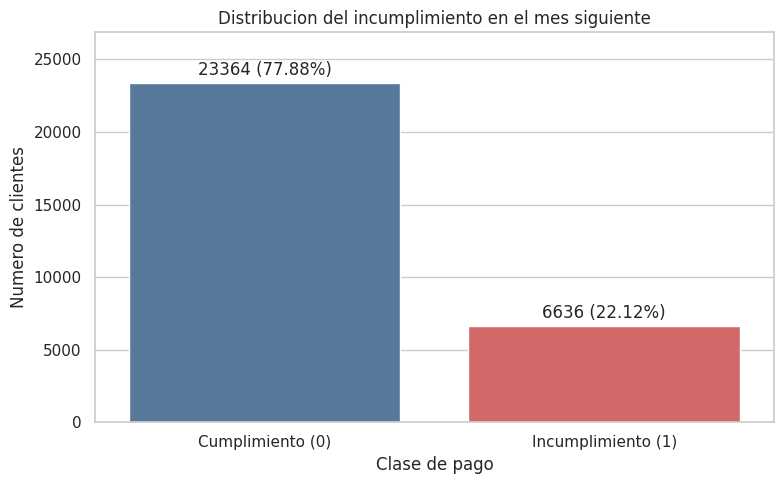

In [ ]:
distribucion_objetivo = (
    datos["default_payment_next_month"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("clase")
    .to_frame("frecuencia")
)
distribucion_objetivo["porcentaje"] = (
    distribucion_objetivo["frecuencia"] / len(datos) * 100
).round(2)
display(distribucion_objetivo)

fig, ax = plt.subplots(figsize=(8, 5))
barras = sns.countplot(data=datos, x="default_payment_next_month", ax=ax, hue="default_payment_next_month", palette=["#4C78A8", "#E45756"], legend=False) # Usar colores distintos y corregir FutureWarning
ax.set_title("Distribucion del incumplimiento en el mes siguiente")
ax.set_xlabel("Clase de pago")
ax.set_ylabel("Numero de clientes")

x_labels = ["Cumplimiento (0)", "Incumplimiento (1)"]
ax.set_xticks(distribucion_objetivo.index)
ax.set_xticklabels(x_labels)

for i, contenedor in enumerate(barras.containers):
    frecuencia = distribucion_objetivo["frecuencia"].iloc[i]
    porcentaje = distribucion_objetivo["porcentaje"].iloc[i]
    barras.bar_label(contenedor, labels=[f'{frecuencia} ({porcentaje:.2f}%)'], padding=3)

ax.set_ylim(0, distribucion_objetivo["frecuencia"].max() * 1.15)

plt.tight_layout()
plt.show()

### 1.7 Resultado de la fase

La ejecución de las celdas permitió verificar las dimensiones, los tipos de datos, los valores nulos, los registros repetidos y la distribución de la variable objetivo. Estos resultados se utilizaron en las fases de limpieza y preprocesamiento.


# 02_Limpieza_y_validacion

## 2.1 Objetivo de la fase

En esta fase se revisaron los valores nulos, los registros repetidos, los rangos, las categorías residuales y la consistencia de la variable objetivo. A partir de estas comprobaciones se aplicaron las transformaciones necesarias antes del análisis exploratorio y del modelado.

Las decisiones se realizaron sobre una copia del conjunto original para conservar la trazabilidad. No se eliminaron observaciones repetidas de manera automática, debido a que UCI no incorporó el identificador del cliente dentro de las características recuperadas y dos clientes diferentes podían presentar los mismos valores.


### 2.2 Revision de datos

Se creó `datos_limpios` como conjunto de trabajo. La tabla de auditoría permite comparar el estado de los datos antes y después de las transformaciones.

In [ ]:
datos_limpios = datos.copy()

auditoria_antes = pd.DataFrame({
    "indicador": [
        "Filas",
        "Columnas",
        "Valores nulos",
        "Filas repetidas",
        "Clases de la variable objetivo"
    ],
    "valor": [
        datos_limpios.shape[0],
        datos_limpios.shape[1],
        int(datos_limpios.isna().sum().sum()),
        int(datos_limpios.duplicated().sum()),
        int(datos_limpios["default_payment_next_month"].nunique())
    ]
})

display(auditoria_antes)

,indicador,valor
0,Filas,30000
1,Columnas,24
2,Valores nulos,0
3,Filas repetidas,35
4,Clases de la variable objetivo,2


### 2.3 Revisión de categorías

Las variables `SEX`, `EDUCATION` y `MARRIAGE` fueron registradas mediante códigos numéricos, pero conceptualmente correspondieron a variables categóricas. En `EDUCATION`, los códigos 0, 5 y 6 se agruparon en la categoría 4 (otros). En `MARRIAGE`, el código 0 se agrupó en la categoría 3 (otros).

Los códigos negativos presentes en `PAY_0`–`PAY_6` no se trataron como valores nulos. Se conservaron porque podían aportar información para la predicción.


In [ ]:
# Carga del conjunto de datos.
dataset_uci = fetch_ucirepo(id=350)

X_original = dataset_uci.data.features.copy()
y_original = dataset_uci.data.targets.copy()

# Renombrado de predictores.
nombres_columnas = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6"
}

X_original = X_original.rename(columns=nombres_columnas)

# Renombrado de la variable objetivo.
y_original.columns = ["default_payment_next_month"]

# Integracion de predictores y objetivo.
datos = pd.concat(
    [
        X_original.reset_index(drop=True),
        y_original.reset_index(drop=True)
    ],
    axis=1
)

print("Seccion 2.3 - Carga y renombrado completados correctamente.")
print(f"Dimensiones de X: {X_original.shape}")
print(f"Dimensiones de y: {y_original.shape}")
print(f"Dimensiones del conjunto: {datos.shape}")

display(datos.head())

Seccion 2.3 - Carga y renombrado completados correctamente.
Dimensiones de X: (30000, 23)
Dimensiones de y: (30000, 1)
Dimensiones del conjunto: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
columnas_esperadas = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "default_payment_next_month"
]

columnas_faltantes = [
    columna for columna in columnas_esperadas
    if columna not in datos.columns
]

print("Seccion 2.3 - Columnas disponibles:")
print(datos.columns.tolist())

if columnas_faltantes:
    print("Columnas faltantes:", columnas_faltantes)
else:
    print("Todas las columnas fueron renombradas correctamente.")

Seccion 2.3 - Columnas disponibles:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_payment_next_month']
Todas las columnas fueron renombradas correctamente.


In [ ]:
datos_limpios = datos.copy()

In [ ]:
variables_categoricas = ["SEX", "EDUCATION", "MARRIAGE"]
variables_estado_pago = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for variable in variables_categoricas + variables_estado_pago:
    frecuencias = (
        datos_limpios[variable]
        .value_counts(dropna=False)
        .sort_index()
        .rename("frecuencia")
        .to_frame()
    )
    frecuencias["porcentaje"] = (
        frecuencias["frecuencia"] / len(datos_limpios) * 100
    ).round(2)
    print()
    print(f"Seccion 2.3 - Variable: {variable}")
    display(frecuencias)


Seccion 2.3 - Variable: SEX


,frecuencia,porcentaje
SEX,,
1,11888,39.63
2,18112,60.37



Seccion 2.3 - Variable: EDUCATION


,frecuencia,porcentaje
EDUCATION,,
0,14,0.05
1,10585,35.28
2,14030,46.77
3,4917,16.39
4,123,0.41
5,280,0.93
6,51,0.17



Seccion 2.3 - Variable: MARRIAGE


...

,frecuencia,porcentaje
PAY_4,,
-2,4348,14.49
-1,5687,18.96
0,16455,54.85
1,2,0.01
2,3159,10.53
3,180,0.60
4,69,0.23
5,35,0.12
6,5,0.02



Seccion 2.3 - Variable: PAY_5


,frecuencia,porcentaje
PAY_5,,
-2,4546,15.15
-1,5539,18.46
0,16947,56.49
2,2626,8.75
3,178,0.59
4,84,0.28
5,17,0.06
6,4,0.01
7,58,0.19



Seccion 2.3 - Variable: PAY_6


,frecuencia,porcentaje
PAY_6,,
-2,4895,16.32
-1,5740,19.13
0,16286,54.29
2,2766,9.22
3,184,0.61
4,49,0.16
5,13,0.04
6,19,0.06
7,46,0.15


### 2.4 Tratamiento de categorías residuales



In [ ]:
# EDUCATION: 1 = posgrado, 2 = universidad, 3 = secundaria y 4 = otros.
datos_limpios["EDUCATION"] = datos_limpios["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: 1 = casado, 2 = soltero y 3 = otros.
datos_limpios["MARRIAGE"] = datos_limpios["MARRIAGE"].replace({0: 3})

print("Seccion 2.4 - Categorias despues de la agrupacion:")
for variable in variables_categoricas:
    print(f"{variable}: {sorted(datos_limpios[variable].dropna().unique().tolist())}")

Seccion 2.4 - Categorias despues de la agrupacion:
SEX: [1, 2]
EDUCATION: [1, 2, 3, 4]
MARRIAGE: [1, 2, 3]


### 2.5 Validación de rangos y consistencia

Se comprobaron condiciones básicas de coherencia. Los saldos de facturación (`BILL_AMT`) podían ser negativos cuando existía un saldo a favor, por lo que no se consideraron errores. En cambio, los límites de crédito, la edad y los pagos previos debían mantenerse en rangos compatibles con la definición de las variables.

In [ ]:
variables_facturacion = [f"BILL_AMT{i}" for i in range(1, 7)]
variables_pago = [f"PAY_AMT{i}" for i in range(1, 7)]

validaciones = {
    "LIMIT_BAL no positivo": int((datos_limpios["LIMIT_BAL"] <= 0).sum()),
    "AGE menor de 18": int((datos_limpios["AGE"] < 18).sum()),
    "AGE mayor de 100": int((datos_limpios["AGE"] > 100).sum()),
    "Pagos previos negativos": int((datos_limpios[variables_pago] < 0).sum().sum()),
    "Objetivo fuera de {0, 1}": int((~datos_limpios["default_payment_next_month"].isin([0, 1])).sum()),
    "SEX fuera de {1, 2}": int((~datos_limpios["SEX"].isin([1, 2])).sum()),
    "EDUCATION fuera de {1, 2, 3, 4}": int((~datos_limpios["EDUCATION"].isin([1, 2, 3, 4])).sum()),
    "MARRIAGE fuera de {1, 2, 3}": int((~datos_limpios["MARRIAGE"].isin([1, 2, 3])).sum()),
}

tabla_validaciones = (
    pd.Series(validaciones, name="registros_detectados")
    .rename_axis("regla")
    .reset_index()
)
display(tabla_validaciones)

if tabla_validaciones["registros_detectados"].sum() == 0:
    print("Seccion 2.5 - No se detectaron incumplimientos en las reglas.")
else:
    print("Se detectaron observaciones.")

,regla,registros_detectados
0,LIMIT_BAL no positivo,0
1,AGE menor de 18,0
2,AGE mayor de 100,0
3,Pagos previos negativos,0
4,"Objetivo fuera de {0, 1}",0
5,"SEX fuera de {1, 2}",0
6,"EDUCATION fuera de {1, 2, 3, 4}",0
7,"MARRIAGE fuera de {1, 2, 3}",0


Seccion 2.5 - No se detectaron incumplimientos en las reglas.


### 2.6 Estadísticos descriptivos posteriores a la limpieza

Se revisaron los estadísticos de las variables numéricas para identificar valores extremos.

In [ ]:
resumen_numerico = datos_limpios.describe().T
resumen_numerico["rango"] = resumen_numerico["max"] - resumen_numerico["min"]
display(resumen_numerico)

cuantiles_financieros = datos_limpios[
    ["LIMIT_BAL"] + variables_facturacion + variables_pago
].quantile([0.00, 0.01, 0.25, 0.50, 0.75, 0.99, 1.00]).T
display(cuantiles_financieros)

,count,mean,std,min,25%,50%,75%,max,rango
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0,990000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0,1.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.00,2.0,2.00,4.0,3.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.00,2.0,2.00,3.0,2.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0,58.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0,10.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0,10.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0,10.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0,10.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0,10.0


,0.00,0.01,0.25,0.50,0.75,0.99,1.00
LIMIT_BAL,10000.0,10000.00,50000.00,140000.0,240000.00,500000.00,1000000.0
BILL_AMT1,-165580.0,-81.00,3558.75,22381.5,67091.00,350110.68,964511.0
BILL_AMT2,-69777.0,-200.00,2984.75,21200.0,64006.25,337495.28,983931.0
BILL_AMT3,-157264.0,-200.00,2666.25,20088.5,60164.75,325030.39,1664089.0
BILL_AMT4,-170000.0,-212.02,2326.75,19052.0,54506.00,304997.27,891586.0
BILL_AMT5,-81334.0,-232.01,1763.00,18104.5,50190.50,285868.33,927171.0
BILL_AMT6,-339603.0,-331.03,1256.00,17071.0,49198.25,279505.06,961664.0
PAY_AMT1,0.0,0.00,1000.00,2100.0,5006.00,66522.18,873552.0
PAY_AMT2,0.0,0.00,833.00,2009.0,5000.00,76651.02,1684259.0
PAY_AMT3,0.0,0.00,390.00,1800.0,4505.00,70000.00,896040.0


### 2.7 Auditoría final y conjunto depurado

In [ ]:
auditoria_despues = pd.DataFrame({
    "indicador": [
        "Filas",
        "Columnas",
        "Valores nulos",
        "Filas repetidas",
        "Categorias EDUCATION",
        "Categorias MARRIAGE"
    ],
    "antes": [
        datos.shape[0],
        datos.shape[1],
        int(datos.isna().sum().sum()),
        int(datos.duplicated().sum()),
        datos["EDUCATION"].nunique(),
        datos["MARRIAGE"].nunique()
    ],
    "despues": [
        datos_limpios.shape[0],
        datos_limpios.shape[1],
        int(datos_limpios.isna().sum().sum()),
        int(datos_limpios.duplicated().sum()),
        datos_limpios["EDUCATION"].nunique(),
        datos_limpios["MARRIAGE"].nunique()
    ]
})
display(auditoria_despues)

assert datos_limpios.shape == datos.shape, "La limpieza modifico las dimensiones."
assert datos_limpios.isna().sum().sum() == 0, "Existen valores nulos."
assert datos_limpios["default_payment_next_month"].isin([0, 1]).all(), "Existen valores invalidos."
assert datos_limpios["EDUCATION"].isin([1, 2, 3, 4]).all(), "EDUCATION contiene codigos invalidos."
assert datos_limpios["MARRIAGE"].isin([1, 2, 3]).all(), "MARRIAGE contiene codigos invalidos."

print("Seccion 2.7 - Conjunto depurado disponible")
print(f"Dimensiones finales: {datos_limpios.shape}")

,indicador,antes,despues
0,Filas,30000,30000
1,Columnas,24,24
2,Valores nulos,0,0
3,Filas repetidas,35,35
4,Categorias EDUCATION,7,4
5,Categorias MARRIAGE,4,3


Seccion 2.7 - Conjunto depurado disponible
Dimensiones finales: (30000, 24)


### 2.8 Resultado de la fase

La fase de limpieza mantuvo las 30.000 observaciones y las 24 columnas del conjunto combinado. No se requirió imputación porque no se detectaron valores nulos. Las categorías residuales de educación y estado civil se agruparon en “otros”, mientras que los estados históricos de pago se conservaron sin alterar para evitar la pérdida de información relevante.

El objeto `datos_limpios` constituye la entrada de la fase de análisis exploratorio. Esta separación permitió conservar los datos originales y documentar de forma reproducible cada transformación aplicada.

# 03_Analisis_exploratorio

## 3.1 Objetivo del análisis exploratorio

En esta fase se describieron las distribuciones, se compararon los clientes cumplidos e incumplidos y se identificaron asociaciones estadísticas y patrones útiles para el modelado. También se evaluaron el desbalance de clases, la asimetría de las variables financieras, la dependencia entre variables mensuales y la utilidad de características derivadas.


## 3.2 Estadística descriptiva

Se calcularon medidas de tendencia central, dispersión, posición y forma. El rango intercuartílico permitió evaluar la concentración central, mientras que el coeficiente de asimetría permitió identificar distribuciones alejadas de la normalidad.

In [ ]:
objetivo = "default_payment_next_month"
variables_numericas_principales = [
    "LIMIT_BAL", "AGE",
    *[f"BILL_AMT{i}" for i in range(1, 7)],
    *[f"PAY_AMT{i}" for i in range(1, 7)]
]

estadistica_descriptiva = datos_limpios[variables_numericas_principales].describe().T
estadistica_descriptiva["mediana"] = datos_limpios[variables_numericas_principales].median()
estadistica_descriptiva["rango_intercuartilico"] = (
    estadistica_descriptiva["75%"] - estadistica_descriptiva["25%"]
)
estadistica_descriptiva["asimetria"] = datos_limpios[variables_numericas_principales].skew()
estadistica_descriptiva = estadistica_descriptiva[[
    "count", "mean", "std", "min", "25%", "mediana", "75%", "max",
    "rango_intercuartilico", "asimetria"
]]
display(estadistica_descriptiva.round(2))

,count,mean,std,min,25%,mediana,75%,max,rango_intercuartilico,asimetria
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0,190000.00,0.99
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0,13.00,0.73
BILL_AMT1,30000.0,51223.33,73635.86,-165580.0,3558.75,22381.5,67091.00,964511.0,63532.25,2.66
BILL_AMT2,30000.0,49179.08,71173.77,-69777.0,2984.75,21200.0,64006.25,983931.0,61021.50,2.71
BILL_AMT3,30000.0,47013.15,69349.39,-157264.0,2666.25,20088.5,60164.75,1664089.0,57498.50,3.09
BILL_AMT4,30000.0,43262.95,64332.86,-170000.0,2326.75,19052.0,54506.00,891586.0,52179.25,2.82
BILL_AMT5,30000.0,40311.40,60797.16,-81334.0,1763.00,18104.5,50190.50,927171.0,48427.50,2.88
BILL_AMT6,30000.0,38871.76,59554.11,-339603.0,1256.00,17071.0,49198.25,961664.0,47942.25,2.85
PAY_AMT1,30000.0,5663.58,16563.28,0.0,1000.00,2100.0,5006.00,873552.0,4006.00,14.67
PAY_AMT2,30000.0,5921.16,23040.87,0.0,833.00,2009.0,5000.00,1684259.0,4167.00,30.45


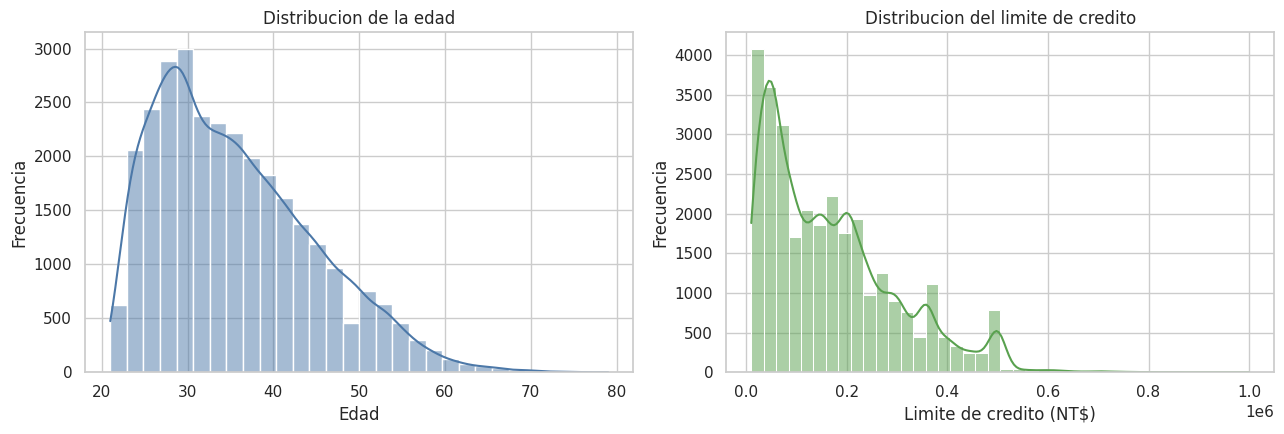

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(datos_limpios["AGE"], bins=30, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribucion de la edad")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")

sns.histplot(datos_limpios["LIMIT_BAL"], bins=40, kde=True, ax=axes[1], color="#59A14F")
axes[1].set_title("Distribucion del limite de credito")
axes[1].set_xlabel("Limite de credito (NT$)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## 3.3 Distribución de la variable objetivo

Se calcularon las frecuencias, los porcentajes, la razón de desbalance y el intervalo de confianza del 95 % para la tasa global de incumplimiento. El desbalance se consideró al seleccionar métricas que complementaran la exactitud (*accuracy*).


In [ ]:
distribucion_clases = (
    datos_limpios[objetivo].value_counts().sort_index()
    .rename_axis("clase").to_frame("frecuencia")
)
distribucion_clases["porcentaje"] = (
    distribucion_clases["frecuencia"] / len(datos_limpios) * 100
).round(2)
distribucion_clases.index = ["Cumplimiento (0)", "Incumplimiento (1)"]

n = len(datos_limpios)
tasa_incumplimiento = datos_limpios[objetivo].mean()
error_estandar = np.sqrt(tasa_incumplimiento * (1 - tasa_incumplimiento) / n)
ic_inferior = tasa_incumplimiento - 1.96 * error_estandar
ic_superior = tasa_incumplimiento + 1.96 * error_estandar
razon_desbalance = (
    distribucion_clases.loc["Cumplimiento (0)", "frecuencia"] /
    distribucion_clases.loc["Incumplimiento (1)", "frecuencia"]
)

display(distribucion_clases)
print(f"Seccion 3.3 - Razon de desbalance: {razon_desbalance:.2f}:1")
print(f"Tasa de incumplimiento: {tasa_incumplimiento * 100:.2f} %")
print(f"IC del 95 %: [{ic_inferior * 100:.2f} %, {ic_superior * 100:.2f} %]")

,frecuencia,porcentaje
Cumplimiento (0),23364,77.88
Incumplimiento (1),6636,22.12


Seccion 3.3 - Razon de desbalance: 3.52:1
Tasa de incumplimiento: 22.12 %
IC del 95 %: [21.65 %, 22.59 %]


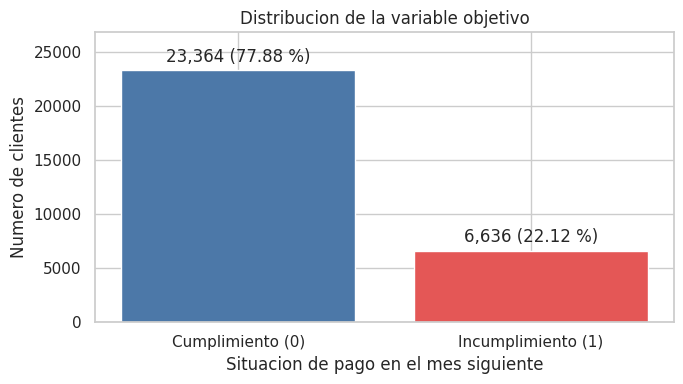

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(
    distribucion_clases.index,
    distribucion_clases["frecuencia"],
    color=["#4C78A8", "#E45756"]
)
ax.bar_label(
    barras,
    labels=[f"{v:,} ({p:.2f} %)" for v, p in zip(
        distribucion_clases["frecuencia"], distribucion_clases["porcentaje"]
    )],
    padding=3
)
ax.set_title("Distribucion de la variable objetivo")
ax.set_xlabel("Situacion de pago en el mes siguiente")
ax.set_ylabel("Numero de clientes")
ax.set_ylim(0, distribucion_clases["frecuencia"].max() * 1.15)
plt.tight_layout()
plt.show()

## 3.4 Análisis univariante

Se analizaron individualmente las variables numéricas mediante histogramas, diagramas de caja y cuantiles. Los valores extremos no se eliminaron, ya que podían corresponder a operaciones financieras legítimas. La escala logarítmica se utilizó como recurso visual en variables no negativas.

,0.01,0.05,0.50,0.95,0.99
LIMIT_BAL,10000.00,20000.0,140000.0,430000.00,500000.00
BILL_AMT1,-81.00,0.0,22381.5,201203.05,350110.68
BILL_AMT2,-200.00,0.0,21200.0,194792.20,337495.28
BILL_AMT3,-200.00,0.0,20088.5,187821.05,325030.39
BILL_AMT4,-212.02,0.0,19052.0,174333.35,304997.27
BILL_AMT5,-232.01,0.0,18104.5,165794.30,285868.33
BILL_AMT6,-331.03,0.0,17071.0,161912.00,279505.06
PAY_AMT1,0.00,0.0,2100.0,18428.20,66522.18
PAY_AMT2,0.00,0.0,2009.0,19004.35,76651.02
PAY_AMT3,0.00,0.0,1800.0,17589.40,70000.00


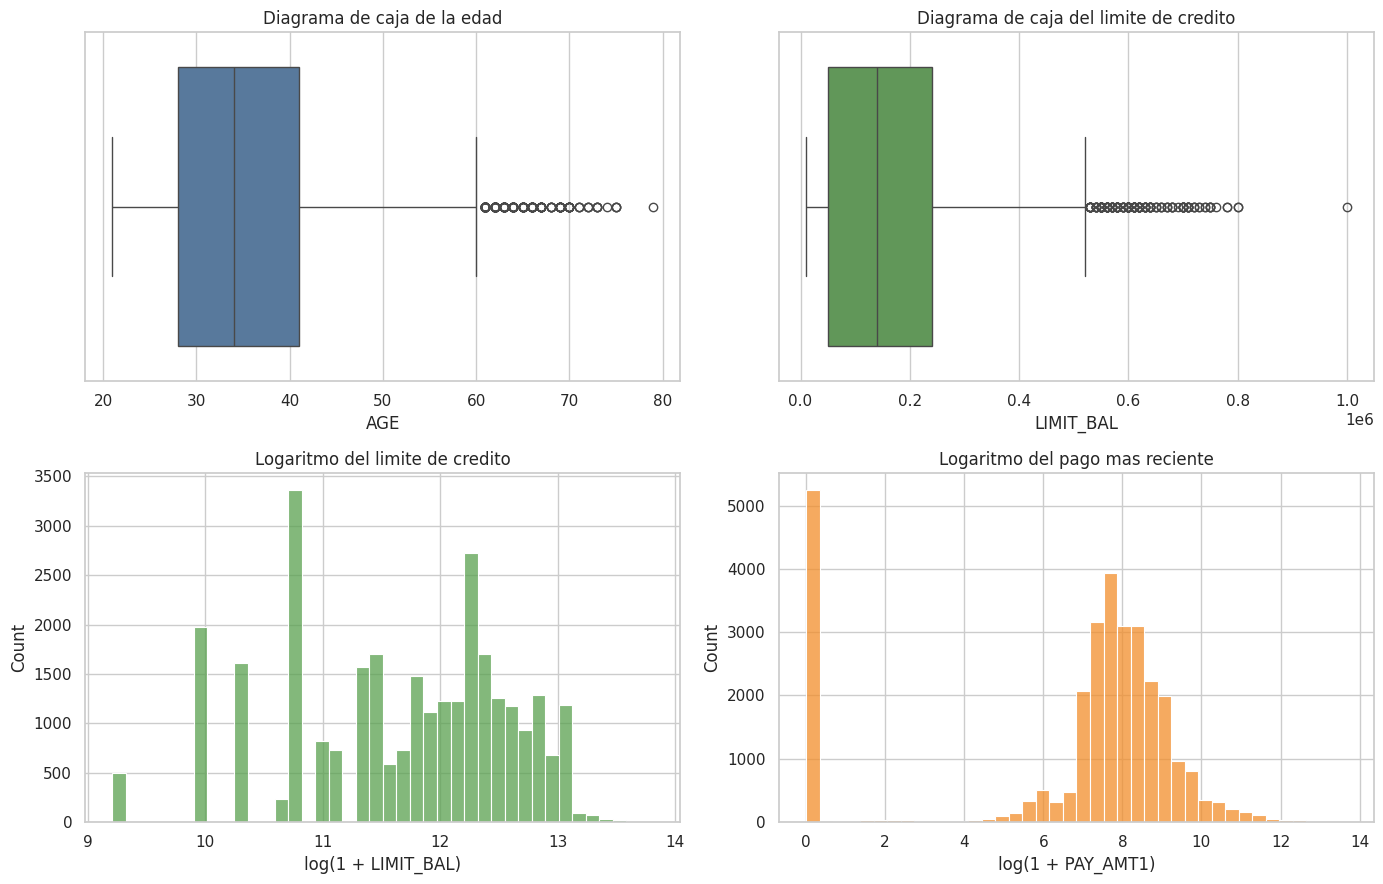

In [ ]:
variables_facturacion = [f"BILL_AMT{i}" for i in range(1, 7)]
variables_pago = [f"PAY_AMT{i}" for i in range(1, 7)]

cuantiles_extremos = datos_limpios[
    ["LIMIT_BAL"] + variables_facturacion + variables_pago
].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).T
display(cuantiles_extremos.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.boxplot(x=datos_limpios["AGE"], ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Diagrama de caja de la edad")

sns.boxplot(x=datos_limpios["LIMIT_BAL"], ax=axes[0, 1], color="#59A14F", showfliers=True)
axes[0, 1].set_title("Diagrama de caja del limite de credito")

sns.histplot(np.log1p(datos_limpios["LIMIT_BAL"]), bins=40, ax=axes[1, 0], color="#59A14F")
axes[1, 0].set_title("Logaritmo del limite de credito")
axes[1, 0].set_xlabel("log(1 + LIMIT_BAL)")

sns.histplot(np.log1p(datos_limpios["PAY_AMT1"]), bins=40, ax=axes[1, 1], color="#F28E2B")
axes[1, 1].set_title("Logaritmo del pago mas reciente")
axes[1, 1].set_xlabel("log(1 + PAY_AMT1)")

plt.tight_layout()
plt.show()

## 3.5 Variables categóricas

Para las variables demográficas y los estados históricos de pago se calcularon el número de clientes, el número de incumplidos y la tasa de incumplimiento dentro de cada categoría.

In [ ]:
variables_categoricas = ["SEX", "EDUCATION", "MARRIAGE"]
variables_estado_pago = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
etiquetas_categorias = {
    "SEX": {1: "Hombre", 2: "Mujer"},
    "EDUCATION": {1: "Posgrado", 2: "Universidad", 3: "Secundaria", 4: "Otros"},
    "MARRIAGE": {1: "Casado", 2: "Soltero", 3: "Otros"}
}

tablas_categoricas = {}
for variable in variables_categoricas:
    tabla = datos_limpios.groupby(variable, observed=True)[objetivo].agg(
        clientes="size", incumplidos="sum", tasa_incumplimiento="mean"
    ).reset_index()
    tabla["categoria"] = tabla[variable].map(etiquetas_categorias[variable])
    tabla["tasa_incumplimiento_pct"] = (tabla["tasa_incumplimiento"] * 100).round(2)
    tablas_categoricas[variable] = tabla
    print()
    print(f"Seccion 3.5 - Variable: {variable}")
    display(tabla[["categoria", "clientes", "incumplidos", "tasa_incumplimiento_pct"]])


Seccion 3.5 - Variable: SEX


,categoria,clientes,incumplidos,tasa_incumplimiento_pct
0,Hombre,11888,2873,24.17
1,Mujer,18112,3763,20.78



Seccion 3.5 - Variable: EDUCATION


,categoria,clientes,incumplidos,tasa_incumplimiento_pct
0,Posgrado,10585,2036,19.23
1,Universidad,14030,3330,23.73
2,Secundaria,4917,1237,25.16
3,Otros,468,33,7.05



Seccion 3.5 - Variable: MARRIAGE


,categoria,clientes,incumplidos,tasa_incumplimiento_pct
0,Casado,13659,3206,23.47
1,Soltero,15964,3341,20.93
2,Otros,377,89,23.61


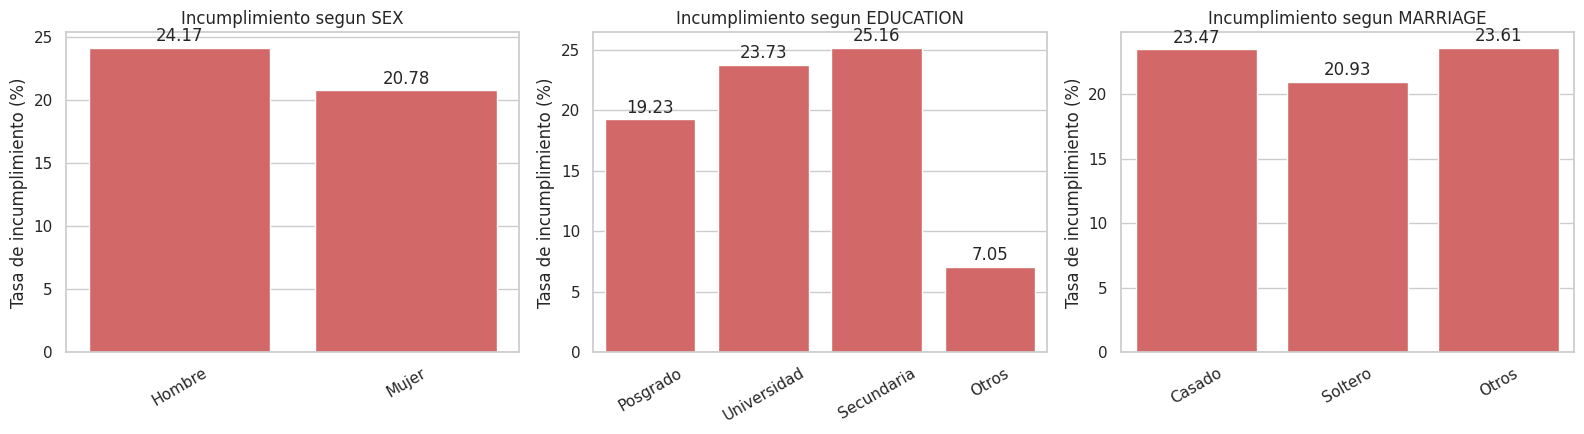

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (variable, tabla) in zip(axes, tablas_categoricas.items()):
    sns.barplot(data=tabla, x="categoria", y="tasa_incumplimiento_pct", ax=ax, color="#E45756")
    ax.set_title(f"Incumplimiento segun {variable}")
    ax.set_xlabel("")
    ax.set_ylabel("Tasa de incumplimiento (%)")
    ax.tick_params(axis="x", rotation=30)
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt="%.2f", padding=2)
plt.tight_layout()
plt.show()

## 3.6 Análisis bivariante

Se compararon las distribuciones de edad, límite de crédito, facturación y pagos entre las clases. Se utilizaron diagramas de caja, histogramas por clase y tablas de estadísticos agrupados.

AGE                       LIMIT_BAL            \
                     mean median   std min max       mean    median   
Cumplimiento (0)    35.42   34.0  9.08  21  79  178099.73  150000.0   
Incumplimiento (1)  35.73   34.0  9.69  21  75  130109.66   90000.0   

                                              BILL_AMT1                     \
                          std    min      max      mean   median       std   
Cumplimiento (0)    131628.36  10000  1000000  51994.23  23119.5  73577.61   
Incumplimiento (1)  115378.54  10000   740000  48509.16  20185.0  73782.07   

                                   PAY_AMT1                                
                       min     max     mean  median       std min     max  
Cumplimiento (0)   -165580  964511  6307.34  2459.5  18014.51   0  873552  
Incumplimiento (1)   -6676  613860  3397.04  1636.0   9544.25   0  300000

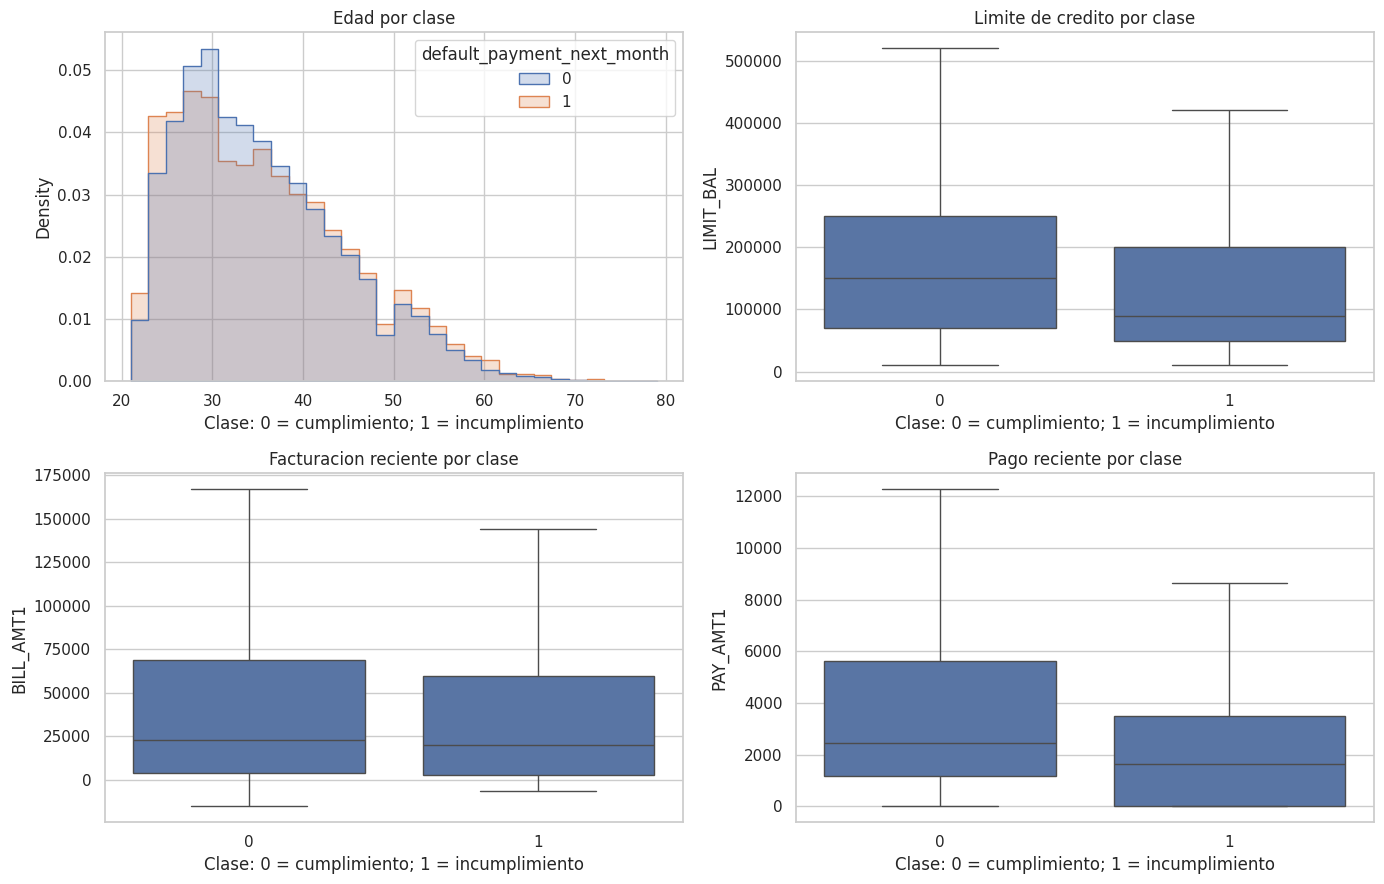

In [ ]:
resumen_por_clase = datos_limpios.groupby(objetivo)[
    ["AGE", "LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]
].agg(["mean", "median", "std", "min", "max"])
resumen_por_clase.index = ["Cumplimiento (0)", "Incumplimiento (1)"]
display(resumen_por_clase.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(data=datos_limpios, x="AGE", hue=objetivo, bins=30,
             stat="density", common_norm=False, element="step", ax=axes[0, 0])
axes[0, 0].set_title("Edad por clase")

sns.boxplot(data=datos_limpios, x=objetivo, y="LIMIT_BAL", showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title("Limite de credito por clase")

sns.boxplot(data=datos_limpios, x=objetivo, y="BILL_AMT1", showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title("Facturacion reciente por clase")

sns.boxplot(data=datos_limpios, x=objetivo, y="PAY_AMT1", showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title("Pago reciente por clase")

for ax in axes.flat:
    ax.set_xlabel("Clase: 0 = cumplimiento; 1 = incumplimiento")
plt.tight_layout()
plt.show()

## 3.7 Estadística inferencial

Se aplicó la prueba chi-cuadrado de independencia a las variables categóricas y la V de Cramér como tamaño del efecto. Para las variables numéricas se utilizó la prueba U de Mann-Whitney, apropiada ante distribuciones asimétricas, junto con la correlación biserial por rangos. Se aplicó una corrección de Bonferroni para controlar las comparaciones múltiples.


In [ ]:
def v_cramer(tabla_contingencia):
    chi2, _, _, _ = chi2_contingency(tabla_contingencia)
    n_obs = tabla_contingencia.to_numpy().sum()
    filas, columnas = tabla_contingencia.shape
    denominador = min(filas - 1, columnas - 1)
    return np.sqrt((chi2 / n_obs) / denominador) if denominador > 0 else 0.0

resultados_chi2 = []
variables_prueba_categorica = variables_categoricas + variables_estado_pago

for variable in variables_prueba_categorica:
    contingencia = pd.crosstab(datos_limpios[variable], datos_limpios[objetivo])
    chi2, p_valor, grados_libertad, _ = chi2_contingency(contingencia)
    resultados_chi2.append({
        "variable": variable,
        "chi_cuadrado": chi2,
        "grados_libertad": grados_libertad,
        "p_valor": p_valor,
        "v_cramer": v_cramer(contingencia)
    })

resultados_chi2 = pd.DataFrame(resultados_chi2)
alfa_bonferroni_cat = 0.05 / len(resultados_chi2)
resultados_chi2["significativa_bonferroni"] = resultados_chi2["p_valor"] < alfa_bonferroni_cat
display(resultados_chi2.sort_values("v_cramer", ascending=False).round(6))
print(f"Seccion 3.7 - Nivel alfa corregido para variables categoricas: {alfa_bonferroni_cat:.6f}")

,variable,chi_cuadrado,grados_libertad,p_valor,v_cramer,significativa_bonferroni
3,PAY_0,5365.964977,10,0.000000,0.422925,True
4,PAY_2,3474.466790,10,0.000000,0.340317,True
5,PAY_3,2622.462128,10,0.000000,0.295661,True
6,PAY_4,2341.469945,10,0.000000,0.279373,True
7,PAY_5,2197.694901,9,0.000000,0.270659,True
8,PAY_6,1886.835309,9,0.000000,0.250788,True
1,EDUCATION,160.409951,3,0.000000,0.073123,True
0,SEX,47.708797,1,0.000000,0.039878,True
2,MARRIAGE,28.130325,2,0.000001,0.030622,True


Seccion 3.7 - Nivel alfa corregido para variables categoricas: 0.005556


In [ ]:
resultados_mann_whitney = []
grupo_cumplimiento = datos_limpios[datos_limpios[objetivo] == 0]
grupo_incumplimiento = datos_limpios[datos_limpios[objetivo] == 1]

for variable in variables_numericas_principales:
    valores_0 = grupo_cumplimiento[variable]
    valores_1 = grupo_incumplimiento[variable]
    u, p_valor = mannwhitneyu(valores_0, valores_1, alternative="two-sided")
    efecto_biserial = 2 * u / (len(valores_0) * len(valores_1)) - 1
    resultados_mann_whitney.append({
        "variable": variable,
        "mediana_cumplimiento": valores_0.median(),
        "mediana_incumplimiento": valores_1.median(),
        "u_mann_whitney": u,
        "p_valor": p_valor,
        "efecto_biserial_rangos": efecto_biserial,
        "efecto_absoluto": abs(efecto_biserial)
    })

resultados_mann_whitney = pd.DataFrame(resultados_mann_whitney)
alfa_bonferroni_num = 0.05 / len(resultados_mann_whitney)
resultados_mann_whitney["significativa_bonferroni"] = (
    resultados_mann_whitney["p_valor"] < alfa_bonferroni_num
)
display(resultados_mann_whitney.sort_values("efecto_absoluto", ascending=False).round(6))
print(f"Seccion 3.7 - Nivel alfa corregido para variables numericas: {alfa_bonferroni_num:.6f}")

,variable,mediana_cumplimiento,mediana_incumplimiento,u_mann_whitney,p_valor,efecto_biserial_rangos,efecto_absoluto,significativa_bonferroni
0,LIMIT_BAL,150000.0,90000.0,95786286.5,0.000000,0.235605,0.235605,True
8,PAY_AMT1,2459.5,1636.0,94780733.0,0.000000,0.222634,0.222634,True
9,PAY_AMT2,2247.5,1533.5,93753756.0,0.000000,0.209386,0.209386,True
10,PAY_AMT3,2000.0,1222.0,92491959.5,0.000000,0.193110,0.193110,True
11,PAY_AMT4,1734.0,1000.0,91253295.5,0.000000,0.177131,0.177131,True
13,PAY_AMT6,1706.0,1000.0,90526299.0,0.000000,0.167754,0.167754,True
12,PAY_AMT5,1765.0,1000.0,90022048.0,0.000000,0.161249,0.161249,True
2,BILL_AMT1,23119.5,20185.0,80252445.5,0.000012,0.035225,0.035225,True
3,BILL_AMT2,21660.5,20300.5,79198493.0,0.007061,0.021629,0.021629,False
4,BILL_AMT3,20202.5,19834.5,78887405.5,0.028203,0.017616,0.017616,False


Seccion 3.7 - Nivel alfa corregido para variables numericas: 0.003571


## 3.8 Correlaciones

Se calcularon correlaciones de Pearson y Spearman. Pearson permitió examinar relaciones lineales, mientras que Spearman fue más robusta frente a asimetrías y permitió identificar relaciones monótonas. Las correlaciones se utilizaron como evidencia exploratoria.

,pearson,spearman,max_asociacion_absoluta
PAY_0,0.3248,0.2922,0.3248
PAY_2,0.2636,0.2169,0.2636
PAY_3,0.2353,0.1948,0.2353
PAY_4,0.2166,0.1737,0.2166
PAY_5,0.2041,0.1590,0.2041
PAY_6,0.1869,0.1425,0.1869
LIMIT_BAL,-0.1535,-0.1696,0.1696
PAY_AMT1,-0.0729,-0.1605,0.1605
PAY_AMT2,-0.0586,-0.1510,0.1510
PAY_AMT3,-0.0563,-0.1394,0.1394


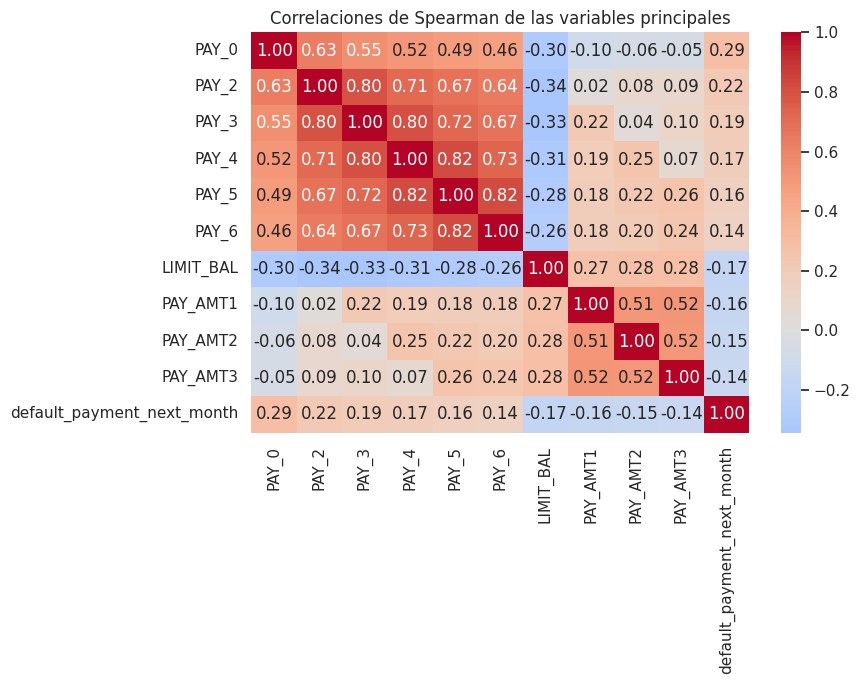

In [ ]:
correlacion_pearson = (
    datos_limpios.corr(method="pearson")[objetivo].drop(objetivo)
    .sort_values(key=abs, ascending=False).rename("pearson")
)
correlacion_spearman = (
    datos_limpios.corr(method="spearman")[objetivo].drop(objetivo)
    .sort_values(key=abs, ascending=False).rename("spearman")
)
comparacion_correlaciones = pd.concat([correlacion_pearson, correlacion_spearman], axis=1)
comparacion_correlaciones["max_asociacion_absoluta"] = comparacion_correlaciones.abs().max(axis=1)
comparacion_correlaciones = comparacion_correlaciones.sort_values(
    "max_asociacion_absoluta", ascending=False
)
display(comparacion_correlaciones.round(4))

principales = comparacion_correlaciones.head(10).index.tolist()
plt.figure(figsize=(9, 7))
sns.heatmap(
    datos_limpios[principales + [objetivo]].corr(method="spearman"),
    cmap="coolwarm", center=0, annot=True, fmt=".2f"
)
plt.title("Correlaciones de Spearman de las variables principales")
plt.tight_layout()
plt.show()

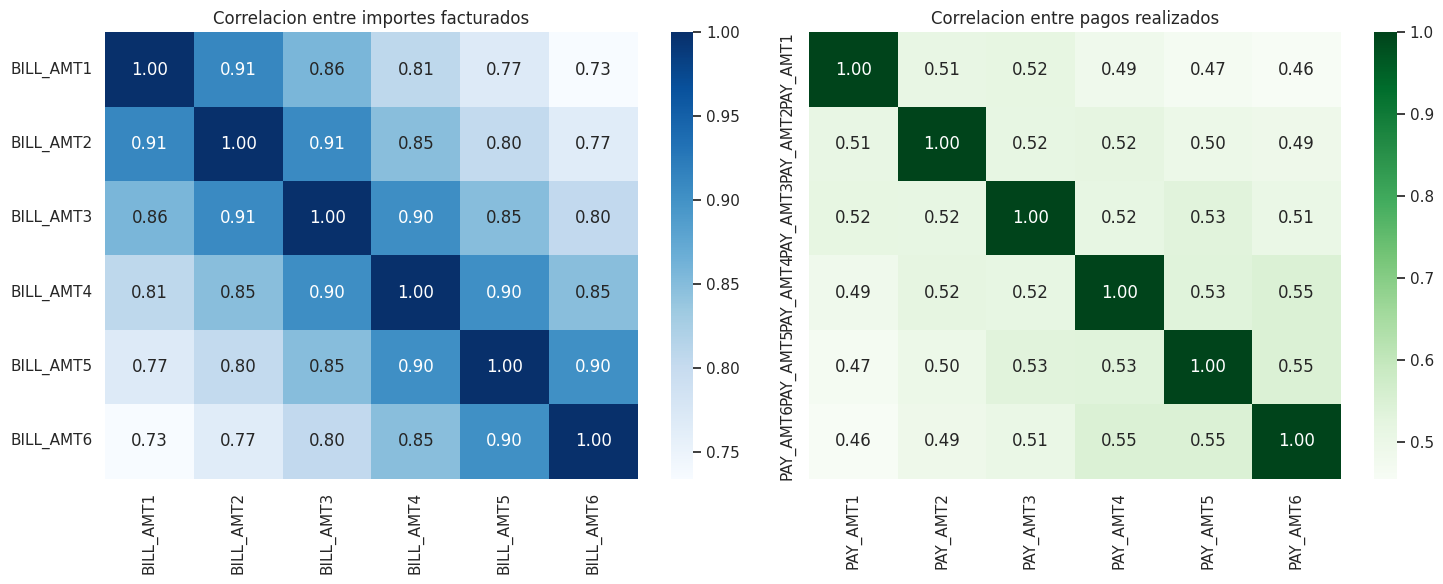

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(datos_limpios[variables_facturacion].corr(method="spearman"),
            cmap="Blues", annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Correlacion entre importes facturados")

sns.heatmap(datos_limpios[variables_pago].corr(method="spearman"),
            cmap="Greens", annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Correlacion entre pagos realizados")
plt.tight_layout()
plt.show()

## 3.9 Comportamiento durante los seis meses

Se examinó la evolución mensual de la facturación, los pagos y los estados de pago. Este análisis no constituyó una serie temporal convencional, porque cada fila correspondía a un cliente; sin embargo, permitió comparar los seis meses de observación entre cumplidos e incumplidos.

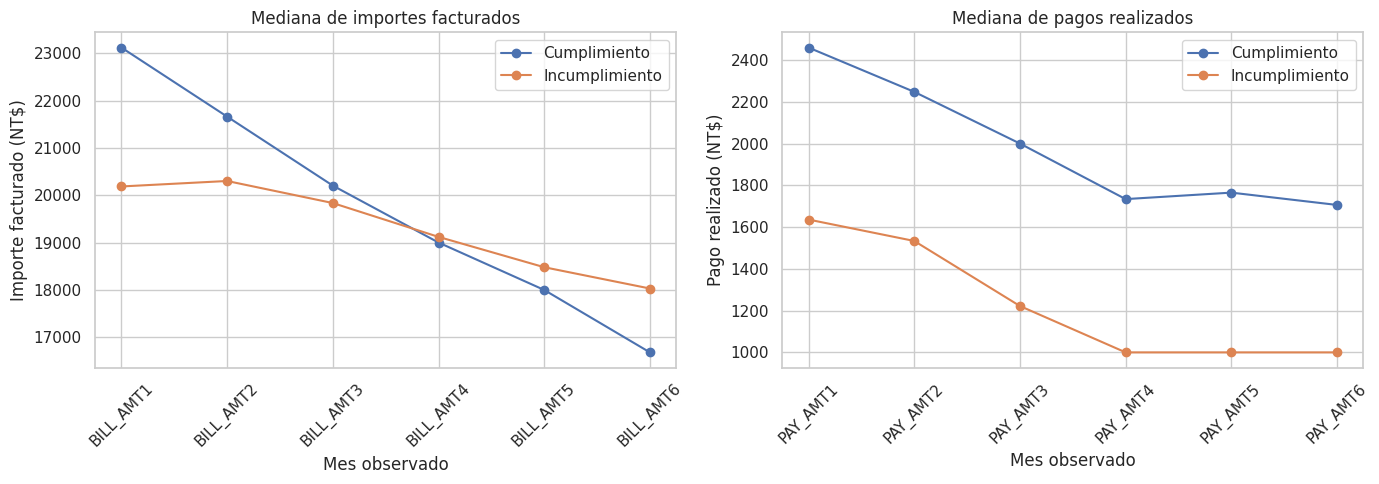

In [ ]:
medianas_facturacion = datos_limpios.groupby(objetivo)[variables_facturacion].median().T
medianas_pago = datos_limpios.groupby(objetivo)[variables_pago].median().T
medianas_facturacion.columns = ["Cumplimiento", "Incumplimiento"]
medianas_pago.columns = ["Cumplimiento", "Incumplimiento"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
medianas_facturacion.plot(marker="o", ax=axes[0])
axes[0].set_title("Mediana de importes facturados")
axes[0].set_xlabel("Mes observado")
axes[0].set_ylabel("Importe facturado (NT$)")

medianas_pago.plot(marker="o", ax=axes[1])
axes[1].set_title("Mediana de pagos realizados")
axes[1].set_xlabel("Mes observado")
axes[1].set_ylabel("Pago realizado (NT$)")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

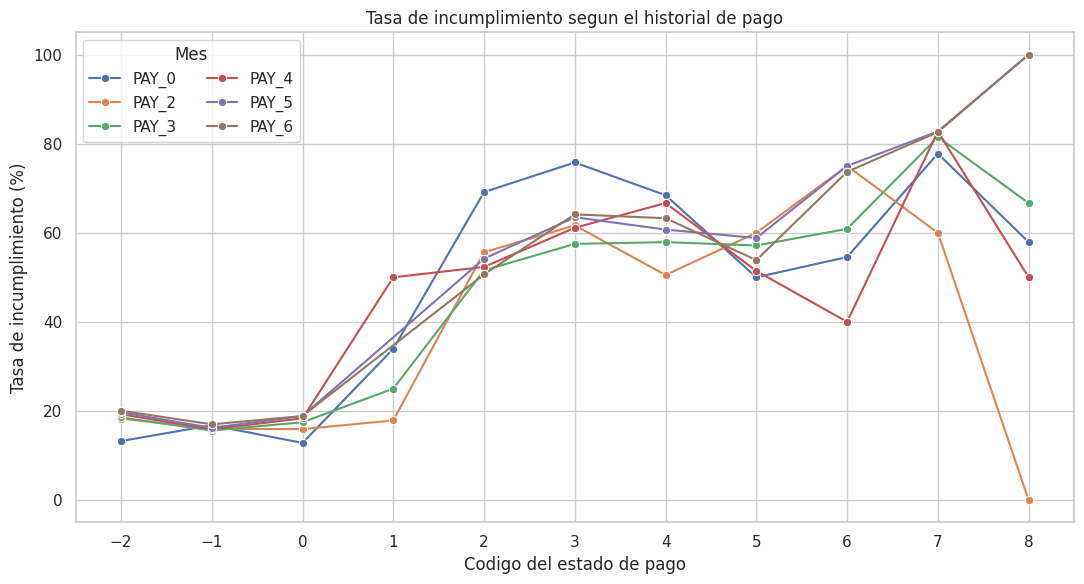

In [ ]:
tasas_estado_pago = []
for variable in variables_estado_pago:
    tabla = datos_limpios.groupby(variable, observed=True)[objetivo].agg(
        clientes="size", tasa_incumplimiento="mean"
    ).reset_index().rename(columns={variable: "estado_pago"})
    tabla["mes"] = variable
    tabla["tasa_incumplimiento_pct"] = tabla["tasa_incumplimiento"] * 100
    tasas_estado_pago.append(tabla)

tasas_estado_pago = pd.concat(tasas_estado_pago, ignore_index=True)
plt.figure(figsize=(11, 6))
sns.lineplot(data=tasas_estado_pago, x="estado_pago",
             y="tasa_incumplimiento_pct", hue="mes", marker="o")
plt.title("Tasa de incumplimiento segun el historial de pago")
plt.xlabel("Codigo del estado de pago")
plt.ylabel("Tasa de incumplimiento (%)")
plt.xticks(sorted(tasas_estado_pago["estado_pago"].unique()))
plt.legend(title="Mes", ncol=2)
plt.tight_layout()
plt.show()

## 3.10 Variables financieras derivadas

Se construyeron características exploratorias con significado financiero: utilización del crédito, facturación y pagos promedio, retraso máximo y número de meses con retraso. Se utilizó una copia denominada `datos_eda` para no modificar el conjunto depurado original.

In [ ]:
datos_eda = datos_limpios.copy()

datos_eda["FACTURACION_PROMEDIO_6M"] = datos_eda[variables_facturacion].mean(axis=1)
datos_eda["PAGO_PROMEDIO_6M"] = datos_eda[variables_pago].mean(axis=1)
datos_eda["UTILIZACION_PROMEDIO_6M"] = (
    datos_eda["FACTURACION_PROMEDIO_6M"] / datos_eda["LIMIT_BAL"]
)
datos_eda["RETRASO_MAXIMO_6M"] = datos_eda[variables_estado_pago].max(axis=1)
datos_eda["MESES_CON_RETRASO"] = (datos_eda[variables_estado_pago] > 0).sum(axis=1)
datos_eda["MESES_SIN_PAGO"] = (datos_eda[variables_pago] == 0).sum(axis=1)

variables_derivadas = [
    "FACTURACION_PROMEDIO_6M", "PAGO_PROMEDIO_6M",
    "UTILIZACION_PROMEDIO_6M", "RETRASO_MAXIMO_6M",
    "MESES_CON_RETRASO", "MESES_SIN_PAGO"
]

resumen_derivadas = datos_eda.groupby(objetivo)[variables_derivadas].agg(["mean", "median"])
resumen_derivadas.index = ["Cumplimiento (0)", "Incumplimiento (1)"]
display(resumen_derivadas.round(3))

asociacion_derivadas = datos_eda[variables_derivadas + [objetivo]].corr(
    method="spearman"
)[objetivo].drop(objetivo).sort_values(key=abs, ascending=False)
display(asociacion_derivadas.rename("correlacion_spearman").to_frame().round(4))

FACTURACION_PROMEDIO_6M            PAGO_PROMEDIO_6M  \
                                      mean     median             mean   
Cumplimiento (0)                 45404.818  21443.417         5828.237   
Incumplimiento (1)               43470.493  19781.333         3328.216   

                             UTILIZACION_PROMEDIO_6M        RETRASO_MAXIMO_6M  \
                      median                    mean median              mean   
Cumplimiento (0)    2754.000                   0.351  0.242             0.201   
Incumplimiento (1)  1612.417                   0.449  0.463             1.274   

                          MESES_CON_RETRASO        MESES_SIN_PAGO         
                   median              mean median           mean median  
Cumplimiento (0)      0.0             0.504    0.0          1.080    0.0  
Incumplimiento (1)    2.0             1.996    1.0          1.757    1.0

,correlacion_spearman
MESES_CON_RETRASO,0.3877
RETRASO_MAXIMO_6M,0.3210
MESES_SIN_PAGO,0.1975
PAGO_PROMEDIO_6M,-0.1741
UTILIZACION_PROMEDIO_6M,0.0919
FACTURACION_PROMEDIO_6M,-0.0268


## 3.11 Análisis de registros repetidos

La limpieza detectó 35 filas repetidas. Debido a la ausencia de un identificador, no se eliminaron, ya que podían corresponder a clientes distintos con perfiles coincidentes. Se evaluó su distribución por clase y su proporción dentro del conjunto.

In [ ]:
mascara_repetidos = datos_limpios.duplicated(keep=False)
registros_en_grupos_repetidos = datos_limpios.loc[mascara_repetidos].copy()

resumen_repetidos = pd.DataFrame({
    "indicador": [
        "Filas marcadas como repetidas",
        "Filas adicionales repetidas",
        "Porcentaje de filas adicionales sobre el total"
    ],
    "valor": [
        int(mascara_repetidos.sum()),
        int(datos_limpios.duplicated().sum()),
        round(datos_limpios.duplicated().mean() * 100, 4)
    ]
})
display(resumen_repetidos)

if not registros_en_grupos_repetidos.empty:
    distribucion_repetidos = (
        registros_en_grupos_repetidos[objetivo].value_counts().sort_index()
        .rename_axis("clase").to_frame("frecuencia")
    )
    distribucion_repetidos["porcentaje"] = (
        distribucion_repetidos["frecuencia"] /
        len(registros_en_grupos_repetidos) * 100
    ).round(2)
    display(distribucion_repetidos)

print("Seccion 3.11 - Los registros se conservaron para el analisis principal.")

,indicador,valor
0,Filas marcadas como repetidas,70.0000
1,Filas adicionales repetidas,35.0000
2,Porcentaje de filas adicionales sobre el total,0.1167


,frecuencia,porcentaje
clase,,
0,58,82.86
1,12,17.14


Seccion 3.11 - Los registros se conservaron para el analisis principal.


## 3.12 Síntesis e implicaciones para el modelado

In [ ]:
variable_spearman_principal = comparacion_correlaciones["spearman"].abs().idxmax()
variable_cramer_principal = resultados_chi2.sort_values("v_cramer", ascending=False).iloc[0]
variable_numerica_principal = resultados_mann_whitney.sort_values(
    "efecto_absoluto", ascending=False
).iloc[0]

print(f"Seccion 3.12 - Tasa global de incumplimiento: {tasa_incumplimiento * 100:.2f} %")
print(f"Razon de desbalance: {razon_desbalance:.2f}:1")
print(
    "Mayor asociacion de Spearman con la salida: "
    f"{variable_spearman_principal} "
    f"({comparacion_correlaciones.loc[variable_spearman_principal, 'spearman']:.3f})"
)
print(
    "Mayor V de Cramer: "
    f"{variable_cramer_principal['variable']} "
    f"({variable_cramer_principal['v_cramer']:.3f})"
)
print(
    "Mayor efecto biserial entre variables numericas: "
    f"{variable_numerica_principal['variable']} "
    f"({variable_numerica_principal['efecto_biserial_rangos']:.3f})"
)
print(f"Filas adicionales repetidas conservadas: {datos_limpios.duplicated().sum()}")

Seccion 3.12 - Tasa global de incumplimiento: 22.12 %
Razon de desbalance: 3.52:1
Mayor asociacion de Spearman con la salida: PAY_0 (0.292)
Mayor V de Cramer: PAY_0 (0.423)
Mayor efecto biserial entre variables numericas: LIMIT_BAL (0.236)
Filas adicionales repetidas conservadas: 35


### Implicaciones metodológicas

- Se utilizaron métricas sensibles a la clase minoritaria, como exhaustividad (*recall*), F1, ROC-AUC y PR-AUC.
- Las variables numéricas se estandarizaron para K-NN debido a sus diferencias de escala.
- La correlación entre variables mensuales se consideró al interpretar las características.
- Las variables derivadas se evaluaron dentro de la validación cruzada.
- Los 35 registros repetidos se conservaron en el análisis principal; su efecto deberá considerarse como limitación y podrá revisarse mediante un análisis de sensibilidad.


# 04_Preprocesamiento

## 4.1 Objetivo del preprocesamiento

El preprocesamiento tuvo como finalidad transformar el conjunto depurado en entradas adecuadas para los tres algoritmos seleccionados: K vecinos más cercanos (K-NN), bosque aleatorio (Random Forest) y potenciación extrema del gradiente (XGBoost).

La estrategia se diseñó para evitar la fuga de información. Primero se construyeron características deterministas a partir de la información disponible en los seis meses de observación; posteriormente, se separaron los conjuntos de entrenamiento y prueba. Las transformaciones que requerían aprendizaje de parámetros, como la estandarización, se definieron dentro de canalizaciones (pipelines) para ajustarse exclusivamente con los datos de entrenamiento.

## 4.2 Características financieras

Los resultados exploratorios mostraron que el número de meses con retraso, el retraso máximo y el pago promedio presentaban asociaciones relevantes con el incumplimiento. Por este motivo se incorporaron seis variables derivadas con interpretación financiera.

Estas variables se calcularon fila por fila sin utilizar la salida ni estadísticas globales, por lo que su generación no introdujo información procedente del conjunto de prueba.

In [ ]:
def agregar_variables_financieras(dataframe):
    resultado = dataframe.copy()
    columnas_facturacion = [f"BILL_AMT{i}" for i in range(1, 7)]
    columnas_pago = [f"PAY_AMT{i}" for i in range(1, 7)]
    columnas_estado = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

    resultado["FACTURACION_PROMEDIO_6M"] = resultado[columnas_facturacion].mean(axis=1)
    resultado["PAGO_PROMEDIO_6M"] = resultado[columnas_pago].mean(axis=1)
    resultado["UTILIZACION_PROMEDIO_6M"] = (
        resultado["FACTURACION_PROMEDIO_6M"] / resultado["LIMIT_BAL"]
    )
    resultado["RETRASO_MAXIMO_6M"] = resultado[columnas_estado].max(axis=1)
    resultado["MESES_CON_RETRASO"] = (resultado[columnas_estado] > 0).sum(axis=1)
    resultado["MESES_SIN_PAGO"] = (resultado[columnas_pago] == 0).sum(axis=1)
    return resultado


datos_modelado = agregar_variables_financieras(datos_limpios)

variables_derivadas = [
    "FACTURACION_PROMEDIO_6M", "PAGO_PROMEDIO_6M",
    "UTILIZACION_PROMEDIO_6M", "RETRASO_MAXIMO_6M",
    "MESES_CON_RETRASO", "MESES_SIN_PAGO"
]

print(f"Seccion 4.2 - Dimensiones antes de la ingenieria: {datos_limpios.shape}")
print(f"Dimensiones despues de la ingenieria: {datos_modelado.shape}")
display(datos_modelado[variables_derivadas].head())

Seccion 4.2 - Dimensiones antes de la ingenieria: (30000, 24)
Dimensiones despues de la ingenieria: (30000, 30)


,FACTURACION_PROMEDIO_6M,PAGO_PROMEDIO_6M,UTILIZACION_PROMEDIO_6M,RETRASO_MAXIMO_6M,MESES_CON_RETRASO,MESES_SIN_PAGO
0,1284.000000,114.833333,0.064200,2,2,5
1,2846.166667,833.333333,0.023718,2,2,2
2,16942.166667,1836.333333,0.188246,0,0,0
3,38555.666667,1398.000000,0.771113,0,0,0
4,18223.166667,9841.500000,0.364463,0,0,0


In [ ]:
assert datos_modelado.shape[0] == datos_limpios.shape[0]
assert datos_modelado.shape[1] == datos_limpios.shape[1] + len(variables_derivadas)
assert datos_modelado[variables_derivadas].isna().sum().sum() == 0
assert np.isfinite(datos_modelado[variables_derivadas].to_numpy()).all()
print("Seccion 4.2 - Las variables derivadas superaron las validaciones de integridad.")

Seccion 4.2 - Las variables derivadas superaron las validaciones de integridad.


## 4.3 Definición de entradas y salida

La matriz de entrada (X) estuvo formada por las 23 características originales y las seis variables financieras derivadas. La salida (y) correspondió a `default_payment_next_month`, donde 1 representó incumplimiento y 0 representó cumplimiento.



In [ ]:
objetivo = "default_payment_next_month"

X = datos_modelado.drop(columns=[objetivo]).copy()
y = datos_modelado[objetivo].astype("int8").copy()

print(f"Seccion 4.3 - Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"Numero de variables originales: {datos_limpios.shape[1] - 1}")
print(f"Numero de variables derivadas: {len(variables_derivadas)}")
print(f"Numero total de predictores: {X.shape[1]}")

assert objetivo not in X.columns, "La salida permanece dentro de la matriz de entrada."
assert y.isin([0, 1]).all(), "La variable objetivo contiene valores distintos de 0 y 1."
assert X.index.equals(y.index), "Los indices de X e Y no estan alineados."


Seccion 4.3 - Dimensiones de X: (30000, 29)
Dimensiones de y: (30000,)
Numero de variables originales: 23
Numero de variables derivadas: 6
Numero total de predictores: 29


## 4.4 Separación estratificada de entrenamiento y prueba

Se reservó el 20 % de los registros como conjunto de prueba y se utilizó el 80 % restante para entrenamiento. La estratificación conservó aproximadamente la misma proporción de incumplimiento en ambos conjuntos. Se fijó la semilla aleatoria en 42 para garantizar reproducibilidad.



In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEMILLA
)

resumen_particiones = pd.DataFrame({
    "particion": ["Entrenamiento", "Prueba", "Total"],
    "observaciones": [len(X_train), len(X_test), len(X)],
    "porcentaje_datos": [len(X_train) / len(X) * 100,
                          len(X_test) / len(X) * 100, 100.0],
    "incumplidos": [int(y_train.sum()), int(y_test.sum()), int(y.sum())],
    "tasa_incumplimiento_pct": [y_train.mean() * 100,
                                 y_test.mean() * 100, y.mean() * 100]
})
display(resumen_particiones.round(2))

,particion,observaciones,porcentaje_datos,incumplidos,tasa_incumplimiento_pct
0,Entrenamiento,24000,80.0,5309,22.12
1,Prueba,6000,20.0,1327,22.12
2,Total,30000,100.0,6636,22.12


In [ ]:
assert len(X_train) == 24000
assert len(X_test) == 6000
assert X_train.index.intersection(X_test.index).empty
assert abs(y_train.mean() - y_test.mean()) < 0.001
assert X_train.columns.equals(X_test.columns)

print("Seccion 4.4 - Separacion validada:")
print("- No existio solapamiento entre entrenamiento y prueba.")
print("- Se conservaron las proporciones de las clases.")
print("- Ambos conjuntos presentaron las mismas columnas.")

Seccion 4.4 - Separacion validada:
- No existio solapamiento entre entrenamiento y prueba.
- Se conservaron las proporciones de las clases.
- Ambos conjuntos presentaron las mismas columnas.


## 4.5 Clasificación de variables

Las variables `SEX`, `EDUCATION` y `MARRIAGE` se trataron como nominales y se codificaron mediante una variable por categoría (*one-hot encoding*). Los estados históricos de pago se conservaron como variables ordinales porque sus valores representaron niveles crecientes de retraso.

Las variables financieras, demográficas y derivadas restantes se trataron como numéricas.


In [ ]:
variables_nominales = ["SEX", "EDUCATION", "MARRIAGE"]
variables_ordinales = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
variables_numericas = [
    columna for columna in X_train.columns
    if columna not in variables_nominales
]

resumen_tipos = pd.DataFrame({
    "grupo": ["Nominales", "Ordinales incluidas como numericas", "Numericas totales"],
    "cantidad": [len(variables_nominales), len(variables_ordinales), len(variables_numericas)],
    "variables": [
        ", ".join(variables_nominales),
        ", ".join(variables_ordinales),
        ", ".join(variables_numericas)
    ]
})
display(resumen_tipos)

assert set(variables_nominales).isdisjoint(variables_numericas)
assert set(variables_nominales + variables_numericas) == set(X_train.columns)

,grupo,cantidad,variables
0,Nominales,3,"SEX, EDUCATION, MARRIAGE"
1,Ordinales incluidas como numericas,6,"PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6"
2,Numericas totales,26,"LIMIT_BAL, AGE, PAY_0, PAY_2, PAY_3, PAY_4, PA..."


## 4.6 Transformación para K-NN

K-NN calculó distancias entre observaciones y fue sensible a la escala. Por esta razón, las variables numéricas se estandarizaron mediante `StandardScaler` y las nominales se codificaron mediante una variable por categoría (*one-hot encoding*) con `OneHotEncoder`.

Las transformaciones se incorporaron en una canalización (*pipeline*) para que sus parámetros se aprendieran únicamente con los datos de entrenamiento de cada partición y no se produjera fuga de información.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocesador_knn = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), variables_numericas),
        ("nominales", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         variables_nominales)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Seccion 4.6 - Preprocesador de K-NN definido correctamente.")
print("No se ha ajustado con datos en esta etapa.")

Seccion 4.6 - Preprocesador de K-NN definido correctamente.
No se ha ajustado con datos en esta etapa.


## 4.7 Transformación para Random Forest y XGBoost

Random Forest y XGBoost no requirieron estandarización, debido a que sus divisiones se basaron en umbrales. Las variables numéricas se conservaron en su escala original y las nominales se codificaron mediante `OneHotEncoder`.

Se definió un preprocesador independiente para evitar transformaciones innecesarias en los modelos basados en árboles.


In [ ]:
preprocesador_arboles = ColumnTransformer(
    transformers=[
        ("numericas", "passthrough", variables_numericas),
        ("nominales", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         variables_nominales)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Seccion 4.7 - Preprocesador para modelos basados en arboles definido correctamente.")

Seccion 4.7 - Preprocesador para modelos basados en arboles definido correctamente.


## 4.8 Validación de las transformaciones

Se ajustaron copias de los preprocesadores únicamente con el conjunto de entrenamiento para comprobar sus dimensiones y la ausencia de valores no finitos. Estas copias se utilizaron solo para validación; cada modelo conservó su propia canalización.


In [ ]:
from sklearn.base import clone

preprocesador_knn_revision = clone(preprocesador_knn)
preprocesador_arboles_revision = clone(preprocesador_arboles)

X_train_knn_revision = preprocesador_knn_revision.fit_transform(X_train)
X_test_knn_revision = preprocesador_knn_revision.transform(X_test)
X_train_arboles_revision = preprocesador_arboles_revision.fit_transform(X_train)
X_test_arboles_revision = preprocesador_arboles_revision.transform(X_test)

revision_transformaciones = pd.DataFrame({
    "transformacion": ["K-NN entrenamiento", "K-NN prueba",
                       "Arboles entrenamiento", "Arboles prueba"],
    "filas": [X_train_knn_revision.shape[0], X_test_knn_revision.shape[0],
              X_train_arboles_revision.shape[0], X_test_arboles_revision.shape[0]],
    "columnas": [X_train_knn_revision.shape[1], X_test_knn_revision.shape[1],
                 X_train_arboles_revision.shape[1], X_test_arboles_revision.shape[1]],
    "valores_no_finitos": [
        int((~np.isfinite(X_train_knn_revision)).sum()),
        int((~np.isfinite(X_test_knn_revision)).sum()),
        int((~np.isfinite(X_train_arboles_revision)).sum()),
        int((~np.isfinite(X_test_arboles_revision)).sum())
    ]
})
display(revision_transformaciones)

assert revision_transformaciones["valores_no_finitos"].sum() == 0
assert X_train_knn_revision.shape[1] == X_test_knn_revision.shape[1]
assert X_train_arboles_revision.shape[1] == X_test_arboles_revision.shape[1]
print("Seccion 4.8 - Las transformaciones fueron validadas correctamente.")

,transformacion,filas,columnas,valores_no_finitos
0,K-NN entrenamiento,24000,35,0
1,K-NN prueba,6000,35,0
2,Arboles entrenamiento,24000,35,0
3,Arboles prueba,6000,35,0


Seccion 4.8 - Las transformaciones fueron validadas correctamente.


## 4.9 Estrategia de validación cruzada y métricas

La selección de hiperparámetros se realizó sobre el conjunto de entrenamiento mediante validación cruzada estratificada de cinco particiones (*5-fold stratified cross-validation*). La estratificación conservó la proporción de las clases y la semilla aleatoria permitió reproducir las particiones.

La métrica principal fue el área bajo la curva ROC (ROC-AUC). También se calcularon el área bajo la curva precisión-exhaustividad (PR-AUC), precisión (*precision*), exhaustividad (*recall*), F1, exactitud y exactitud balanceada.


In [ ]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

validacion_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEMILLA
)

metricas_validacion = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "accuracy": "accuracy"
}

distribucion_folds = []
for numero_fold, (indices_train, indices_val) in enumerate(
    validacion_cruzada.split(X_train, y_train), start=1
):
    distribucion_folds.append({
        "fold": numero_fold,
        "entrenamiento_n": len(indices_train),
        "validacion_n": len(indices_val),
        "tasa_train_pct": y_train.iloc[indices_train].mean() * 100,
        "tasa_validacion_pct": y_train.iloc[indices_val].mean() * 100
    })

display(pd.DataFrame(distribucion_folds).round(2))

,fold,entrenamiento_n,validacion_n,tasa_train_pct,tasa_validacion_pct
0,1,19200,4800,22.12,22.10
1,2,19200,4800,22.12,22.12
2,3,19200,4800,22.12,22.12
3,4,19200,4800,22.12,22.12
4,5,19200,4800,22.12,22.12


## 4.10 Tratamiento del desbalance

La clase de incumplimiento representó el 22,12 % de las observaciones, con una razón aproximada de 3,52 clientes cumplidos por cada cliente incumplido. Este resultado indicó un desbalance moderado.

No se aplicó sobremuestreo sintético (SMOTE). En K-NN se ajustó el umbral con predicciones fuera de muestra del entrenamiento. En Random Forest se compararon configuraciones sin ponderación y con `class_weight`; en XGBoost se comparó `scale_pos_weight=1` con la razón calculada únicamente a partir de `y_train`. La decisión se basó en validación cruzada y consideró el equilibrio entre detección de incumplidos y falsos positivos.


In [ ]:
conteo_clases_train = y_train.value_counts().sort_index()
scale_pos_weight_inicial = conteo_clases_train.loc[0] / conteo_clases_train.loc[1]

tabla_desbalance_train = pd.DataFrame({
    "clase": ["Cumplimiento (0)", "Incumplimiento (1)"],
    "frecuencia": [conteo_clases_train.loc[0], conteo_clases_train.loc[1]],
    "porcentaje": [conteo_clases_train.loc[0] / len(y_train) * 100,
                   conteo_clases_train.loc[1] / len(y_train) * 100]
})
display(tabla_desbalance_train.round(2))
print(f"Seccion 4.10 - scale_pos_weight inicial para XGBoost: {scale_pos_weight_inicial:.3f}")

,clase,frecuencia,porcentaje
0,Cumplimiento (0),18691,77.88
1,Incumplimiento (1),5309,22.12


Seccion 4.10 - scale_pos_weight inicial para XGBoost: 3.521


## 4.11 Resultado del preprocesamiento

Al finalizar esta fase se conservaron los conjuntos de entrenamiento y prueba, los preprocesadores específicos para K-NN y los modelos basados en árboles, las cinco particiones estratificadas, las métricas de evaluación y el valor de referencia de `scale_pos_weight`.

Estos objetos permitieron entrenar los tres algoritmos bajo condiciones comparables y mantener el conjunto de prueba fuera del ajuste de hiperparámetros y umbrales.


# 05_Modelo_KNN

## 5.1 Objetivo y estrategia experimental

En esta fase se entrenó el modelo de K vecinos más cercanos (K-NN). Debido a que el algoritmo se basó en distancias, las variables numéricas se estandarizaron y las nominales se codificaron dentro de la canalización.

El modelo se comparó con un clasificador de referencia y se optimizó mediante validación cruzada estratificada de cinco particiones. Los hiperparámetros y el umbral se seleccionaron únicamente con el conjunto de entrenamiento; después se realizó una sola evaluación sobre el conjunto de prueba.


## 5.2 Importaciones y funciones auxiliares

Las funciones siguientes resumieron las métricas de validación cruzada y calcularon las métricas finales de clasificación. La clase positiva correspondió al incumplimiento (`1`).


In [ ]:
import time

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate, cross_val_predict, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)


def resumir_validacion_cruzada(nombre_modelo, resultados_cv):
    resumen = {"modelo": nombre_modelo}
    for metrica in metricas_validacion:
        valores = resultados_cv[f"test_{metrica}"]
        resumen[f"{metrica}_media"] = valores.mean()
        resumen[f"{metrica}_desv"] = valores.std(ddof=1)
    resumen["tiempo_ajuste_s"] = resultados_cv["fit_time"].mean()
    resumen["tiempo_evaluacion_s"] = resultados_cv["score_time"].mean()
    return resumen


def calcular_metricas_clasificacion(y_real, probabilidades, predicciones):
    return {
        "ROC-AUC": roc_auc_score(y_real, probabilidades),
        "PR-AUC": average_precision_score(y_real, probabilidades),
        "Exactitud": accuracy_score(y_real, predicciones),
        "Exactitud balanceada": balanced_accuracy_score(y_real, predicciones),
        "Precision": precision_score(y_real, predicciones, zero_division=0),
        "Exhaustividad": recall_score(y_real, predicciones, zero_division=0),
        "F1": f1_score(y_real, predicciones, zero_division=0),
    }


print("Seccion 5.2 - Funciones de evaluacion definidas correctamente.")


Seccion 5.2 - Funciones de evaluacion definidas correctamente.


## 5.3 Clasificador de referencia

Se utilizó un clasificador ingenuo (`DummyClassifier`) con estrategia basada en las proporciones observadas en entrenamiento. Este modelo no aprendió relaciones entre las características y la salida; por ello, sirvió como nivel mínimo de referencia para verificar si K-NN aportó capacidad discriminativa real.


In [ ]:
modelo_referencia = DummyClassifier(strategy="prior", random_state=SEMILLA)

cv_referencia = cross_validate(
    modelo_referencia,
    X_train,
    y_train,
    cv=validacion_cruzada,
    scoring=metricas_validacion,
    n_jobs=-1,
    return_train_score=False,
)

resumen_referencia = resumir_validacion_cruzada(
    "Clasificador de referencia", cv_referencia
)

display(pd.DataFrame([resumen_referencia]).round(4))


,modelo,roc_auc_media,roc_auc_desv,pr_auc_media,pr_auc_desv,precision_media,precision_desv,recall_media,recall_desv,f1_media,f1_desv,accuracy_media,accuracy_desv,tiempo_ajuste_s,tiempo_evaluacion_s
0,Clasificador de referencia,0.5,0.0,0.2212,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.7788,0.0001,0.0182,0.0572


## 5.4 K-NN con configuración inicial

Como primera aproximación se evaluó un K-NN con cinco vecinos, distancia euclidiana y ponderación uniforme. El preprocesamiento permaneció dentro de la canalización para que sus parámetros se ajustaran de nuevo en cada partición de entrenamiento y se evitara fuga de información.


In [ ]:
pipeline_knn_inicial = Pipeline(
    steps=[
        ("preprocesamiento", clone(preprocesador_knn)),
        (
            "modelo",
            KNeighborsClassifier(
                n_neighbors=5,
                weights="uniform",
                p=2,
                algorithm="brute",
                n_jobs=1,
            ),
        ),
    ]
)

cv_knn_inicial = cross_validate(
    pipeline_knn_inicial,
    X_train,
    y_train,
    cv=validacion_cruzada,
    scoring=metricas_validacion,
    n_jobs=-1,
    return_train_score=False,
)

resumen_knn_inicial = resumir_validacion_cruzada(
    "K-NN inicial", cv_knn_inicial
)

comparacion_inicial = pd.DataFrame(
    [resumen_referencia, resumen_knn_inicial]
).set_index("modelo")

display(comparacion_inicial.round(4))


,roc_auc_media,roc_auc_desv,pr_auc_media,pr_auc_desv,precision_media,precision_desv,recall_media,recall_desv,f1_media,f1_desv,accuracy_media,accuracy_desv,tiempo_ajuste_s,tiempo_evaluacion_s
modelo,,,,,,,,,,,,,,
Clasificador de referencia,0.5000,0.0000,0.2212,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7788,0.0001,0.0182,0.0572
K-NN inicial,0.7087,0.0054,0.4189,0.0043,0.5565,0.0087,0.3588,0.0121,0.4363,0.0107,0.7949,0.0026,0.0689,2.5686


## 5.5 Optimización de hiperparámetros

Se evaluaron 13 configuraciones formadas por valores impares del número de vecinos (`k`), ponderación uniforme o por distancia y las distancias Manhattan (`p=1`) y euclidiana (`p=2`). La selección se realizó mediante la media de ROC-AUC en las cinco particiones.

PR-AUC, precisión, exhaustividad y F1 se conservaron como métricas complementarias. La búsqueda fue la operación de mayor coste computacional de esta sección.


In [ ]:
pipeline_knn = Pipeline(
    steps=[
        ("preprocesamiento", clone(preprocesador_knn)),
        (
            "modelo",
            KNeighborsClassifier(
                algorithm="brute",
                n_jobs=1,
            ),
        ),
    ]
)

espacio_parametros_knn = [
    {
        "modelo__n_neighbors": [5, 11, 21, 31, 51],
        "modelo__weights": ["uniform"],
        "modelo__p": [2],
    },
    {
        "modelo__n_neighbors": [5, 11, 21, 31, 51],
        "modelo__weights": ["distance"],
        "modelo__p": [2],
    },
    {
        "modelo__n_neighbors": [11, 21, 31],
        "modelo__weights": ["distance"],
        "modelo__p": [1],
    },
]

busqueda_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=espacio_parametros_knn,
    scoring=metricas_validacion,
    refit="roc_auc",
    cv=validacion_cruzada,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    error_score="raise",
)

inicio_busqueda_knn = time.perf_counter()
busqueda_knn.fit(X_train, y_train)
tiempo_busqueda_knn = time.perf_counter() - inicio_busqueda_knn

mejor_modelo_knn = busqueda_knn.best_estimator_

print(f"Seccion 5.5 - Combinaciones evaluadas: {len(busqueda_knn.cv_results_['params'])}")
print(f"Ajustes totales: {len(busqueda_knn.cv_results_['params']) * validacion_cruzada.n_splits}")
print(f"Tiempo total de busqueda: {tiempo_busqueda_knn:.2f} segundos")
print(f"Mejor ROC-AUC de validacion: {busqueda_knn.best_score_:.4f}")
print("Mejores hiperparametros:")
display(pd.Series(busqueda_knn.best_params_, name="valor").to_frame())


Fitting 5 folds for each of 13 candidates, totalling 65 fits
Seccion 5.5 - Combinaciones evaluadas: 13
Ajustes totales: 65
Tiempo total de busqueda: 107.53 segundos
Mejor ROC-AUC de validacion: 0.7653
Mejores hiperparametros:


,valor
modelo__n_neighbors,51
modelo__p,2
modelo__weights,uniform


## 5.6 Resultados de la validación cruzada

Se ordenaron las configuraciones por ROC-AUC y se analizaron conjuntamente PR-AUC, precisión, exhaustividad y F1. El gráfico permitió observar el efecto del número de vecinos, la ponderación y la métrica de distancia sobre la capacidad discriminativa.


In [ ]:
resultados_busqueda_knn = pd.DataFrame(busqueda_knn.cv_results_)

columnas_resultados_knn = [
    "rank_test_roc_auc",
    "param_modelo__n_neighbors",
    "param_modelo__weights",
    "param_modelo__p",
    "mean_test_roc_auc",
    "std_test_roc_auc",
    "mean_test_pr_auc",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_accuracy",
    "mean_fit_time",
    "mean_score_time",
]

tabla_resultados_knn = (
    resultados_busqueda_knn[columnas_resultados_knn]
    .sort_values("rank_test_roc_auc")
    .reset_index(drop=True)
)

tabla_resultados_knn = tabla_resultados_knn.rename(columns={
    "rank_test_roc_auc": "ranking",
    "param_modelo__n_neighbors": "n_vecinos",
    "param_modelo__weights": "ponderacion",
    "param_modelo__p": "p_distancia",
    "mean_test_roc_auc": "roc_auc_media",
    "std_test_roc_auc": "roc_auc_desv",
    "mean_test_pr_auc": "pr_auc_media",
    "mean_test_precision": "precision_media",
    "mean_test_recall": "recall_media",
    "mean_test_f1": "f1_media",
    "mean_test_accuracy": "accuracy_media",
    "mean_fit_time": "ajuste_s",
    "mean_score_time": "evaluacion_s",
})

display(tabla_resultados_knn.head(10).round(4))


,ranking,n_vecinos,ponderacion,p_distancia,roc_auc_media,roc_auc_desv,pr_auc_media,precision_media,recall_media,f1_media,accuracy_media,ajuste_s,evaluacion_s
0,1,51,uniform,2,0.7653,0.0086,0.5199,0.6515,0.3468,0.4526,0.8144,0.0268,1.6135
1,2,51,distance,2,0.7638,0.0079,0.5211,0.6486,0.3496,0.4543,0.8142,0.0290,1.9370
2,3,31,distance,1,0.7632,0.0056,0.5195,0.6440,0.3564,0.4588,0.8140,0.0290,7.9133
3,4,31,uniform,2,0.7615,0.0082,0.5102,0.6480,0.3479,0.4527,0.8139,0.0291,1.8562
4,5,31,distance,2,0.7597,0.0075,0.5150,0.6452,0.3507,0.4544,0.8137,0.0268,1.5443
5,6,21,distance,1,0.7568,0.0068,0.5099,0.6308,0.3577,0.4565,0.8115,0.0280,8.1467
6,7,21,uniform,2,0.7539,0.0073,0.4987,0.6361,0.3519,0.4531,0.8121,0.0256,1.5034
7,8,21,distance,2,0.7525,0.0065,0.5080,0.6288,0.3562,0.4547,0.8110,0.0266,1.5032
8,9,11,distance,1,0.7439,0.0054,0.4913,0.5934,0.3596,0.4477,0.8038,0.0283,8.1195
9,10,11,uniform,2,0.7407,0.0047,0.4697,0.6093,0.3505,0.4450,0.8066,0.0322,1.4847


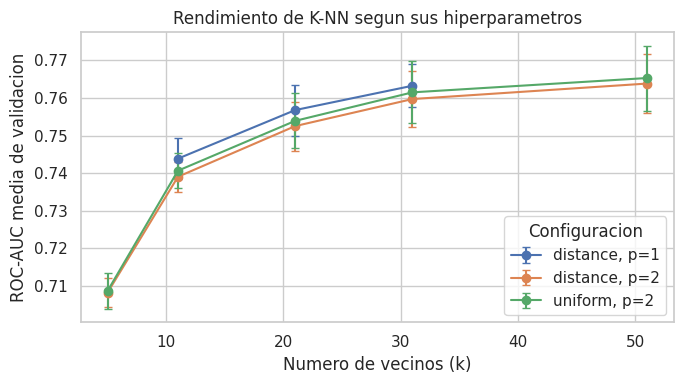

In [ ]:
plt.figure(figsize=(7, 4))

for (ponderacion, p_distancia), grupo in tabla_resultados_knn.groupby(
    ["ponderacion", "p_distancia"]
):
    grupo = grupo.sort_values("n_vecinos")
    etiqueta = f"{ponderacion}, p={int(p_distancia)}"
    plt.errorbar(
        grupo["n_vecinos"].astype(int),
        grupo["roc_auc_media"],
        yerr=grupo["roc_auc_desv"],
        marker="o",
        capsize=3,
        label=etiqueta,
    )

plt.xlabel("Numero de vecinos (k)")
plt.ylabel("ROC-AUC media de validacion")
plt.title("Rendimiento de K-NN segun sus hiperparametros")
plt.legend(title="Configuracion")
plt.tight_layout()
plt.show()


## 5.7 Selección del umbral con predicciones fuera de muestra

K-NN no dispuso de un parámetro equivalente a `class_weight` y no se aplicó SMOTE. En su lugar, se generaron probabilidades fuera de muestra (*out-of-fold*, OOF) sobre el conjunto de entrenamiento y se eligió el umbral que maximizó F1.

El conjunto de prueba no intervino en esta decisión. ROC-AUC y PR-AUC no cambiaron con el umbral porque se calcularon a partir de probabilidades.


In [ ]:
inicio_oof_knn = time.perf_counter()

probabilidades_oof_knn = cross_val_predict(
    mejor_modelo_knn,
    X_train,
    y_train,
    cv=validacion_cruzada,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

tiempo_oof_knn = time.perf_counter() - inicio_oof_knn

precision_oof, recall_oof, umbrales_oof = precision_recall_curve(
    y_train, probabilidades_oof_knn
)

f1_oof = (
    2 * precision_oof[:-1] * recall_oof[:-1]
    / (precision_oof[:-1] + recall_oof[:-1] + 1e-12)
)

indice_mejor_f1 = int(np.nanargmax(f1_oof))
umbral_f1_knn = float(umbrales_oof[indice_mejor_f1])

tabla_umbral_oof = pd.DataFrame({
    "umbral": [umbral_f1_knn],
    "precision_oof": [precision_oof[indice_mejor_f1]],
    "recall_oof": [recall_oof[indice_mejor_f1]],
    "f1_oof": [f1_oof[indice_mejor_f1]],
    "roc_auc_oof": [roc_auc_score(y_train, probabilidades_oof_knn)],
    "pr_auc_oof": [average_precision_score(y_train, probabilidades_oof_knn)],
})

display(tabla_umbral_oof.round(4))
print(f"Seccion 5.7 - Tiempo para predicciones fuera de muestra: {tiempo_oof_knn:.2f} segundos")


,umbral,precision_oof,recall_oof,f1_oof,roc_auc_oof,pr_auc_oof
0,0.2941,0.5207,0.5474,0.5337,0.7652,0.5192


Seccion 5.7 - Tiempo para predicciones fuera de muestra: 2.33 segundos


## 5.8 Evaluación final en el conjunto de prueba

Una vez finalizada la selección, se utilizó el mejor estimador ajustado por `GridSearchCV` para obtener probabilidades sobre las 6.000 observaciones reservadas. Se compararon el umbral convencional de 0,50 y el umbral seleccionado en entrenamiento.

La evaluación del conjunto de prueba se realizó después de cerrar la configuración del modelo. Por tanto, sus resultados no deberán utilizarse para volver a modificar hiperparámetros.


In [ ]:
inicio_prediccion_knn = time.perf_counter()
probabilidades_test_knn = mejor_modelo_knn.predict_proba(X_test)[:, 1]
tiempo_prediccion_knn = time.perf_counter() - inicio_prediccion_knn

predicciones_test_knn_05 = (probabilidades_test_knn >= 0.50).astype(int)
predicciones_test_knn_f1 = (
    probabilidades_test_knn >= umbral_f1_knn
).astype(int)

metricas_knn_05 = calcular_metricas_clasificacion(
    y_test, probabilidades_test_knn, predicciones_test_knn_05
)
metricas_knn_f1 = calcular_metricas_clasificacion(
    y_test, probabilidades_test_knn, predicciones_test_knn_f1
)

tabla_metricas_test_knn = pd.DataFrame(
    [metricas_knn_05, metricas_knn_f1],
    index=["Umbral 0,50", f"Umbral CV {umbral_f1_knn:.3f}"],
)

display(tabla_metricas_test_knn.round(4))
print(f"Seccion 5.8 - Tiempo de prediccion de 6.000 registros: {tiempo_prediccion_knn:.4f} segundos")
print(f"Tiempo por registro: {tiempo_prediccion_knn / len(X_test) * 1000:.6f} ms")


,ROC-AUC,PR-AUC,Exactitud,Exactitud balanceada,Precision,Exhaustividad,F1
"Umbral 0,50",0.7562,0.5162,0.8122,0.6458,0.6385,0.3474,0.4500
Umbral CV 0.294,0.7562,0.5162,0.7855,0.6958,0.5145,0.5350,0.5246


Seccion 5.8 - Tiempo de prediccion de 6.000 registros: 0.7880 segundos
Tiempo por registro: 0.131327 ms


In [ ]:
reporte_knn_05 = pd.DataFrame(
    classification_report(
        y_test,
        predicciones_test_knn_05,
        target_names=["Cumplimiento", "Incumplimiento"],
        output_dict=True,
        zero_division=0,
    )
).T

reporte_knn_f1 = pd.DataFrame(
    classification_report(
        y_test,
        predicciones_test_knn_f1,
        target_names=["Cumplimiento", "Incumplimiento"],
        output_dict=True,
        zero_division=0,
    )
).T

print("Seccion 5.8 - Reporte con umbral 0,50")
display(reporte_knn_05.round(4))

print(f"Reporte con umbral seleccionado en validacion ({umbral_f1_knn:.3f})")
display(reporte_knn_f1.round(4))


Seccion 5.8 - Reporte con umbral 0,50


,precision,recall,f1-score,support
Cumplimiento,0.8359,0.9441,0.8867,4673.0000
Incumplimiento,0.6385,0.3474,0.4500,1327.0000
accuracy,0.8122,0.8122,0.8122,0.8122
macro avg,0.7372,0.6458,0.6684,6000.0000
weighted avg,0.7923,0.8122,0.7901,6000.0000


Reporte con umbral seleccionado en validacion (0.294)


,precision,recall,f1-score,support
Cumplimiento,0.8665,0.8566,0.8615,4673.0000
Incumplimiento,0.5145,0.5350,0.5246,1327.0000
accuracy,0.7855,0.7855,0.7855,0.7855
macro avg,0.6905,0.6958,0.6930,6000.0000
weighted avg,0.7886,0.7855,0.7870,6000.0000


## 5.9 Matrices de confusión

Las matrices permitieron cuantificar verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos. En la predicción de riesgo crediticio, los falsos negativos resultan especialmente relevantes porque representan clientes que incumplieron y fueron clasificados como cumplidos.


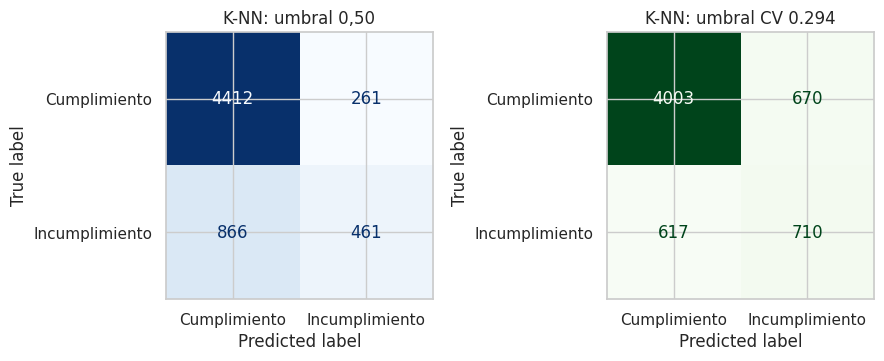

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(9, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_test_knn_05,
    display_labels=["Cumplimiento", "Incumplimiento"],
    cmap="Blues",
    colorbar=False,
    ax=ejes[0],
)
ejes[0].set_title("K-NN: umbral 0,50")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_test_knn_f1,
    display_labels=["Cumplimiento", "Incumplimiento"],
    cmap="Greens",
    colorbar=False,
    ax=ejes[1],
)
ejes[1].set_title(f"K-NN: umbral CV {umbral_f1_knn:.3f}")

plt.tight_layout()
plt.show()


## 5.10 Curvas ROC y precisión-exhaustividad

La curva ROC resumió la discriminación entre las dos clases a través de todos los umbrales. La curva precisión-exhaustividad fue especialmente informativa ante el desbalance, porque comparó la capacidad de recuperar incumplidos con la proporción de predicciones positivas correctas.


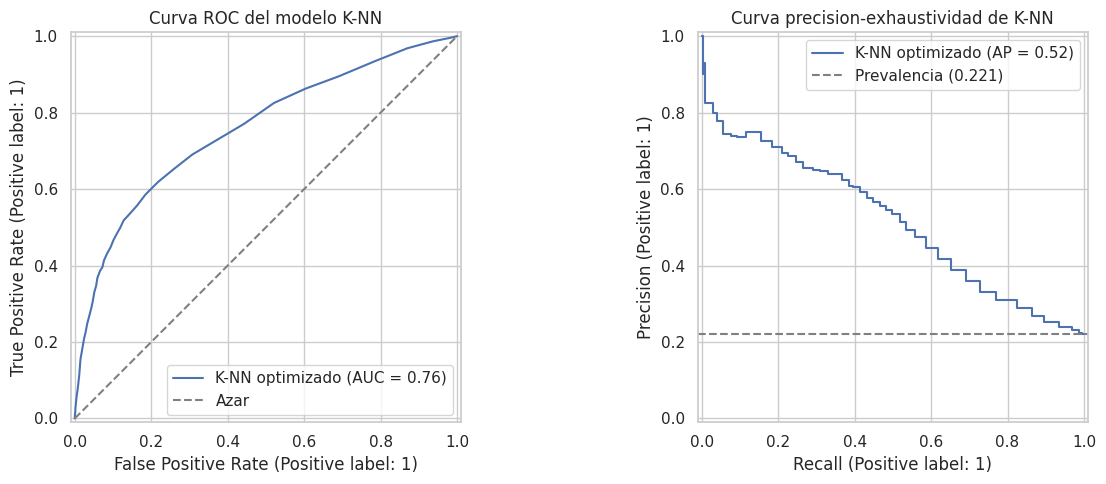

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test,
    probabilidades_test_knn,
    name="K-NN optimizado",
    ax=ejes[0],
)
ejes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ejes[0].set_title("Curva ROC del modelo K-NN")
ejes[0].legend(loc="lower right")

PrecisionRecallDisplay.from_predictions(
    y_test,
    probabilidades_test_knn,
    name="K-NN optimizado",
    ax=ejes[1],
)
ejes[1].axhline(
    y=y_test.mean(),
    linestyle="--",
    color="gray",
    label=f"Prevalencia ({y_test.mean():.3f})",
)
ejes[1].set_title("Curva precision-exhaustividad de K-NN")
ejes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## 5.11 Intervalos de confianza mediante bootstrap

Para expresar la incertidumbre de las métricas finales se calcularon intervalos de confianza del 95 % mediante 500 remuestreos con reemplazo del conjunto de prueba. El remuestreo se aplicó a pares de valores reales y probabilidades, preservando su correspondencia.

Estos intervalos describen la variabilidad muestral del rendimiento en este conjunto; no sustituyen una validación externa con datos de otra institución o periodo.


In [ ]:
def intervalos_bootstrap_clasificacion(
    y_real,
    probabilidades,
    umbral,
    repeticiones=500,
    semilla=SEMILLA,
):
    y_array = np.asarray(y_real)
    prob_array = np.asarray(probabilidades)
    generador = np.random.default_rng(semilla)
    resultados = []

    for _ in range(repeticiones):
        indices = generador.integers(0, len(y_array), len(y_array))
        y_muestra = y_array[indices]
        prob_muestra = prob_array[indices]

        if np.unique(y_muestra).size < 2:
            continue

        pred_muestra = (prob_muestra >= umbral).astype(int)
        resultados.append({
            "ROC-AUC": roc_auc_score(y_muestra, prob_muestra),
            "PR-AUC": average_precision_score(y_muestra, prob_muestra),
            "Exactitud balanceada": balanced_accuracy_score(
                y_muestra, pred_muestra
            ),
            "Precision": precision_score(
                y_muestra, pred_muestra, zero_division=0
            ),
            "Exhaustividad": recall_score(
                y_muestra, pred_muestra, zero_division=0
            ),
            "F1": f1_score(y_muestra, pred_muestra, zero_division=0),
        })

    distribucion = pd.DataFrame(resultados)
    estimaciones = calcular_metricas_clasificacion(
        y_array,
        prob_array,
        (prob_array >= umbral).astype(int),
    )

    filas = []
    for metrica in distribucion.columns:
        filas.append({
            "metrica": metrica,
            "estimacion": estimaciones[metrica],
            "ic_95_inferior": distribucion[metrica].quantile(0.025),
            "ic_95_superior": distribucion[metrica].quantile(0.975),
        })

    return pd.DataFrame(filas)


ic_knn = intervalos_bootstrap_clasificacion(
    y_test,
    probabilidades_test_knn,
    umbral=umbral_f1_knn,
)

display(ic_knn.round(4))


,metrica,estimacion,ic_95_inferior,ic_95_superior
0,ROC-AUC,0.7562,0.7413,0.7750
1,PR-AUC,0.5162,0.4893,0.5492
2,Exactitud balanceada,0.6958,0.6805,0.7117
3,Precision,0.5145,0.4877,0.5439
4,Exhaustividad,0.5350,0.5077,0.5667
5,F1,0.5246,0.4998,0.5498


## 5.12 Resultado del modelo K-NN

Se conservaron los hiperparámetros seleccionados, el rendimiento de validación, las métricas de prueba, el umbral, la matriz de confusión, los intervalos de confianza y los tiempos de ejecución.

La interpretación consideró conjuntamente ROC-AUC, PR-AUC, exhaustividad, F1 y falsos negativos, debido a que la exactitud no fue suficiente ante el desbalance de clases.


In [ ]:
matriz_knn_f1 = confusion_matrix(y_test, predicciones_test_knn_f1)
tn_knn, fp_knn, fn_knn, tp_knn = matriz_knn_f1.ravel()

resumen_final_knn = pd.DataFrame({
    "elemento": [
        "Mejor ROC-AUC de validacion",
        "ROC-AUC de prueba",
        "PR-AUC de prueba",
        "Umbral seleccionado en entrenamiento",
        "Precision de prueba",
        "Exhaustividad de prueba",
        "F1 de prueba",
        "Falsos positivos",
        "Falsos negativos",
        "Tiempo de busqueda (s)",
        "Tiempo de prediccion (s)",
    ],
    "valor": [
        busqueda_knn.best_score_,
        metricas_knn_f1["ROC-AUC"],
        metricas_knn_f1["PR-AUC"],
        umbral_f1_knn,
        metricas_knn_f1["Precision"],
        metricas_knn_f1["Exhaustividad"],
        metricas_knn_f1["F1"],
        fp_knn,
        fn_knn,
        tiempo_busqueda_knn,
        tiempo_prediccion_knn,
    ],
})

display(resumen_final_knn.round(4))

resultados_modelos = pd.DataFrame([{
    "modelo": "K-NN",
    "roc_auc_cv": busqueda_knn.best_score_,
    "roc_auc_test": metricas_knn_f1["ROC-AUC"],
    "pr_auc_test": metricas_knn_f1["PR-AUC"],
    "precision_test": metricas_knn_f1["Precision"],
    "recall_test": metricas_knn_f1["Exhaustividad"],
    "f1_test": metricas_knn_f1["F1"],
    "accuracy_test": metricas_knn_f1["Exactitud"],
    "balanced_accuracy_test": metricas_knn_f1["Exactitud balanceada"],
    "umbral": umbral_f1_knn,
    "tiempo_busqueda_s": tiempo_busqueda_knn,
    "tiempo_prediccion_s": tiempo_prediccion_knn,
}])

print("Seccion 5.12 - Objetos disponibles para las siguientes secciones:")
print("- mejor_modelo_knn")
print("- busqueda_knn")
print("- probabilidades_test_knn")
print("- predicciones_test_knn_f1")
print("- tabla_metricas_test_knn")
print("- ic_knn")
print("- resultados_modelos")


,elemento,valor
0,Mejor ROC-AUC de validacion,0.7653
1,ROC-AUC de prueba,0.7562
2,PR-AUC de prueba,0.5162
3,Umbral seleccionado en entrenamiento,0.2941
4,Precision de prueba,0.5145
5,Exhaustividad de prueba,0.5350
6,F1 de prueba,0.5246
7,Falsos positivos,670.0000
8,Falsos negativos,617.0000
9,Tiempo de busqueda (s),107.5323


Seccion 5.12 - Objetos disponibles para las siguientes secciones:
- mejor_modelo_knn
- busqueda_knn
- probabilidades_test_knn
- predicciones_test_knn_f1
- tabla_metricas_test_knn
- ic_knn
- resultados_modelos


# 06_Modelo_Random_Forest

## 6.1 Objetivo y estrategia experimental

En esta fase se entrenó un bosque aleatorio (*Random Forest*), que combinó múltiples árboles de decisión para representar relaciones no lineales e interacciones entre variables.

Se mantuvieron las mismas particiones, características y métricas utilizadas con K-NN. La búsqueda comparó diferentes niveles de profundidad, tamaños mínimos de hoja y estrategias de ponderación. Los hiperparámetros y el umbral se definieron con el entrenamiento y el conjunto de prueba se utilizó únicamente para la evaluación final.


## 6.2 Importaciones y configuración del algoritmo

Se fijó la semilla aleatoria para garantizar reproducibilidad. Durante la búsqueda, el paralelismo se administró desde `GridSearchCV`; por ello, cada bosque utilizó un solo proceso interno y se evitó la competencia entre dos niveles de paralelización.


In [ ]:
import time

from sklearn.ensemble import RandomForestClassifier

print("Seccion 6.2 - RandomForestClassifier importado correctamente.")
print(f"Semilla aleatoria: {SEMILLA}")
print(f"Predictores disponibles: {X_train.shape[1]}")
print(f"Registros de entrenamiento: {len(X_train):,}")
print(f"Registros de prueba reservados: {len(X_test):,}")


Seccion 6.2 - RandomForestClassifier importado correctamente.
Semilla aleatoria: 42
Predictores disponibles: 29
Registros de entrenamiento: 24,000
Registros de prueba reservados: 6,000


## 6.3 Random Forest con configuración inicial

Como referencia interna se evaluó un bosque de 300 árboles, sin ponderación de clases y con selección de la raíz cuadrada del número de características en cada división. El preprocesamiento permaneció dentro de la canalización para que la codificación se ajustara de manera independiente en cada partición.


In [ ]:
pipeline_rf_inicial = Pipeline(
    steps=[
        ("preprocesamiento", clone(preprocesador_arboles)),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=300,
                max_features="sqrt",
                class_weight=None,
                random_state=SEMILLA,
                n_jobs=1,
            ),
        ),
    ]
)

cv_rf_inicial = cross_validate(
    pipeline_rf_inicial,
    X_train,
    y_train,
    cv=validacion_cruzada,
    scoring=metricas_validacion,
    n_jobs=-1,
    return_train_score=False,
)

resumen_rf_inicial = resumir_validacion_cruzada(
    "Random Forest inicial", cv_rf_inicial
)

comparacion_inicial_rf = pd.DataFrame(
    [resumen_referencia, resumen_rf_inicial]
).set_index("modelo")

display(comparacion_inicial_rf.round(4))


,roc_auc_media,roc_auc_desv,pr_auc_media,pr_auc_desv,precision_media,precision_desv,recall_media,recall_desv,f1_media,f1_desv,accuracy_media,accuracy_desv,tiempo_ajuste_s,tiempo_evaluacion_s
modelo,,,,,,,,,,,,,,
Clasificador de referencia,0.5000,0.0000,0.2212,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7788,0.0001,0.0182,0.0572
Random Forest inicial,0.7709,0.0046,0.5395,0.0084,0.6472,0.0162,0.3795,0.0113,0.4784,0.0117,0.8170,0.0039,24.5125,0.5367


## 6.4 Optimización de hiperparámetros

Se evaluaron 16 configuraciones mediante 80 ajustes. Se compararon el número de árboles, la profundidad, el tamaño mínimo de hoja, el número de variables consideradas en cada división y las estrategias de ponderación de clases.

La selección se realizó mediante ROC-AUC de validación. Las métricas dependientes del umbral se conservaron para analizar el efecto sobre la detección de incumplidos.


In [ ]:
pipeline_rf = Pipeline(
    steps=[
        ("preprocesamiento", clone(preprocesador_arboles)),
        (
            "modelo",
            RandomForestClassifier(
                random_state=SEMILLA,
                n_jobs=1,
            ),
        ),
    ]
)

espacio_parametros_rf = [
    {
        "modelo__n_estimators": [300],
        "modelo__max_depth": [None, 12, 20],
        "modelo__min_samples_split": [2],
        "modelo__min_samples_leaf": [1, 5],
        "modelo__max_features": ["sqrt"],
        "modelo__class_weight": [None, "balanced"],
    },
    {
        "modelo__n_estimators": [500],
        "modelo__max_depth": [12, 20],
        "modelo__min_samples_split": [2],
        "modelo__min_samples_leaf": [2, 5],
        "modelo__max_features": [0.5],
        "modelo__class_weight": ["balanced_subsample"],
    },
]

busqueda_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=espacio_parametros_rf,
    scoring=metricas_validacion,
    refit="roc_auc",
    cv=validacion_cruzada,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise",
)

inicio_busqueda_rf = time.perf_counter()
busqueda_rf.fit(X_train, y_train)
tiempo_busqueda_rf = time.perf_counter() - inicio_busqueda_rf

mejor_modelo_rf = busqueda_rf.best_estimator_

print(f"Seccion 6.4 - Combinaciones evaluadas: {len(busqueda_rf.cv_results_['params'])}")
print(
    "Ajustes totales: "
    f"{len(busqueda_rf.cv_results_['params']) * validacion_cruzada.n_splits}"
)
print(f"Tiempo total de busqueda: {tiempo_busqueda_rf:.2f} segundos")
print(f"Mejor ROC-AUC de validacion: {busqueda_rf.best_score_:.4f}")
print("Mejores hiperparametros:")
display(pd.Series(busqueda_rf.best_params_, name="valor").to_frame())


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Seccion 6.4 - Combinaciones evaluadas: 16
Ajustes totales: 80
Tiempo total de busqueda: 1745.37 segundos
Mejor ROC-AUC de validacion: 0.7853
Mejores hiperparametros:


,valor
modelo__class_weight,None
modelo__max_depth,12
modelo__max_features,sqrt
modelo__min_samples_leaf,5
modelo__min_samples_split,2
modelo__n_estimators,300


## 6.5 Resultados de la validación cruzada

Las configuraciones se ordenaron por ROC-AUC media. Además de las métricas predictivas, se conservaron los resultados de entrenamiento para examinar la diferencia entre el ajuste del modelo y su rendimiento fuera de muestra. Una brecha amplia habría indicado mayor riesgo de sobreajuste.


In [ ]:
resultados_busqueda_rf = pd.DataFrame(busqueda_rf.cv_results_)

columnas_resultados_rf = [
    "rank_test_roc_auc",
    "param_modelo__n_estimators",
    "param_modelo__max_depth",
    "param_modelo__min_samples_leaf",
    "param_modelo__max_features",
    "param_modelo__class_weight",
    "mean_train_roc_auc",
    "mean_test_roc_auc",
    "std_test_roc_auc",
    "mean_test_pr_auc",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_accuracy",
    "mean_fit_time",
    "mean_score_time",
]

tabla_resultados_rf = (
    resultados_busqueda_rf[columnas_resultados_rf]
    .sort_values("rank_test_roc_auc")
    .reset_index(drop=True)
)

tabla_resultados_rf = tabla_resultados_rf.rename(columns={
    "rank_test_roc_auc": "ranking",
    "param_modelo__n_estimators": "n_arboles",
    "param_modelo__max_depth": "profundidad_maxima",
    "param_modelo__min_samples_leaf": "minimo_hoja",
    "param_modelo__max_features": "variables_por_division",
    "param_modelo__class_weight": "ponderacion_clases",
    "mean_train_roc_auc": "roc_auc_entrenamiento",
    "mean_test_roc_auc": "roc_auc_validacion",
    "std_test_roc_auc": "roc_auc_desv",
    "mean_test_pr_auc": "pr_auc_validacion",
    "mean_test_precision": "precision_validacion",
    "mean_test_recall": "recall_validacion",
    "mean_test_f1": "f1_validacion",
    "mean_test_accuracy": "accuracy_validacion",
    "mean_fit_time": "ajuste_s",
    "mean_score_time": "evaluacion_s",
})

tabla_resultados_rf["brecha_roc_auc"] = (
    tabla_resultados_rf["roc_auc_entrenamiento"]
    - tabla_resultados_rf["roc_auc_validacion"]
)

display(tabla_resultados_rf.head(10).round(4))


,ranking,n_arboles,profundidad_maxima,minimo_hoja,variables_por_division,ponderacion_clases,roc_auc_entrenamiento,roc_auc_validacion,roc_auc_desv,pr_auc_validacion,precision_validacion,recall_validacion,f1_validacion,accuracy_validacion,ajuste_s,evaluacion_s,brecha_roc_auc
0,1,300,12,5,sqrt,None,0.9081,0.7853,0.0036,0.5604,0.6752,0.3692,0.4773,0.8211,17.6242,0.3164,0.1227
1,2,300,12,5,sqrt,balanced,0.9195,0.7850,0.0051,0.5587,0.5229,0.5685,0.5447,0.7897,17.3510,0.3256,0.1345
2,3,300,12,1,sqrt,None,0.9340,0.7843,0.0040,0.5588,0.6791,0.3707,0.4795,0.8220,18.4251,0.3088,0.1497
3,4,300,20,5,sqrt,balanced,0.9688,0.7824,0.0046,0.5541,0.5550,0.5340,0.5443,0.8022,20.4560,0.4248,0.1864
4,5,300,None,5,sqrt,None,0.9703,0.7823,0.0046,0.5556,0.6709,0.3686,0.4757,0.8203,21.9191,0.4260,0.1881
5,6,500,12,5,0.5,balanced_subsample,0.9403,0.7821,0.0052,0.5605,0.5369,0.5476,0.5422,0.7954,90.6662,0.6200,0.1581
6,7,300,12,1,sqrt,balanced,0.9410,0.7821,0.0060,0.5548,0.5433,0.5410,0.5421,0.7978,17.8641,0.3333,0.1589
7,8,300,None,5,sqrt,balanced,0.9710,0.7819,0.0039,0.5545,0.5546,0.5291,0.5415,0.8018,20.7496,0.5407,0.1891
8,9,300,20,5,sqrt,None,0.9667,0.7818,0.0028,0.5550,0.6701,0.3688,0.4757,0.8202,21.0355,0.5896,0.1849
9,10,500,12,2,0.5,balanced_subsample,0.9510,0.7808,0.0057,0.5586,0.5429,0.5297,0.5362,0.7973,94.2321,0.5472,0.1702


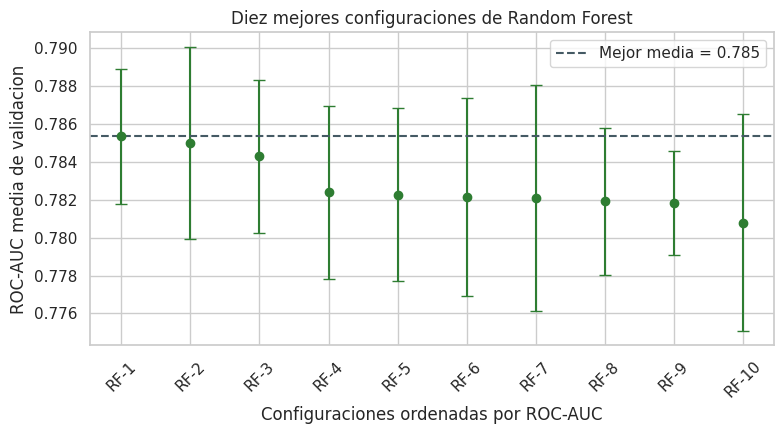

In [ ]:
top_rf = tabla_resultados_rf.head(10).copy()
top_rf["configuracion"] = [f"RF-{i + 1}" for i in range(len(top_rf))]

plt.figure(figsize=(8, 4.5))
plt.errorbar(
    top_rf["configuracion"],
    top_rf["roc_auc_validacion"],
    yerr=top_rf["roc_auc_desv"],
    fmt="o",
    capsize=4,
    color="#2E7D32",
)
plt.axhline(
    busqueda_rf.best_score_,
    linestyle="--",
    color="#455A64",
    label=f"Mejor media = {busqueda_rf.best_score_:.3f}",
)
plt.xlabel("Configuraciones ordenadas por ROC-AUC")
plt.ylabel("ROC-AUC media de validacion")
plt.title("Diez mejores configuraciones de Random Forest")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 6.6 Diagnóstico de sobreajuste

La diferencia entre ROC-AUC de entrenamiento y validación permitió valorar la capacidad de generalización. Se reportó la brecha de la configuración seleccionada y se contrastó con un umbral descriptivo de 0,05. Este criterio no sustituyó la evaluación final, pero ayudó a identificar modelos excesivamente complejos.


In [ ]:
fila_mejor_rf = tabla_resultados_rf.iloc[0]
brecha_mejor_rf = float(fila_mejor_rf["brecha_roc_auc"])

diagnostico_sobreajuste_rf = pd.DataFrame({
    "indicador": [
        "ROC-AUC media de entrenamiento",
        "ROC-AUC media de validacion",
        "Brecha entrenamiento-validacion",
    ],
    "valor": [
        fila_mejor_rf["roc_auc_entrenamiento"],
        fila_mejor_rf["roc_auc_validacion"],
        brecha_mejor_rf,
    ],
})

display(diagnostico_sobreajuste_rf.round(4))

if brecha_mejor_rf < 0.05:
    print("Seccion 6.6 - La brecha fue inferior a 0,05; no se observo una señal fuerte de sobreajuste.")
else:
    print("La brecha fue igual o superior a 0,05; el resultado requiere cautela por posible sobreajuste.")


,indicador,valor
0,ROC-AUC media de entrenamiento,0.9081
1,ROC-AUC media de validacion,0.7853
2,Brecha entrenamiento-validacion,0.1227


La brecha fue igual o superior a 0,05; el resultado requiere cautela por posible sobreajuste.


## 6.7 Selección del umbral con predicciones fuera de muestra

Se generaron probabilidades fuera de muestra para cada registro de entrenamiento mediante las mismas cinco particiones estratificadas. El umbral alternativo se eligió maximizando F1, sin consultar el conjunto de prueba. Esta regla permitió equilibrar precisión y exhaustividad y evaluar el efecto de la ponderación de clases en una decisión operativa.


In [ ]:
inicio_oof_rf = time.perf_counter()

probabilidades_oof_rf = cross_val_predict(
    mejor_modelo_rf,
    X_train,
    y_train,
    cv=validacion_cruzada,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

tiempo_oof_rf = time.perf_counter() - inicio_oof_rf

precision_oof_rf, recall_oof_rf, umbrales_oof_rf = precision_recall_curve(
    y_train, probabilidades_oof_rf
)

f1_oof_rf = (
    2 * precision_oof_rf[:-1] * recall_oof_rf[:-1]
    / (precision_oof_rf[:-1] + recall_oof_rf[:-1] + 1e-12)
)

indice_mejor_f1_rf = int(np.nanargmax(f1_oof_rf))
umbral_f1_rf = float(umbrales_oof_rf[indice_mejor_f1_rf])

tabla_umbral_oof_rf = pd.DataFrame({
    "umbral": [umbral_f1_rf],
    "precision_oof": [precision_oof_rf[indice_mejor_f1_rf]],
    "recall_oof": [recall_oof_rf[indice_mejor_f1_rf]],
    "f1_oof": [f1_oof_rf[indice_mejor_f1_rf]],
    "roc_auc_oof": [roc_auc_score(y_train, probabilidades_oof_rf)],
    "pr_auc_oof": [average_precision_score(y_train, probabilidades_oof_rf)],
})

display(tabla_umbral_oof_rf.round(4))
print(f"Seccion 6.7 - Tiempo para predicciones fuera de muestra: {tiempo_oof_rf:.2f} segundos")


,umbral,precision_oof,recall_oof,f1_oof,roc_auc_oof,pr_auc_oof
0,0.2705,0.5055,0.5963,0.5472,0.7853,0.5592


Seccion 6.7 - Tiempo para predicciones fuera de muestra: 48.69 segundos


## 6.8 Evaluación final en el conjunto de prueba

Una vez cerrados los hiperparámetros y el umbral, el mejor bosque se aplicó a las 6.000 observaciones reservadas. Se compararon el umbral convencional de 0,50 y el umbral seleccionado en entrenamiento. ROC-AUC y PR-AUC fueron iguales en ambas filas porque se calcularon sobre probabilidades; las métricas de clasificación sí cambiaron con el umbral.


In [ ]:
inicio_prediccion_rf = time.perf_counter()
probabilidades_test_rf = mejor_modelo_rf.predict_proba(X_test)[:, 1]
tiempo_prediccion_rf = time.perf_counter() - inicio_prediccion_rf

predicciones_test_rf_05 = (probabilidades_test_rf >= 0.50).astype(int)
predicciones_test_rf_f1 = (
    probabilidades_test_rf >= umbral_f1_rf
).astype(int)

metricas_rf_05 = calcular_metricas_clasificacion(
    y_test, probabilidades_test_rf, predicciones_test_rf_05
)
metricas_rf_f1 = calcular_metricas_clasificacion(
    y_test, probabilidades_test_rf, predicciones_test_rf_f1
)

tabla_metricas_test_rf = pd.DataFrame(
    [metricas_rf_05, metricas_rf_f1],
    index=["Umbral 0,50", f"Umbral CV {umbral_f1_rf:.3f}"],
)

display(tabla_metricas_test_rf.round(4))
print(f"Seccion 6.8 - Tiempo de prediccion de 6.000 registros: {tiempo_prediccion_rf:.4f} segundos")
print(f"Tiempo por registro: {tiempo_prediccion_rf / len(X_test) * 1000:.6f} ms")


,ROC-AUC,PR-AUC,Exactitud,Exactitud balanceada,Precision,Exhaustividad,F1
"Umbral 0,50",0.7756,0.5564,0.8150,0.6503,0.6497,0.3549,0.4591
Umbral CV 0.270,0.7756,0.5564,0.7805,0.7072,0.5033,0.5757,0.5371


Seccion 6.8 - Tiempo de prediccion de 6.000 registros: 0.1652 segundos
Tiempo por registro: 0.027528 ms


In [ ]:
reporte_rf_05 = pd.DataFrame(
    classification_report(
        y_test,
        predicciones_test_rf_05,
        target_names=["Cumplimiento", "Incumplimiento"],
        output_dict=True,
        zero_division=0,
    )
).T

reporte_rf_f1 = pd.DataFrame(
    classification_report(
        y_test,
        predicciones_test_rf_f1,
        target_names=["Cumplimiento", "Incumplimiento"],
        output_dict=True,
        zero_division=0,
    )
).T

print("Seccion 6.8 - Reporte con umbral 0,50")
display(reporte_rf_05.round(4))

print(f"Reporte con umbral seleccionado en validacion ({umbral_f1_rf:.3f})")
display(reporte_rf_f1.round(4))


Seccion 6.8 - Reporte con umbral 0,50


,precision,recall,f1-score,support
Cumplimiento,0.8377,0.9456,0.8884,4673.000
Incumplimiento,0.6497,0.3549,0.4591,1327.000
accuracy,0.8150,0.8150,0.8150,0.815
macro avg,0.7437,0.6503,0.6737,6000.000
weighted avg,0.7961,0.8150,0.7935,6000.000


Reporte con umbral seleccionado en validacion (0.270)


,precision,recall,f1-score,support
Cumplimiento,0.8744,0.8386,0.8561,4673.0000
Incumplimiento,0.5033,0.5757,0.5371,1327.0000
accuracy,0.7805,0.7805,0.7805,0.7805
macro avg,0.6888,0.7072,0.6966,6000.0000
weighted avg,0.7923,0.7805,0.7856,6000.0000


## 6.9 Matrices de confusión

Las matrices mostraron el intercambio entre falsos positivos y falsos negativos al modificar el umbral. Para la gestión del riesgo crediticio se prestó especial atención a los falsos negativos, porque correspondieron a clientes incumplidos clasificados como cumplidos.


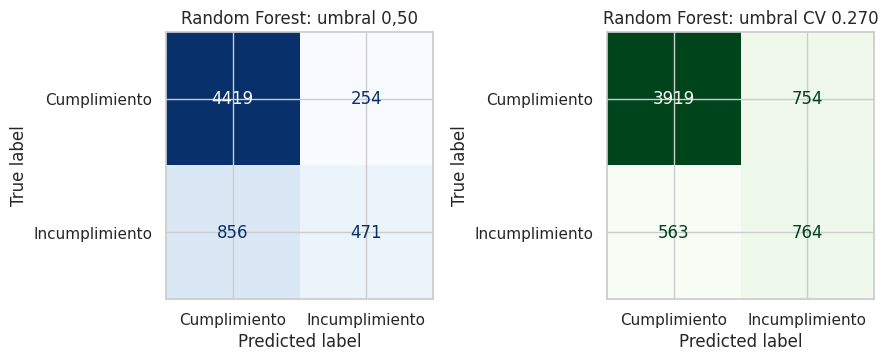

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(9, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_test_rf_05,
    display_labels=["Cumplimiento", "Incumplimiento"],
    cmap="Blues",
    colorbar=False,
    ax=ejes[0],
)
ejes[0].set_title("Random Forest: umbral 0,50")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_test_rf_f1,
    display_labels=["Cumplimiento", "Incumplimiento"],
    cmap="Greens",
    colorbar=False,
    ax=ejes[1],
)
ejes[1].set_title(f"Random Forest: umbral CV {umbral_f1_rf:.3f}")

plt.tight_layout()
plt.show()


## 6.10 Curvas ROC y precisión-exhaustividad

La curva ROC evaluó la discriminación global del modelo a través de todos los umbrales. La curva precisión-exhaustividad complementó este análisis al concentrarse en la clase incumplida y comparar el resultado con su prevalencia en prueba.


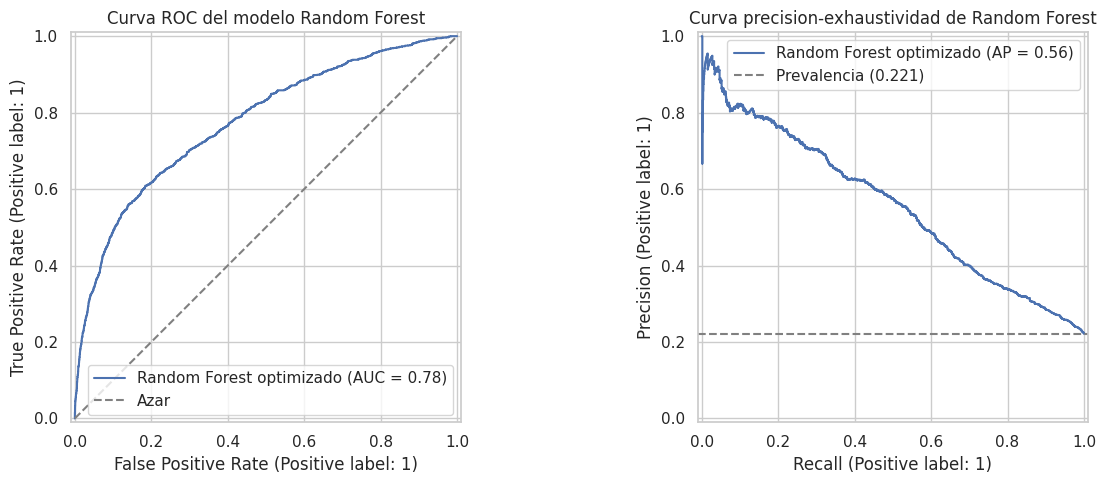

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test,
    probabilidades_test_rf,
    name="Random Forest optimizado",
    ax=ejes[0],
)
ejes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ejes[0].set_title("Curva ROC del modelo Random Forest")
ejes[0].legend(loc="lower right")

PrecisionRecallDisplay.from_predictions(
    y_test,
    probabilidades_test_rf,
    name="Random Forest optimizado",
    ax=ejes[1],
)
ejes[1].axhline(
    y=y_test.mean(),
    linestyle="--",
    color="gray",
    label=f"Prevalencia ({y_test.mean():.3f})",
)
ejes[1].set_title("Curva precision-exhaustividad de Random Forest")
ejes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## 6.11 Intervalos de confianza mediante bootstrap

Se reutilizó el procedimiento de 500 remuestreos definido en la sección 05. Los intervalos del 95 % se calcularon con el umbral seleccionado en entrenamiento, lo que permitió expresar la incertidumbre de las métricas finales bajo el mismo método aplicado a K-NN.


In [ ]:
ic_rf = intervalos_bootstrap_clasificacion(
    y_test,
    probabilidades_test_rf,
    umbral=umbral_f1_rf,
)

display(ic_rf.round(4))


,metrica,estimacion,ic_95_inferior,ic_95_superior
0,ROC-AUC,0.7756,0.7612,0.7925
1,PR-AUC,0.5564,0.5279,0.5873
2,Exactitud balanceada,0.7072,0.6935,0.7235
3,Precision,0.5033,0.4788,0.5298
4,Exhaustividad,0.5757,0.5494,0.6072
5,F1,0.5371,0.5145,0.5619


## 6.12 Importancia de las variables

Random Forest proporcionó una importancia basada en la disminución media de impureza acumulada por los árboles. Las categorías creadas mediante codificación de una variable por categoría se agruparon nuevamente en su variable original para evitar que sexo, educación y estado civil quedaran fragmentados.

Esta medida fue exploratoria: una importancia alta indicó uso frecuente para reducir impureza, pero no demostró causalidad y pudo favorecer variables continuas o con más puntos de corte. La interpretación avanzada y los valores SHAP se reservaron para la sección 09.


,variable_original,importancia
0,PAY_0,0.1551
1,MESES_CON_RETRASO,0.0926
2,RETRASO_MAXIMO_6M,0.0801
3,PAY_2,0.0543
4,UTILIZACION_PROMEDIO_6M,0.0403
5,PAGO_PROMEDIO_6M,0.0383
6,PAY_3,0.0349
7,LIMIT_BAL,0.0309
8,BILL_AMT1,0.0303
9,FACTURACION_PROMEDIO_6M,0.0302


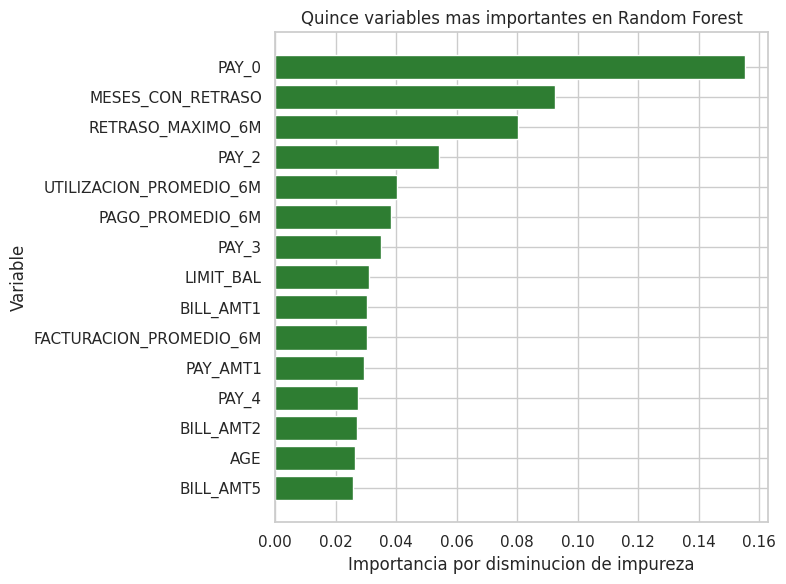

In [ ]:
preprocesamiento_rf_ajustado = mejor_modelo_rf.named_steps["preprocesamiento"]
bosque_rf_ajustado = mejor_modelo_rf.named_steps["modelo"]

nombres_transformados_rf = preprocesamiento_rf_ajustado.get_feature_names_out()

importancia_transformada_rf = pd.DataFrame({
    "variable_transformada": nombres_transformados_rf,
    "importancia": bosque_rf_ajustado.feature_importances_,
}).sort_values("importancia", ascending=False)


def recuperar_variable_original(nombre):
    for variable in variables_nominales:
        if nombre.startswith(f"{variable}_"):
            return variable
    return nombre


importancia_transformada_rf["variable_original"] = (
    importancia_transformada_rf["variable_transformada"]
    .map(recuperar_variable_original)
)

importancia_agrupada_rf = (
    importancia_transformada_rf
    .groupby("variable_original", as_index=False)["importancia"]
    .sum()
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

display(importancia_agrupada_rf.head(15).round(4))

top_importancia_rf = importancia_agrupada_rf.head(15).sort_values("importancia")

plt.figure(figsize=(8, 6))
plt.barh(
    top_importancia_rf["variable_original"],
    top_importancia_rf["importancia"],
    color="#2E7D32",
)
plt.xlabel("Importancia por disminucion de impureza")
plt.ylabel("Variable")
plt.title("Quince variables mas importantes en Random Forest")
plt.tight_layout()
plt.show()


## 6.13 Resultado del modelo Random Forest

Se conservaron los hiperparámetros, las métricas de prueba, el umbral, los errores de clasificación, la brecha entre entrenamiento y validación, la importancia de las variables y los tiempos.

Los resultados se añadieron a la tabla comparativa sin reemplazar los obtenidos con K-NN.


In [ ]:
matriz_rf_f1 = confusion_matrix(y_test, predicciones_test_rf_f1)
tn_rf, fp_rf, fn_rf, tp_rf = matriz_rf_f1.ravel()

resumen_final_rf = pd.DataFrame({
    "elemento": [
        "Mejor ROC-AUC de validacion",
        "ROC-AUC de prueba",
        "PR-AUC de prueba",
        "Umbral seleccionado en entrenamiento",
        "Precision de prueba",
        "Exhaustividad de prueba",
        "F1 de prueba",
        "Falsos positivos",
        "Falsos negativos",
        "Brecha ROC-AUC entrenamiento-validacion",
        "Tiempo de busqueda (s)",
        "Tiempo de prediccion (s)",
    ],
    "valor": [
        busqueda_rf.best_score_,
        metricas_rf_f1["ROC-AUC"],
        metricas_rf_f1["PR-AUC"],
        umbral_f1_rf,
        metricas_rf_f1["Precision"],
        metricas_rf_f1["Exhaustividad"],
        metricas_rf_f1["F1"],
        fp_rf,
        fn_rf,
        brecha_mejor_rf,
        tiempo_busqueda_rf,
        tiempo_prediccion_rf,
    ],
})

display(resumen_final_rf.round(4))

fila_resultados_rf = pd.DataFrame([{
    "modelo": "Random Forest",
    "roc_auc_cv": busqueda_rf.best_score_,
    "roc_auc_test": metricas_rf_f1["ROC-AUC"],
    "pr_auc_test": metricas_rf_f1["PR-AUC"],
    "precision_test": metricas_rf_f1["Precision"],
    "recall_test": metricas_rf_f1["Exhaustividad"],
    "f1_test": metricas_rf_f1["F1"],
    "accuracy_test": metricas_rf_f1["Exactitud"],
    "balanced_accuracy_test": metricas_rf_f1["Exactitud balanceada"],
    "umbral": umbral_f1_rf,
    "tiempo_busqueda_s": tiempo_busqueda_rf,
    "tiempo_prediccion_s": tiempo_prediccion_rf,
}])

resultados_modelos = pd.concat(
    [
        resultados_modelos[
            resultados_modelos["modelo"] != "Random Forest"
        ],
        fila_resultados_rf,
    ],
    ignore_index=True,
)

display(resultados_modelos.round(4))

print("Seccion 6.13 - Objetos disponibles para las siguientes secciones:")
print("- mejor_modelo_rf")
print("- busqueda_rf")
print("- probabilidades_test_rf")
print("- predicciones_test_rf_f1")
print("- tabla_metricas_test_rf")
print("- ic_rf")
print("- importancia_agrupada_rf")
print("- resultados_modelos")


,elemento,valor
0,Mejor ROC-AUC de validacion,0.7853
1,ROC-AUC de prueba,0.7756
2,PR-AUC de prueba,0.5564
3,Umbral seleccionado en entrenamiento,0.2705
4,Precision de prueba,0.5033
5,Exhaustividad de prueba,0.5757
6,F1 de prueba,0.5371
7,Falsos positivos,754.0000
8,Falsos negativos,563.0000
9,Brecha ROC-AUC entrenamiento-validacion,0.1227


,modelo,roc_auc_cv,roc_auc_test,pr_auc_test,precision_test,recall_test,f1_test,accuracy_test,balanced_accuracy_test,umbral,tiempo_busqueda_s,tiempo_prediccion_s
0,K-NN,0.7653,0.7562,0.5162,0.5145,0.5350,0.5246,0.7855,0.6958,0.2941,107.5323,0.7880
1,Random Forest,0.7853,0.7756,0.5564,0.5033,0.5757,0.5371,0.7805,0.7072,0.2705,1745.3719,0.1652


Seccion 6.13 - Objetos disponibles para las siguientes secciones:
- mejor_modelo_rf
- busqueda_rf
- probabilidades_test_rf
- predicciones_test_rf_f1
- tabla_metricas_test_rf
- ic_rf
- importancia_agrupada_rf
- resultados_modelos


# 07_Modelo_XGBoost

## 7.1 Objetivo y estrategia experimental

En esta fase se entrenó el algoritmo de potenciación extrema del gradiente (*Extreme Gradient Boosting*, XGBoost). Se utilizaron las mismas particiones, variables y métricas definidas para K-NN y Random Forest.

La búsqueda comparó parámetros de complejidad, aprendizaje, muestreo, regularización y ponderación de la clase positiva. Los hiperparámetros y el umbral se seleccionaron con el conjunto de entrenamiento; posteriormente se realizó la evaluación final sobre el conjunto de prueba.


## 7.2 Importaciones y configuración del algoritmo

Se utilizó la interfaz de XGBoost compatible con scikit-learn. El método de construcción por histogramas (`tree_method="hist"`) redujo el coste computacional. El paralelismo se administró desde `GridSearchCV`; por ello, cada ajuste de XGBoost utilizó un solo proceso interno.

La versión instalada se mostró para facilitar la reproducibilidad. Si el entorno no dispone del paquete, deberá ejecutarse previamente `%pip install xgboost` y reiniciarse la sesión.

In [ ]:
import time

try:
    import xgboost as xgb
    from xgboost import XGBClassifier
except ImportError as error:
    raise ImportError(
        "XGBoost no esta instalado. Ejecute `%pip install xgboost`, "
        "reinicie la sesion y vuelva a ejecutar el notebook."
    ) from error

print(f"Seccion 7.2 - XGBoost: {xgb.__version__}")
print(f"Semilla aleatoria: {SEMILLA}")
print(f"Predictores disponibles: {X_train.shape[1]}")
print(f"Registros de entrenamiento: {len(X_train):,}")
print(f"Registros de prueba reservados: {len(X_test):,}")
print(f"scale_pos_weight de referencia: {scale_pos_weight_inicial:.3f}")

Seccion 7.2 - XGBoost: 3.4.1
Semilla aleatoria: 42
Predictores disponibles: 29
Registros de entrenamiento: 24,000
Registros de prueba reservados: 6,000
scale_pos_weight de referencia: 3.521


## 7.3 XGBoost con configuración inicial

Como referencia interna se evaluó un modelo con 300 rondas de potenciación, profundidad máxima de tres, tasa de aprendizaje de 0,05 y muestreo del 80 % de observaciones y variables. Inicialmente no se ponderaron las clases. El preprocesamiento se mantuvo dentro de la canalización para que la codificación se ajustara de manera independiente en cada partición.

In [ ]:
pipeline_xgb_inicial = Pipeline(
    steps=[
        ("preprocesamiento", clone(preprocesador_arboles)),
        (
            "modelo",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                n_estimators=300,
                max_depth=3,
                learning_rate=0.05,
                min_child_weight=1,
                subsample=0.80,
                colsample_bytree=0.80,
                reg_alpha=0.0,
                reg_lambda=1.0,
                scale_pos_weight=1.0,
                importance_type="gain",
                random_state=SEMILLA,
                n_jobs=1,
                verbosity=0,
            ),
        ),
    ]
)

cv_xgb_inicial = cross_validate(
    pipeline_xgb_inicial,
    X_train,
    y_train,
    cv=validacion_cruzada,
    scoring=metricas_validacion,
    n_jobs=-1,
    return_train_score=False,
)

resumen_xgb_inicial = resumir_validacion_cruzada(
    "XGBoost inicial", cv_xgb_inicial
)

comparacion_inicial_xgb = pd.DataFrame(
    [resumen_referencia, resumen_xgb_inicial]
).set_index("modelo")

display(comparacion_inicial_xgb.round(4))

,roc_auc_media,roc_auc_desv,pr_auc_media,pr_auc_desv,precision_media,precision_desv,recall_media,recall_desv,f1_media,f1_desv,accuracy_media,accuracy_desv,tiempo_ajuste_s,tiempo_evaluacion_s
modelo,,,,,,,,,,,,,,
Clasificador de referencia,0.5000,0.0000,0.2212,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7788,0.0001,0.0182,0.0572
XGBoost inicial,0.7869,0.0065,0.5615,0.0106,0.6749,0.0139,0.3688,0.0031,0.4769,0.0039,0.8210,0.0024,0.8464,0.0608


## 7.4 Optimización de hiperparámetros

Se evaluaron 12 configuraciones mediante 60 ajustes. La búsqueda incluyó el número de estimadores, la profundidad, la tasa de aprendizaje, el peso mínimo de los nodos, el muestreo de observaciones y variables, la regularización y `scale_pos_weight`.

La selección se realizó mediante ROC-AUC. El muestreo y las penalizaciones L1 y L2 permitieron controlar la complejidad del modelo.


In [ ]:
pipeline_xgb = Pipeline(
    steps=[
        ("preprocesamiento", clone(preprocesador_arboles)),
        (
            "modelo",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                importance_type="gain",
                random_state=SEMILLA,
                n_jobs=1,
                verbosity=0,
            ),
        ),
    ]
)

espacio_parametros_xgb = [
    {
        "modelo__n_estimators": [300],
        "modelo__max_depth": [3, 5],
        "modelo__learning_rate": [0.03, 0.08],
        "modelo__min_child_weight": [1],
        "modelo__subsample": [0.80],
        "modelo__colsample_bytree": [0.80],
        "modelo__reg_alpha": [0.0],
        "modelo__reg_lambda": [1.0],
        "modelo__scale_pos_weight": [1.0, scale_pos_weight_inicial],
    },
    {
        "modelo__n_estimators": [500],
        "modelo__max_depth": [3, 4],
        "modelo__learning_rate": [0.03],
        "modelo__min_child_weight": [5],
        "modelo__subsample": [0.80],
        "modelo__colsample_bytree": [0.80],
        "modelo__reg_alpha": [0.10],
        "modelo__reg_lambda": [2.0],
        "modelo__scale_pos_weight": [1.0, scale_pos_weight_inicial],
    },
]

busqueda_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=espacio_parametros_xgb,
    scoring=metricas_validacion,
    refit="roc_auc",
    cv=validacion_cruzada,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    error_score="raise",
)

inicio_busqueda_xgb = time.perf_counter()
busqueda_xgb.fit(X_train, y_train)
tiempo_busqueda_xgb = time.perf_counter() - inicio_busqueda_xgb

mejor_modelo_xgb = busqueda_xgb.best_estimator_

print(f"Seccion 7.4 - Combinaciones evaluadas: {len(busqueda_xgb.cv_results_['params'])}")
print(
    "Ajustes totales: "
    f"{len(busqueda_xgb.cv_results_['params']) * validacion_cruzada.n_splits}"
)
print(f"Tiempo total de busqueda: {tiempo_busqueda_xgb:.2f} segundos")
print(f"Mejor ROC-AUC de validacion: {busqueda_xgb.best_score_:.4f}")
print("Mejores hiperparametros:")
display(pd.Series(busqueda_xgb.best_params_, name="valor").to_frame())

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Seccion 7.4 - Combinaciones evaluadas: 12
Ajustes totales: 60
Tiempo total de busqueda: 54.53 segundos
Mejor ROC-AUC de validacion: 0.7871
Mejores hiperparametros:


,valor
modelo__colsample_bytree,0.80
modelo__learning_rate,0.03
modelo__max_depth,3.00
modelo__min_child_weight,5.00
modelo__n_estimators,500.00
modelo__reg_alpha,0.10
modelo__reg_lambda,2.00
modelo__scale_pos_weight,1.00
modelo__subsample,0.80


## 7.5 Resultados de la validación cruzada

Las configuraciones se ordenaron por ROC-AUC media. Se conservaron las métricas de validación, los tiempos y el resultado de entrenamiento. La diferencia entre ROC-AUC de entrenamiento y validación permitió examinar la generalización y distinguir una mejora estable de un ajuste excesivo.

In [ ]:
resultados_busqueda_xgb = pd.DataFrame(busqueda_xgb.cv_results_)

columnas_resultados_xgb = [
    "rank_test_roc_auc",
    "param_modelo__n_estimators",
    "param_modelo__max_depth",
    "param_modelo__learning_rate",
    "param_modelo__min_child_weight",
    "param_modelo__scale_pos_weight",
    "mean_train_roc_auc",
    "mean_test_roc_auc",
    "std_test_roc_auc",
    "mean_test_pr_auc",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_accuracy",
    "mean_fit_time",
    "mean_score_time",
]

tabla_resultados_xgb = (
    resultados_busqueda_xgb[columnas_resultados_xgb]
    .sort_values("rank_test_roc_auc")
    .reset_index(drop=True)
)

tabla_resultados_xgb = tabla_resultados_xgb.rename(columns={
    "rank_test_roc_auc": "ranking",
    "param_modelo__n_estimators": "n_estimadores",
    "param_modelo__max_depth": "profundidad_maxima",
    "param_modelo__learning_rate": "tasa_aprendizaje",
    "param_modelo__min_child_weight": "peso_minimo_nodo",
    "param_modelo__scale_pos_weight": "ponderacion_positiva",
    "mean_train_roc_auc": "roc_auc_entrenamiento",
    "mean_test_roc_auc": "roc_auc_validacion",
    "std_test_roc_auc": "roc_auc_desv",
    "mean_test_pr_auc": "pr_auc_validacion",
    "mean_test_precision": "precision_validacion",
    "mean_test_recall": "recall_validacion",
    "mean_test_f1": "f1_validacion",
    "mean_test_accuracy": "accuracy_validacion",
    "mean_fit_time": "ajuste_s",
    "mean_score_time": "evaluacion_s",
})

tabla_resultados_xgb["brecha_roc_auc"] = (
    tabla_resultados_xgb["roc_auc_entrenamiento"]
    - tabla_resultados_xgb["roc_auc_validacion"]
)

display(tabla_resultados_xgb.head(12).round(4))

,ranking,n_estimadores,profundidad_maxima,tasa_aprendizaje,peso_minimo_nodo,ponderacion_positiva,roc_auc_entrenamiento,roc_auc_validacion,roc_auc_desv,pr_auc_validacion,precision_validacion,recall_validacion,f1_validacion,accuracy_validacion,ajuste_s,evaluacion_s,brecha_roc_auc
0,1,500,3,0.03,5,1.0000,0.8206,0.7871,0.0053,0.5605,0.6798,0.3679,0.4773,0.8218,1.3881,0.0889,0.0336
1,2,500,3,0.03,5,3.5206,0.8249,0.7869,0.0059,0.5617,0.4620,0.6470,0.5391,0.7552,1.4814,0.1310,0.0379
2,3,300,3,0.03,1,1.0000,0.8104,0.7868,0.0053,0.5620,0.6840,0.3665,0.4772,0.8224,0.9103,0.0659,0.0236
3,4,300,5,0.03,1,1.0000,0.8616,0.7866,0.0053,0.5643,0.6771,0.3728,0.4808,0.8219,1.4532,0.0843,0.0750
4,5,500,4,0.03,5,3.5206,0.8547,0.7865,0.0057,0.5633,0.4676,0.6399,0.5403,0.7591,1.7809,0.1191,0.0681
5,6,300,5,0.03,1,3.5206,0.8670,0.7865,0.0066,0.5653,0.4731,0.6316,0.5409,0.7628,1.4754,0.0838,0.0804
6,7,500,4,0.03,5,1.0000,0.8455,0.7865,0.0056,0.5607,0.6721,0.3709,0.4780,0.8208,1.8066,0.1039,0.0590
7,8,300,3,0.03,1,3.5206,0.8122,0.7863,0.0057,0.5607,0.4606,0.6495,0.5389,0.7542,1.1610,0.0871,0.0259
8,9,300,3,0.08,1,3.5206,0.8419,0.7844,0.0069,0.5568,0.4605,0.6432,0.5368,0.7544,0.8833,0.0651,0.0575
9,10,300,3,0.08,1,1.0000,0.8379,0.7844,0.0069,0.5581,0.6719,0.3696,0.4768,0.8206,1.1273,0.0876,0.0536


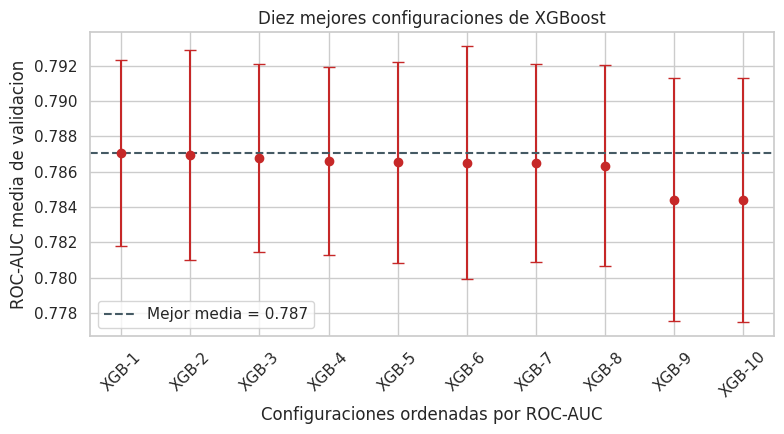

In [ ]:
top_xgb = tabla_resultados_xgb.head(10).copy()
top_xgb["configuracion"] = [f"XGB-{i + 1}" for i in range(len(top_xgb))]

plt.figure(figsize=(8, 4.5))
plt.errorbar(
    top_xgb["configuracion"],
    top_xgb["roc_auc_validacion"],
    yerr=top_xgb["roc_auc_desv"],
    fmt="o",
    capsize=4,
    color="#C62828",
)
plt.axhline(
    busqueda_xgb.best_score_,
    linestyle="--",
    color="#455A64",
    label=f"Mejor media = {busqueda_xgb.best_score_:.3f}",
)
plt.xlabel("Configuraciones ordenadas por ROC-AUC")
plt.ylabel("ROC-AUC media de validacion")
plt.title("Diez mejores configuraciones de XGBoost")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 7.6 Diagnóstico de sobreajuste

La diferencia entre ROC-AUC de entrenamiento y validación se utilizó como diagnóstico descriptivo de generalización. Una brecha inferior a 0,05 se interpretó como ausencia de una señal fuerte de sobreajuste; una brecha igual o superior requirió cautela. Este criterio no sustituyó la evaluación independiente del conjunto de prueba.

In [ ]:
fila_mejor_xgb = tabla_resultados_xgb.iloc[0]
brecha_mejor_xgb = float(fila_mejor_xgb["brecha_roc_auc"])

diagnostico_sobreajuste_xgb = pd.DataFrame({
    "indicador": [
        "ROC-AUC media de entrenamiento",
        "ROC-AUC media de validacion",
        "Brecha entrenamiento-validacion",
    ],
    "valor": [
        fila_mejor_xgb["roc_auc_entrenamiento"],
        fila_mejor_xgb["roc_auc_validacion"],
        brecha_mejor_xgb,
    ],
})

display(diagnostico_sobreajuste_xgb.round(4))

if brecha_mejor_xgb < 0.05:
    print("Seccion 7.6 - La brecha fue inferior a 0,05; no se observo una señal fuerte de sobreajuste.")
else:
    print("La brecha fue igual o superior a 0,05; el resultado requiere cautela por posible sobreajuste.")

,indicador,valor
0,ROC-AUC media de entrenamiento,0.8206
1,ROC-AUC media de validacion,0.7871
2,Brecha entrenamiento-validacion,0.0336


Seccion 7.6 - La brecha fue inferior a 0,05; no se observo una señal fuerte de sobreajuste.


## 7.7 Selección del umbral con predicciones fuera de muestra

Se generaron probabilidades fuera de muestra para cada registro de entrenamiento mediante las mismas cinco particiones. El umbral alternativo maximizó F1 y se seleccionó sin consultar el conjunto de prueba. Esta decisión permitió comparar la precisión y la exhaustividad bajo la misma regla aplicada a K-NN y Random Forest.

In [ ]:
inicio_oof_xgb = time.perf_counter()

probabilidades_oof_xgb = cross_val_predict(
    mejor_modelo_xgb,
    X_train,
    y_train,
    cv=validacion_cruzada,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

tiempo_oof_xgb = time.perf_counter() - inicio_oof_xgb

precision_oof_xgb, recall_oof_xgb, umbrales_oof_xgb = precision_recall_curve(
    y_train, probabilidades_oof_xgb
)

f1_oof_xgb = (
    2 * precision_oof_xgb[:-1] * recall_oof_xgb[:-1]
    / (precision_oof_xgb[:-1] + recall_oof_xgb[:-1] + 1e-12)
)

indice_mejor_f1_xgb = int(np.nanargmax(f1_oof_xgb))
umbral_f1_xgb = float(umbrales_oof_xgb[indice_mejor_f1_xgb])

tabla_umbral_oof_xgb = pd.DataFrame({
    "umbral": [umbral_f1_xgb],
    "precision_oof": [precision_oof_xgb[indice_mejor_f1_xgb]],
    "recall_oof": [recall_oof_xgb[indice_mejor_f1_xgb]],
    "f1_oof": [f1_oof_xgb[indice_mejor_f1_xgb]],
    "roc_auc_oof": [roc_auc_score(y_train, probabilidades_oof_xgb)],
    "pr_auc_oof": [average_precision_score(y_train, probabilidades_oof_xgb)],
})

display(tabla_umbral_oof_xgb.round(4))
print(f"Seccion 7.7 - Tiempo para predicciones fuera de muestra: {tiempo_oof_xgb:.2f} segundos")

,umbral,precision_oof,recall_oof,f1_oof,roc_auc_oof,pr_auc_oof
0,0.3173,0.5541,0.5429,0.5484,0.7869,0.5586


Seccion 7.7 - Tiempo para predicciones fuera de muestra: 3.97 segundos


## 7.8 Evaluación final en el conjunto de prueba

Una vez cerrados los hiperparámetros y el umbral, el mejor modelo se aplicó a las 6.000 observaciones reservadas. Se compararon el umbral convencional de 0,50 y el seleccionado en entrenamiento. ROC-AUC y PR-AUC permanecieron iguales entre ambos escenarios porque se calcularon sobre probabilidades.

In [ ]:
inicio_prediccion_xgb = time.perf_counter()
probabilidades_test_xgb = mejor_modelo_xgb.predict_proba(X_test)[:, 1]
tiempo_prediccion_xgb = time.perf_counter() - inicio_prediccion_xgb

predicciones_test_xgb_05 = (probabilidades_test_xgb >= 0.50).astype(int)
predicciones_test_xgb_f1 = (
    probabilidades_test_xgb >= umbral_f1_xgb
).astype(int)

metricas_xgb_05 = calcular_metricas_clasificacion(
    y_test, probabilidades_test_xgb, predicciones_test_xgb_05
)
metricas_xgb_f1 = calcular_metricas_clasificacion(
    y_test, probabilidades_test_xgb, predicciones_test_xgb_f1
)

tabla_metricas_test_xgb = pd.DataFrame(
    [metricas_xgb_05, metricas_xgb_f1],
    index=["Umbral 0,50", f"Umbral CV {umbral_f1_xgb:.3f}"],
)

display(tabla_metricas_test_xgb.round(4))
print(f"Seccion 7.8 - Tiempo de prediccion de 6.000 registros: {tiempo_prediccion_xgb:.4f} segundos")
print(f"Tiempo por registro: {tiempo_prediccion_xgb / len(X_test) * 1000:.6f} ms")

,ROC-AUC,PR-AUC,Exactitud,Exactitud balanceada,Precision,Exhaustividad,F1
"Umbral 0,50",0.7805,0.5613,0.8195,0.6561,0.6694,0.3632,0.4709
Umbral CV 0.317,0.7805,0.5613,0.7983,0.7033,0.5451,0.5328,0.5389


Seccion 7.8 - Tiempo de prediccion de 6.000 registros: 0.0296 segundos
Tiempo por registro: 0.004927 ms


In [ ]:
reporte_xgb_05 = pd.DataFrame(
    classification_report(
        y_test,
        predicciones_test_xgb_05,
        target_names=["Cumplimiento", "Incumplimiento"],
        output_dict=True,
        zero_division=0,
    )
).T

reporte_xgb_f1 = pd.DataFrame(
    classification_report(
        y_test,
        predicciones_test_xgb_f1,
        target_names=["Cumplimiento", "Incumplimiento"],
        output_dict=True,
        zero_division=0,
    )
).T

print("Seccion 7.8 - Reporte con umbral 0,50")
display(reporte_xgb_05.round(4))

print(f"Reporte con umbral seleccionado en validacion ({umbral_f1_xgb:.3f})")
display(reporte_xgb_f1.round(4))

Seccion 7.8 - Reporte con umbral 0,50


,precision,recall,f1-score,support
Cumplimiento,0.8400,0.9491,0.8912,4673.0000
Incumplimiento,0.6694,0.3632,0.4709,1327.0000
accuracy,0.8195,0.8195,0.8195,0.8195
macro avg,0.7547,0.6561,0.6811,6000.0000
weighted avg,0.8022,0.8195,0.7982,6000.0000


Reporte con umbral seleccionado en validacion (0.317)


,precision,recall,f1-score,support
Cumplimiento,0.8682,0.8737,0.8709,4673.0000
Incumplimiento,0.5451,0.5328,0.5389,1327.0000
accuracy,0.7983,0.7983,0.7983,0.7983
macro avg,0.7066,0.7033,0.7049,6000.0000
weighted avg,0.7967,0.7983,0.7975,6000.0000


## 7.9 Matrices de confusión

Las matrices mostraron el intercambio entre falsos positivos y falsos negativos al modificar el umbral. En riesgo crediticio se prestó especial atención a los falsos negativos, que representaron clientes incumplidos clasificados como cumplidos.

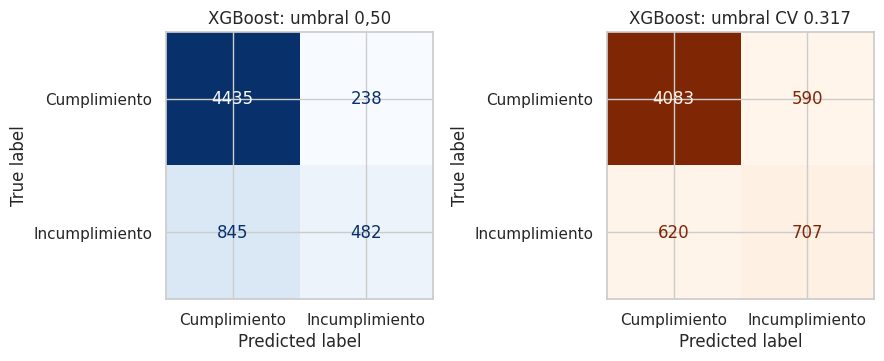

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(9, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_test_xgb_05,
    display_labels=["Cumplimiento", "Incumplimiento"],
    cmap="Blues",
    colorbar=False,
    ax=ejes[0],
)
ejes[0].set_title("XGBoost: umbral 0,50")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_test_xgb_f1,
    display_labels=["Cumplimiento", "Incumplimiento"],
    cmap="Oranges",
    colorbar=False,
    ax=ejes[1],
)
ejes[1].set_title(f"XGBoost: umbral CV {umbral_f1_xgb:.3f}")

plt.tight_layout()
plt.show()

## 7.10 Curvas ROC y precisión-exhaustividad

La curva ROC evaluó la discriminación a través de todos los umbrales. La curva precisión-exhaustividad complementó el análisis al centrarse en la clase incumplida y comparó el resultado con la prevalencia observada en prueba.

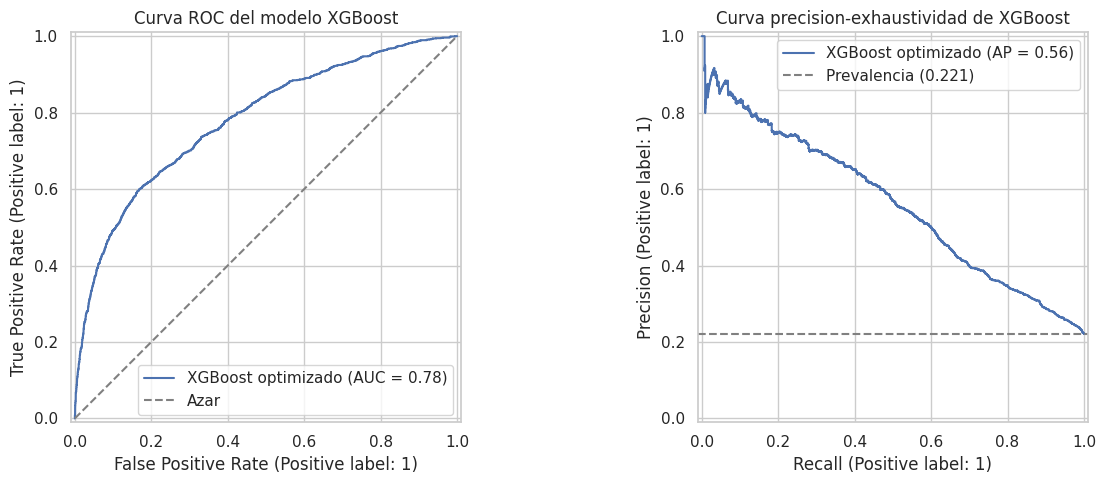

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test,
    probabilidades_test_xgb,
    name="XGBoost optimizado",
    ax=ejes[0],
)
ejes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ejes[0].set_title("Curva ROC del modelo XGBoost")
ejes[0].legend(loc="lower right")

PrecisionRecallDisplay.from_predictions(
    y_test,
    probabilidades_test_xgb,
    name="XGBoost optimizado",
    ax=ejes[1],
)
ejes[1].axhline(
    y=y_test.mean(),
    linestyle="--",
    color="gray",
    label=f"Prevalencia ({y_test.mean():.3f})",
)
ejes[1].set_title("Curva precision-exhaustividad de XGBoost")
ejes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 7.11 Intervalos de confianza mediante bootstrap

Se reutilizó el procedimiento de 500 remuestreos definido en la sección 05. Los intervalos de confianza del 95 % se calcularon con el umbral seleccionado en entrenamiento y bajo el mismo método aplicado a los modelos anteriores.

In [ ]:
ic_xgb = intervalos_bootstrap_clasificacion(
    y_test,
    probabilidades_test_xgb,
    umbral=umbral_f1_xgb,
)

display(ic_xgb.round(4))

,metrica,estimacion,ic_95_inferior,ic_95_superior
0,ROC-AUC,0.7805,0.7665,0.7963
1,PR-AUC,0.5613,0.5349,0.5933
2,Exactitud balanceada,0.7033,0.6900,0.7185
3,Precision,0.5451,0.5174,0.5743
4,Exhaustividad,0.5328,0.5075,0.5631
5,F1,0.5389,0.5159,0.5643


## 7.12 Importancia de las variables

La importancia de XGBoost se obtuvo mediante la ganancia promedio aportada por las divisiones que utilizaron cada característica. Las categorías generadas por la codificación de una variable por categoría se agruparon nuevamente en su variable original.

Esta medida describió la contribución predictiva dentro del modelo, pero no estableció causalidad. La interpretación avanzada mediante valores SHAP se reservó para la sección 09.

,variable_original,importancia
0,RETRASO_MAXIMO_6M,0.2906
1,PAY_0,0.2329
2,MESES_CON_RETRASO,0.1063
3,PAY_2,0.0321
4,EDUCATION,0.0318
5,MARRIAGE,0.0245
6,FACTURACION_PROMEDIO_6M,0.0233
7,MESES_SIN_PAGO,0.0189
8,PAGO_PROMEDIO_6M,0.0186
9,SEX,0.0182


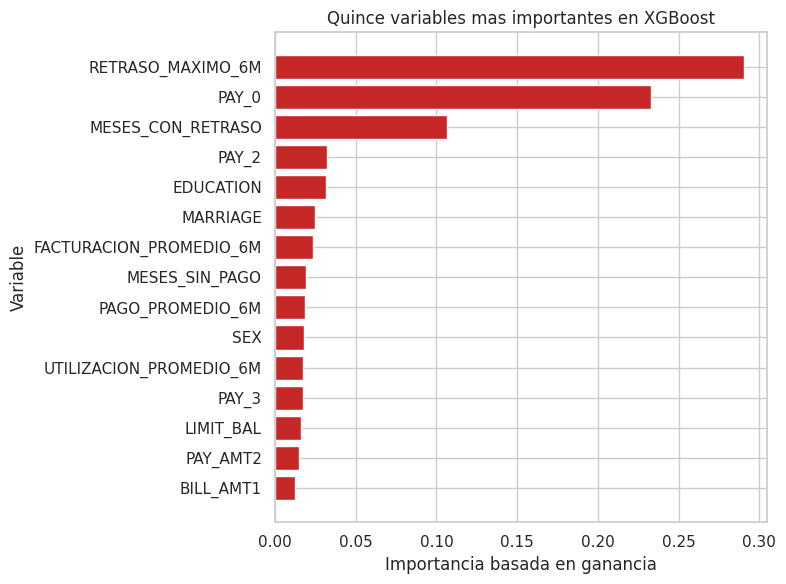

In [ ]:
preprocesamiento_xgb_ajustado = mejor_modelo_xgb.named_steps["preprocesamiento"]
modelo_xgb_ajustado = mejor_modelo_xgb.named_steps["modelo"]

nombres_transformados_xgb = preprocesamiento_xgb_ajustado.get_feature_names_out()

importancia_transformada_xgb = pd.DataFrame({
    "variable_transformada": nombres_transformados_xgb,
    "importancia": modelo_xgb_ajustado.feature_importances_,
}).sort_values("importancia", ascending=False)

importancia_transformada_xgb["variable_original"] = (
    importancia_transformada_xgb["variable_transformada"]
    .map(recuperar_variable_original)
)

importancia_agrupada_xgb = (
    importancia_transformada_xgb
    .groupby("variable_original", as_index=False)["importancia"]
    .sum()
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

display(importancia_agrupada_xgb.head(15).round(4))

top_importancia_xgb = importancia_agrupada_xgb.head(15).sort_values("importancia")

plt.figure(figsize=(8, 6))
plt.barh(
    top_importancia_xgb["variable_original"],
    top_importancia_xgb["importancia"],
    color="#C62828",
)
plt.xlabel("Importancia basada en ganancia")
plt.ylabel("Variable")
plt.title("Quince variables mas importantes en XGBoost")
plt.tight_layout()
plt.show()

## 7.13 Resultado del modelo XGBoost

Se conservaron los hiperparámetros, las métricas de prueba, el umbral, los errores de clasificación, la brecha entre entrenamiento y validación, la importancia de las variables y los tiempos.

Los resultados se añadieron a la tabla comparativa junto con K-NN y Random Forest.


In [ ]:
matriz_xgb_f1 = confusion_matrix(y_test, predicciones_test_xgb_f1)
tn_xgb, fp_xgb, fn_xgb, tp_xgb = matriz_xgb_f1.ravel()

resumen_final_xgb = pd.DataFrame({
    "elemento": [
        "Mejor ROC-AUC de validacion",
        "ROC-AUC de prueba",
        "PR-AUC de prueba",
        "Umbral seleccionado en entrenamiento",
        "Precision de prueba",
        "Exhaustividad de prueba",
        "F1 de prueba",
        "Falsos positivos",
        "Falsos negativos",
        "Brecha ROC-AUC entrenamiento-validacion",
        "Tiempo de busqueda (s)",
        "Tiempo de prediccion (s)",
    ],
    "valor": [
        busqueda_xgb.best_score_,
        metricas_xgb_f1["ROC-AUC"],
        metricas_xgb_f1["PR-AUC"],
        umbral_f1_xgb,
        metricas_xgb_f1["Precision"],
        metricas_xgb_f1["Exhaustividad"],
        metricas_xgb_f1["F1"],
        fp_xgb,
        fn_xgb,
        brecha_mejor_xgb,
        tiempo_busqueda_xgb,
        tiempo_prediccion_xgb,
    ],
})

display(resumen_final_xgb.round(4))

fila_resultados_xgb = pd.DataFrame([{
    "modelo": "XGBoost",
    "roc_auc_cv": busqueda_xgb.best_score_,
    "roc_auc_test": metricas_xgb_f1["ROC-AUC"],
    "pr_auc_test": metricas_xgb_f1["PR-AUC"],
    "precision_test": metricas_xgb_f1["Precision"],
    "recall_test": metricas_xgb_f1["Exhaustividad"],
    "f1_test": metricas_xgb_f1["F1"],
    "accuracy_test": metricas_xgb_f1["Exactitud"],
    "balanced_accuracy_test": metricas_xgb_f1["Exactitud balanceada"],
    "umbral": umbral_f1_xgb,
    "tiempo_busqueda_s": tiempo_busqueda_xgb,
    "tiempo_prediccion_s": tiempo_prediccion_xgb,
}])

resultados_modelos = pd.concat(
    [
        resultados_modelos[
            resultados_modelos["modelo"] != "XGBoost"
        ],
        fila_resultados_xgb,
    ],
    ignore_index=True,
)

display(resultados_modelos.round(4))

print("Seccion 7.13 - Objetos disponibles para las siguientes secciones:")
print("- mejor_modelo_xgb")
print("- busqueda_xgb")
print("- probabilidades_test_xgb")
print("- predicciones_test_xgb_f1")
print("- tabla_metricas_test_xgb")
print("- ic_xgb")
print("- importancia_agrupada_xgb")
print("- resultados_modelos")

,elemento,valor
0,Mejor ROC-AUC de validacion,0.7871
1,ROC-AUC de prueba,0.7805
2,PR-AUC de prueba,0.5613
3,Umbral seleccionado en entrenamiento,0.3173
4,Precision de prueba,0.5451
5,Exhaustividad de prueba,0.5328
6,F1 de prueba,0.5389
7,Falsos positivos,590.0000
8,Falsos negativos,620.0000
9,Brecha ROC-AUC entrenamiento-validacion,0.0336


,modelo,roc_auc_cv,roc_auc_test,pr_auc_test,precision_test,recall_test,f1_test,accuracy_test,balanced_accuracy_test,umbral,tiempo_busqueda_s,tiempo_prediccion_s
0,K-NN,0.7653,0.7562,0.5162,0.5145,0.5350,0.5246,0.7855,0.6958,0.2941,107.5323,0.7880
1,Random Forest,0.7853,0.7756,0.5564,0.5033,0.5757,0.5371,0.7805,0.7072,0.2705,1745.3719,0.1652
2,XGBoost,0.7871,0.7805,0.5613,0.5451,0.5328,0.5389,0.7983,0.7033,0.3173,54.5330,0.0296


Seccion 7.13 - Objetos disponibles para las siguientes secciones:
- mejor_modelo_xgb
- busqueda_xgb
- probabilidades_test_xgb
- predicciones_test_xgb_f1
- tabla_metricas_test_xgb
- ic_xgb
- importancia_agrupada_xgb
- resultados_modelos


# 08_Evaluacion_comparativa

En esta fase se compararon K-NN, Random Forest y XGBoost mediante las mismas observaciones de prueba. Se analizaron la discriminación, las métricas de clasificación, la calibración, los tipos de error y el coste computacional.

Los resultados correspondieron al conjunto UCI *Default of Credit Card Clients* y no se interpretaron como validación directa del sistema financiero ecuatoriano.


## 8.1 Criterios de comparación

La comparación utilizó las probabilidades y predicciones obtenidas sobre los mismos 6.000 registros de prueba. Los hiperparámetros y los umbrales se definieron previamente con el conjunto de entrenamiento.

Se consideraron ROC-AUC, PR-AUC, precisión, exhaustividad, F1, exactitud, exactitud balanceada, puntuación de Brier, falsos positivos, falsos negativos y tiempos de ejecución. Las diferencias entre modelos se estimaron mediante remuestreo pareado (*paired bootstrap*).


In [ ]:
import time
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

try:
    from IPython.display import display
except ImportError:
    def display(objeto):
        print(objeto)

objetos_requeridos_08 = [
    "y_test",
    "resultados_modelos",
    "probabilidades_test_knn",
    "probabilidades_test_rf",
    "probabilidades_test_xgb",
    "predicciones_test_knn_f1",
    "predicciones_test_rf_f1",
    "predicciones_test_xgb_f1",
    "umbral_f1_knn",
    "umbral_f1_rf",
    "umbral_f1_xgb",
    "mejor_modelo_knn",
    "mejor_modelo_rf",
    "mejor_modelo_xgb",
]

faltantes_08 = [
    nombre for nombre in objetos_requeridos_08 if nombre not in globals()
]

if faltantes_08:
    raise NameError(
        "Faltan objetos de las secciones 05–07: "
        + ", ".join(faltantes_08)
        + ". Ejecute el notebook desde el inicio."
    )

print("Seccion 8.1 - Dependencias y objetos de comparacion disponibles.")


Seccion 8.1 - Dependencias y objetos de comparacion disponibles.


## 8.2 Verificación de comparabilidad e integridad

Antes de comparar los modelos se comprobó que las probabilidades y predicciones:

- correspondieran al mismo número y orden de observaciones;
- no contuvieran valores nulos o infinitos;
- permanecieran dentro del intervalo \([0,1]\);
- coincidieran con los umbrales seleccionados mediante validación cruzada.


In [ ]:
modelos_orden = ["K-NN", "Random Forest", "XGBoost"]
y_test_comparacion = np.asarray(y_test, dtype=int)

probabilidades_comparacion = {
    "K-NN": np.asarray(probabilidades_test_knn, dtype=float),
    "Random Forest": np.asarray(probabilidades_test_rf, dtype=float),
    "XGBoost": np.asarray(probabilidades_test_xgb, dtype=float),
}

predicciones_comparacion = {
    "K-NN": np.asarray(predicciones_test_knn_f1, dtype=int),
    "Random Forest": np.asarray(predicciones_test_rf_f1, dtype=int),
    "XGBoost": np.asarray(predicciones_test_xgb_f1, dtype=int),
}

umbrales_comparacion = {
    "K-NN": float(umbral_f1_knn),
    "Random Forest": float(umbral_f1_rf),
    "XGBoost": float(umbral_f1_xgb),
}

filas_integridad = []

for modelo in modelos_orden:
    probabilidades = probabilidades_comparacion[modelo]
    predicciones = predicciones_comparacion[modelo]
    umbral = umbrales_comparacion[modelo]

    assert len(probabilidades) == len(y_test_comparacion)
    assert len(predicciones) == len(y_test_comparacion)
    assert np.isfinite(probabilidades).all()
    assert ((probabilidades >= 0) & (probabilidades <= 1)).all()
    assert set(np.unique(predicciones)).issubset({0, 1})
    assert np.array_equal(
        predicciones,
        (probabilidades >= umbral).astype(int),
    )

    filas_integridad.append({
        "Modelo": modelo,
        "Registros": len(probabilidades),
        "Probabilidad minima": probabilidades.min(),
        "Probabilidad maxima": probabilidades.max(),
        "Valores no finitos": int((~np.isfinite(probabilidades)).sum()),
        "Umbral CV": umbral,
        "Predicciones coherentes": True,
    })

tabla_integridad_08 = pd.DataFrame(filas_integridad)
display(tabla_integridad_08.round(4))

print(
    "Seccion 8.2 - Prevalencia de incumplimiento en prueba: "
    f"{y_test_comparacion.mean():.2%}"
)


,Modelo,Registros,Probabilidad minima,Probabilidad maxima,Valores no finitos,Umbral CV,Predicciones coherentes
0,K-NN,6000,0.0000,0.9020,0,0.2941,True
1,Random Forest,6000,0.0254,0.9694,0,0.2705,True
2,XGBoost,6000,0.0145,0.8959,0,0.3173,True


Seccion 8.2 - Prevalencia de incumplimiento en prueba: 22.12%


## 8.3 Comparación puntual de métricas

Las métricas se recalcularon directamente a partir de las mismas etiquetas, probabilidades y predicciones. Esta comprobación independiente evitó depender únicamente de las tablas acumuladas durante el entrenamiento.


In [ ]:
filas_metricas_08 = []

for modelo in modelos_orden:
    probabilidades = probabilidades_comparacion[modelo]
    predicciones = predicciones_comparacion[modelo]

    filas_metricas_08.append({
        "Modelo": modelo,
        "ROC-AUC": roc_auc_score(y_test_comparacion, probabilidades),
        "PR-AUC": average_precision_score(
            y_test_comparacion, probabilidades
        ),
        "Exactitud": (
            predicciones == y_test_comparacion
        ).mean(),
        "Exactitud balanceada": balanced_accuracy_score(
            y_test_comparacion, predicciones
        ),
        "Precision": precision_score(
            y_test_comparacion, predicciones, zero_division=0
        ),
        "Exhaustividad": recall_score(
            y_test_comparacion, predicciones, zero_division=0
        ),
        "F1": f1_score(
            y_test_comparacion, predicciones, zero_division=0
        ),
        "Brier": brier_score_loss(
            y_test_comparacion, probabilidades
        ),
        "Umbral": umbrales_comparacion[modelo],
    })

tabla_comparacion_modelos = pd.DataFrame(filas_metricas_08)

columnas_contraste = {
    "roc_auc_test": "ROC-AUC",
    "pr_auc_test": "PR-AUC",
    "precision_test": "Precision",
    "recall_test": "Exhaustividad",
    "f1_test": "F1",
    "accuracy_test": "Exactitud",
    "balanced_accuracy_test": "Exactitud balanceada",
    "umbral": "Umbral",
}

tabla_previa_08 = (
    resultados_modelos
    .set_index("modelo")
    .loc[modelos_orden]
)
tabla_recalculada_08 = tabla_comparacion_modelos.set_index("Modelo")

diferencias_verificacion = []
for columna_previa, columna_nueva in columnas_contraste.items():
    diferencia = np.abs(
        tabla_previa_08[columna_previa].to_numpy(dtype=float)
        - tabla_recalculada_08[columna_nueva].to_numpy(dtype=float)
    ).max()
    diferencias_verificacion.append(diferencia)

maxima_diferencia_verificacion = float(
    np.max(diferencias_verificacion)
)
assert maxima_diferencia_verificacion < 1e-10

display(
    tabla_comparacion_modelos
    .set_index("Modelo")
    .round(4)
)
print(
    "Seccion 8.3 - Maxima diferencia frente a los resultados almacenados: "
    f"{maxima_diferencia_verificacion:.2e}"
)


,ROC-AUC,PR-AUC,Exactitud,Exactitud balanceada,Precision,Exhaustividad,F1,Brier,Umbral
Modelo,,,,,,,,,
K-NN,0.7562,0.5162,0.7855,0.6958,0.5145,0.5350,0.5246,0.1398,0.2941
Random Forest,0.7756,0.5564,0.7805,0.7072,0.5033,0.5757,0.5371,0.1354,0.2705
XGBoost,0.7805,0.5613,0.7983,0.7033,0.5451,0.5328,0.5389,0.1345,0.3173


Seccion 8.3 - Maxima diferencia frente a los resultados almacenados: 0.00e+00


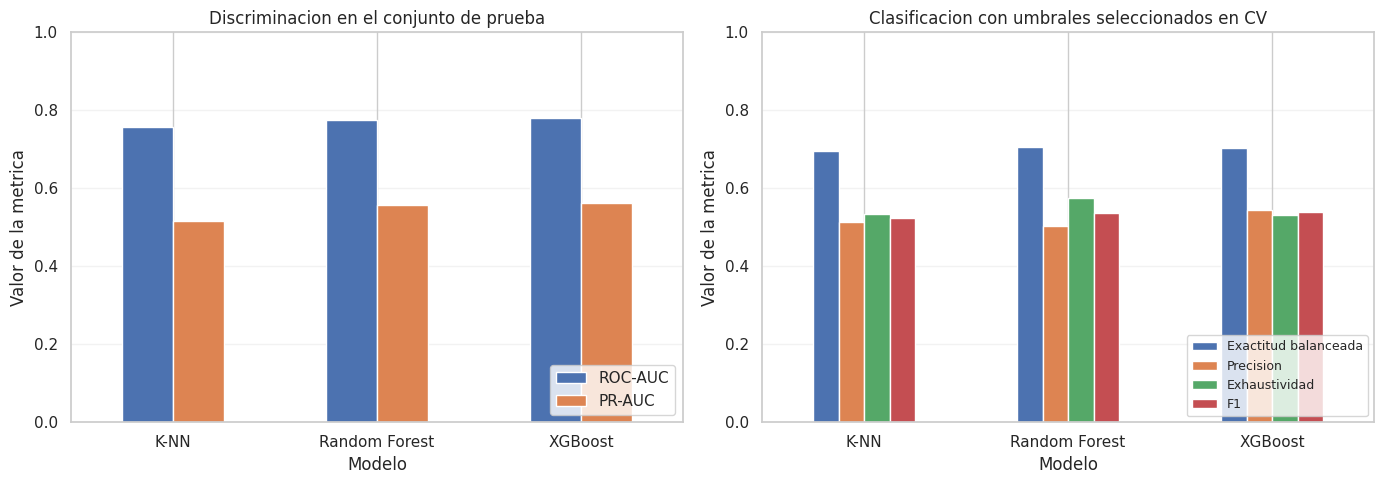

In [ ]:
metricas_discriminacion = ["ROC-AUC", "PR-AUC"]
metricas_clasificacion = [
    "Exactitud balanceada",
    "Precision",
    "Exhaustividad",
    "F1",
]

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

(
    tabla_comparacion_modelos
    .set_index("Modelo")[metricas_discriminacion]
    .plot(kind="bar", ax=ejes[0], rot=0)
)
ejes[0].set_title("Discriminacion en el conjunto de prueba")
ejes[0].set_ylabel("Valor de la metrica")
ejes[0].set_ylim(0, 1)
ejes[0].legend(loc="lower right")

(
    tabla_comparacion_modelos
    .set_index("Modelo")[metricas_clasificacion]
    .plot(kind="bar", ax=ejes[1], rot=0)
)
ejes[1].set_title("Clasificacion con umbrales seleccionados en CV")
ejes[1].set_ylabel("Valor de la metrica")
ejes[1].set_ylim(0, 1)
ejes[1].legend(loc="lower right", fontsize=9)

for eje in ejes:
    eje.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## 8.4 Curvas ROC y precisión-exhaustividad

Las curvas se representaron conjuntamente para mantener una escala idéntica. La línea horizontal de la curva precisión-exhaustividad correspondió a la prevalencia observada en el conjunto de prueba.


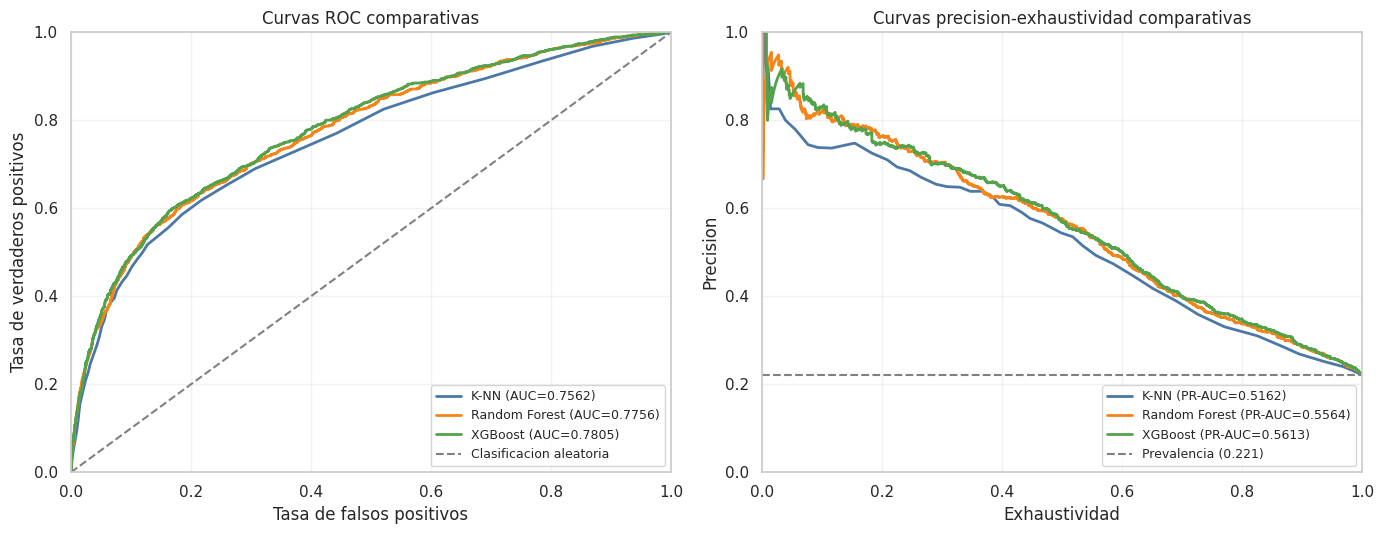

In [ ]:
colores_modelos = {
    "K-NN": "#4C78A8",
    "Random Forest": "#F58518",
    "XGBoost": "#54A24B",
}

fig, ejes = plt.subplots(1, 2, figsize=(14, 5.5))

for modelo in modelos_orden:
    probabilidades = probabilidades_comparacion[modelo]

    tasa_fp, tasa_tp, _ = roc_curve(
        y_test_comparacion, probabilidades
    )
    roc_auc = roc_auc_score(
        y_test_comparacion, probabilidades
    )
    ejes[0].plot(
        tasa_fp,
        tasa_tp,
        color=colores_modelos[modelo],
        linewidth=2,
        label=f"{modelo} (AUC={roc_auc:.4f})",
    )

    precision_curva, recall_curva, _ = precision_recall_curve(
        y_test_comparacion, probabilidades
    )
    pr_auc = average_precision_score(
        y_test_comparacion, probabilidades
    )
    ejes[1].plot(
        recall_curva,
        precision_curva,
        color=colores_modelos[modelo],
        linewidth=2,
        label=f"{modelo} (PR-AUC={pr_auc:.4f})",
    )

ejes[0].plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    label="Clasificacion aleatoria",
)
ejes[0].set(
    title="Curvas ROC comparativas",
    xlabel="Tasa de falsos positivos",
    ylabel="Tasa de verdaderos positivos",
    xlim=(0, 1),
    ylim=(0, 1),
)

prevalencia_test = y_test_comparacion.mean()
ejes[1].axhline(
    prevalencia_test,
    linestyle="--",
    color="gray",
    label=f"Prevalencia ({prevalencia_test:.3f})",
)
ejes[1].set(
    title="Curvas precision-exhaustividad comparativas",
    xlabel="Exhaustividad",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1),
)

for eje in ejes:
    eje.legend(loc="lower right", fontsize=9)
    eje.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 8.5 Matrices de confusión y tipos de error

Las matrices se calcularon con los umbrales seleccionados en las predicciones fuera de muestra del entrenamiento. Se mostraron tanto los conteos como las tasas de falsos positivos y de incumplidos no detectados.


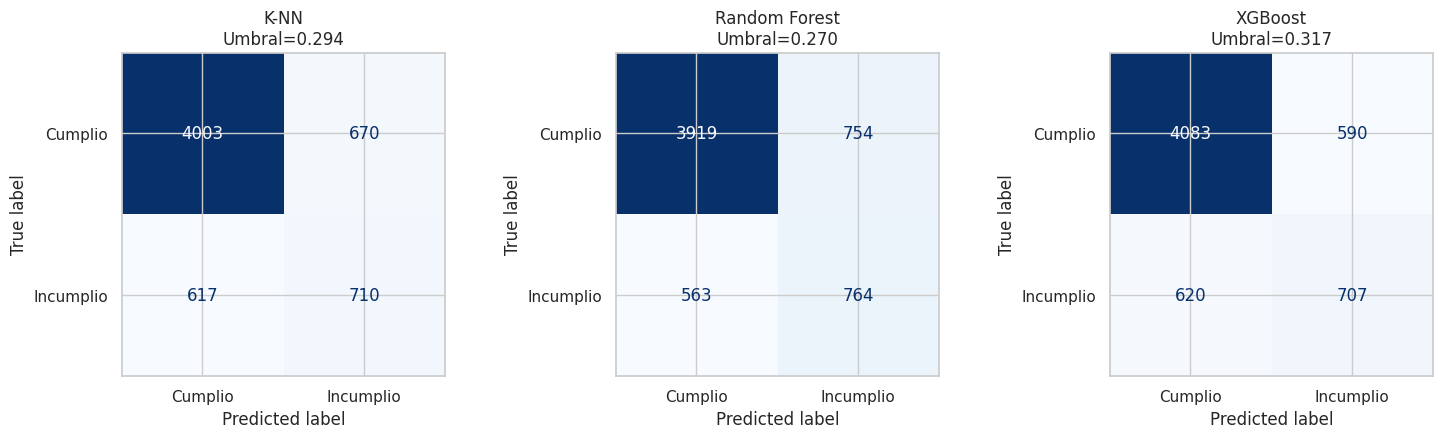

In [ ]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))

for eje, modelo in zip(ejes, modelos_orden):
    ConfusionMatrixDisplay.from_predictions(
        y_test_comparacion,
        predicciones_comparacion[modelo],
        display_labels=["Cumplio", "Incumplio"],
        cmap="Blues",
        colorbar=False,
        ax=eje,
    )
    eje.set_title(
        f"{modelo}\nUmbral={umbrales_comparacion[modelo]:.3f}"
    )

plt.tight_layout()
plt.show()


In [ ]:
filas_errores_08 = []

for modelo in modelos_orden:
    tn, fp, fn, tp = confusion_matrix(
        y_test_comparacion,
        predicciones_comparacion[modelo],
    ).ravel()

    filas_errores_08.append({
        "Modelo": modelo,
        "Verdaderos negativos": tn,
        "Falsos positivos": fp,
        "Falsos negativos": fn,
        "Verdaderos positivos": tp,
        "Tasa de falsos positivos": fp / (fp + tn),
        "Incumplidos no detectados": fn / (fn + tp),
        "Falsos positivos por 1.000": fp / len(y_test_comparacion) * 1000,
        "Falsos negativos por 1.000": fn / len(y_test_comparacion) * 1000,
    })

tabla_errores_modelos = pd.DataFrame(filas_errores_08)
display(tabla_errores_modelos.set_index("Modelo").round(4))


,Verdaderos negativos,Falsos positivos,Falsos negativos,Verdaderos positivos,Tasa de falsos positivos,Incumplidos no detectados,Falsos positivos por 1.000,Falsos negativos por 1.000
Modelo,,,,,,,,
K-NN,4003,670,617,710,0.1434,0.4650,111.6667,102.8333
Random Forest,3919,754,563,764,0.1614,0.4243,125.6667,93.8333
XGBoost,4083,590,620,707,0.1263,0.4672,98.3333,103.3333


## 8.6 Calibración de las probabilidades

La puntuación de Brier midió el error cuadrático medio de las probabilidades; valores menores indicaron mejor calidad probabilística. Las curvas de calibración permitieron comprobar si las probabilidades predichas se aproximaron a las frecuencias observadas.

Este análisis fue complementario: los modelos no fueron calibrados nuevamente para evitar introducir ajustes posteriores sobre el conjunto de prueba.


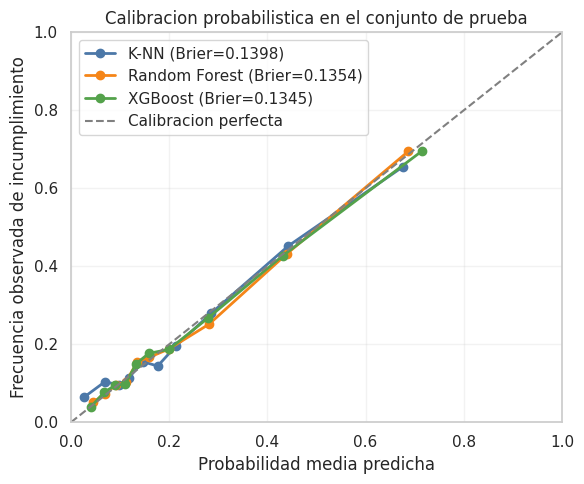

,Brier
Modelo,
XGBoost,0.1345
Random Forest,0.1354
K-NN,0.1398


In [ ]:
plt.figure(figsize=(6, 5))

for modelo in modelos_orden:
    probabilidades = probabilidades_comparacion[modelo]
    fraccion_positivos, probabilidad_media = calibration_curve(
        y_test_comparacion,
        probabilidades,
        n_bins=10,
        strategy="quantile",
    )
    brier = brier_score_loss(
        y_test_comparacion, probabilidades
    )
    plt.plot(
        probabilidad_media,
        fraccion_positivos,
        marker="o",
        linewidth=2,
        color=colores_modelos[modelo],
        label=f"{modelo} (Brier={brier:.4f})",
    )

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    label="Calibracion perfecta",
)
plt.title("Calibracion probabilistica en el conjunto de prueba")
plt.xlabel("Probabilidad media predicha")
plt.ylabel("Frecuencia observada de incumplimiento")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

display(
    tabla_comparacion_modelos[
        ["Modelo", "Brier"]
    ]
    .sort_values("Brier")
    .set_index("Modelo")
    .round(4)
)


## 8.7 Diferencias pareadas mediante bootstrap

Las estimaciones puntuales no fueron suficientes para afirmar superioridad. Por ello se utilizó un *bootstrap* pareado: en cada repetición se seleccionaron los mismos registros para ambos modelos y se calculó la diferencia \(A-B\).

Se consideró evidencia de diferencia cuando el intervalo percentil del 95 % no incluyó el valor cero. Este procedimiento cuantificó la incertidumbre, pero no convirtió los resultados UCI en conclusiones generalizables al contexto ecuatoriano.


In [ ]:
def bootstrap_pareado_diferencias(
    y_real,
    probabilidades_por_modelo,
    predicciones_por_modelo,
    repeticiones=1000,
    semilla=SEMILLA,
):
    y_array = np.asarray(y_real, dtype=int)
    generador = np.random.default_rng(semilla)
    pares = list(combinations(probabilidades_por_modelo.keys(), 2))

    diferencias = {
        (modelo_a, modelo_b, metrica): []
        for modelo_a, modelo_b in pares
        for metrica in [
            "ROC-AUC",
            "PR-AUC",
            "F1",
            "Exactitud balanceada",
        ]
    }

    for _ in range(repeticiones):
        indices = generador.integers(
            0, len(y_array), size=len(y_array)
        )
        y_muestra = y_array[indices]

        if np.unique(y_muestra).size < 2:
            continue

        valores_muestra = {}
        for modelo in probabilidades_por_modelo:
            probabilidades = probabilidades_por_modelo[modelo][indices]
            predicciones = predicciones_por_modelo[modelo][indices]

            valores_muestra[modelo] = {
                "ROC-AUC": roc_auc_score(
                    y_muestra, probabilidades
                ),
                "PR-AUC": average_precision_score(
                    y_muestra, probabilidades
                ),
                "F1": f1_score(
                    y_muestra,
                    predicciones,
                    zero_division=0,
                ),
                "Exactitud balanceada": balanced_accuracy_score(
                    y_muestra, predicciones
                ),
            }

        for modelo_a, modelo_b in pares:
            for metrica in valores_muestra[modelo_a]:
                diferencias[(modelo_a, modelo_b, metrica)].append(
                    valores_muestra[modelo_a][metrica]
                    - valores_muestra[modelo_b][metrica]
                )

    filas = []
    tabla_puntos = tabla_comparacion_modelos.set_index("Modelo")

    for (modelo_a, modelo_b, metrica), valores in diferencias.items():
        distribucion = np.asarray(valores, dtype=float)
        diferencia_puntual = (
            tabla_puntos.loc[modelo_a, metrica]
            - tabla_puntos.loc[modelo_b, metrica]
        )
        limite_inferior, limite_superior = np.quantile(
            distribucion, [0.025, 0.975]
        )

        if limite_inferior > 0:
            evidencia = f"Favorecio a {modelo_a}"
        elif limite_superior < 0:
            evidencia = f"Favorecio a {modelo_b}"
        else:
            evidencia = "Diferencia no concluyente"

        filas.append({
            "Comparacion": f"{modelo_a} - {modelo_b}",
            "Metrica": metrica,
            "Diferencia": diferencia_puntual,
            "IC 95 % inferior": limite_inferior,
            "IC 95 % superior": limite_superior,
            "Probabilidad diferencia > 0": (
                distribucion > 0
            ).mean(),
            "Evidencia": evidencia,
            "Repeticiones validas": len(distribucion),
        })

    return pd.DataFrame(filas)


inicio_bootstrap_08 = time.perf_counter()
tabla_bootstrap_pareado = bootstrap_pareado_diferencias(
    y_test_comparacion,
    probabilidades_comparacion,
    predicciones_comparacion,
    repeticiones=1000,
)
tiempo_bootstrap_08 = time.perf_counter() - inicio_bootstrap_08

display(
    tabla_bootstrap_pareado
    .sort_values(["Metrica", "Comparacion"])
    .reset_index(drop=True)
    .round(4)
)
print(
    f"Seccion 8.7 - Tiempo del bootstrap pareado: {tiempo_bootstrap_08:.2f} segundos"
)


,Comparacion,Metrica,Diferencia,IC 95 % inferior,IC 95 % superior,Probabilidad diferencia > 0,Evidencia,Repeticiones validas
0,K-NN - Random Forest,Exactitud balanceada,-0.0114,-0.0199,-0.0036,0.004,Favorecio a Random Forest,1000
1,K-NN - XGBoost,Exactitud balanceada,-0.0074,-0.0153,0.0002,0.029,Diferencia no concluyente,1000
2,Random Forest - XGBoost,Exactitud balanceada,0.0039,-0.0033,0.0110,0.872,Diferencia no concluyente,1000
3,K-NN - Random Forest,F1,-0.0125,-0.0245,-0.0007,0.018,Favorecio a Random Forest,1000
4,K-NN - XGBoost,F1,-0.0143,-0.0261,-0.0025,0.011,Favorecio a XGBoost,1000
5,Random Forest - XGBoost,F1,-0.0018,-0.0126,0.0090,0.376,Diferencia no concluyente,1000
6,K-NN - Random Forest,PR-AUC,-0.0402,-0.0530,-0.0268,0.000,Favorecio a Random Forest,1000
7,K-NN - XGBoost,PR-AUC,-0.0451,-0.0598,-0.0297,0.000,Favorecio a XGBoost,1000
8,Random Forest - XGBoost,PR-AUC,-0.0049,-0.0143,0.0051,0.144,Diferencia no concluyente,1000
9,K-NN - Random Forest,ROC-AUC,-0.0193,-0.0269,-0.0110,0.000,Favorecio a Random Forest,1000


Seccion 8.7 - Tiempo del bootstrap pareado: 15.92 segundos


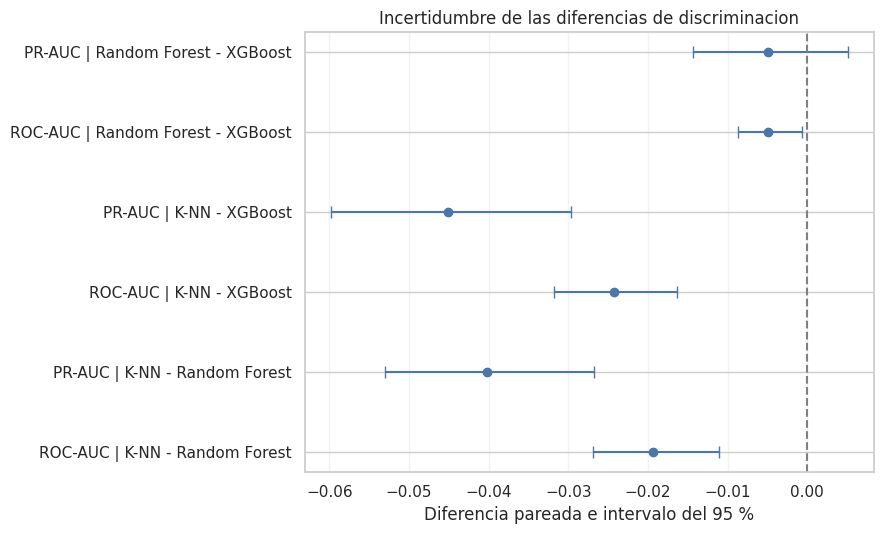

In [ ]:
tabla_intervalos_discriminacion = tabla_bootstrap_pareado[
    tabla_bootstrap_pareado["Metrica"].isin(
        ["ROC-AUC", "PR-AUC"]
    )
].copy()

tabla_intervalos_discriminacion["Etiqueta"] = (
    tabla_intervalos_discriminacion["Metrica"]
    + " | "
    + tabla_intervalos_discriminacion["Comparacion"]
)

posiciones = np.arange(len(tabla_intervalos_discriminacion))
centros = tabla_intervalos_discriminacion["Diferencia"].to_numpy()
errores_inferiores = (
    centros
    - tabla_intervalos_discriminacion["IC 95 % inferior"].to_numpy()
)
errores_superiores = (
    tabla_intervalos_discriminacion["IC 95 % superior"].to_numpy()
    - centros
)

plt.figure(figsize=(9, 5.5))
plt.errorbar(
    centros,
    posiciones,
    xerr=np.vstack([errores_inferiores, errores_superiores]),
    fmt="o",
    color="#4C78A8",
    ecolor="#4C78A8",
    capsize=4,
)
plt.axvline(0, linestyle="--", color="gray")
plt.yticks(
    posiciones,
    tabla_intervalos_discriminacion["Etiqueta"],
)
plt.xlabel("Diferencia pareada e intervalo del 95 %")
plt.title("Incertidumbre de las diferencias de discriminacion")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## 8.8 Generalización y señales de sobreajuste

Se comparó el ROC-AUC medio de validación cruzada con el resultado del conjunto de prueba. Para Random Forest y XGBoost también se incorporó la brecha entre entrenamiento y validación calculada en sus secciones correspondientes.

La diferencia validación-prueba no debía interpretarse por sí sola como sobreajuste; servía como comprobación de estabilidad. La brecha entrenamiento-validación fue el indicador específico disponible para los modelos de árboles.


In [ ]:
brechas_entrenamiento_validacion = {
    "K-NN": np.nan,
    "Random Forest": float(brecha_mejor_rf),
    "XGBoost": float(brecha_mejor_xgb),
}

tabla_generalizacion = (
    resultados_modelos
    .set_index("modelo")
    .loc[modelos_orden, ["roc_auc_cv", "roc_auc_test"]]
    .reset_index()
    .rename(columns={
        "modelo": "Modelo",
        "roc_auc_cv": "ROC-AUC validacion",
        "roc_auc_test": "ROC-AUC prueba",
    })
)

tabla_generalizacion["Validacion - prueba"] = (
    tabla_generalizacion["ROC-AUC validacion"]
    - tabla_generalizacion["ROC-AUC prueba"]
)
tabla_generalizacion["Brecha entrenamiento - validacion"] = (
    tabla_generalizacion["Modelo"]
    .map(brechas_entrenamiento_validacion)
)
tabla_generalizacion["Señal de sobreajuste"] = (
    tabla_generalizacion["Brecha entrenamiento - validacion"]
    .apply(
        lambda valor:
            "No evaluada con este indicador"
            if pd.isna(valor)
            else (
                "Baja (<0,05)"
                if valor < 0.05
                else "Requiere cautela (≥0,05)"
            )
    )
)

display(tabla_generalizacion.set_index("Modelo").round(4))


,ROC-AUC validacion,ROC-AUC prueba,Validacion - prueba,Brecha entrenamiento - validacion,Señal de sobreajuste
Modelo,,,,,
K-NN,0.7653,0.7562,0.0090,NaN,No evaluada con este indicador
Random Forest,0.7853,0.7756,0.0098,0.1227,"Requiere cautela (≥0,05)"
XGBoost,0.7871,0.7805,0.0065,0.0336,"Baja (<0,05)"


## 8.9 Coste computacional

Los tiempos se compararon como mediciones del entorno de ejecución utilizado, no como propiedades universales de los algoritmos. Podían variar según CPU, memoria, paralelización y versión de las bibliotecas.


,Busqueda (s),Prediccion (s),Predicciones OOF (s),Busqueda (min),Prediccion por registro (ms)
Modelo,,,,,
K-NN,107.5323,0.7880,2.3281,1.7922,0.1313
Random Forest,1745.3719,0.1652,48.6932,29.0895,0.0275
XGBoost,54.5330,0.0296,3.9727,0.9089,0.0049


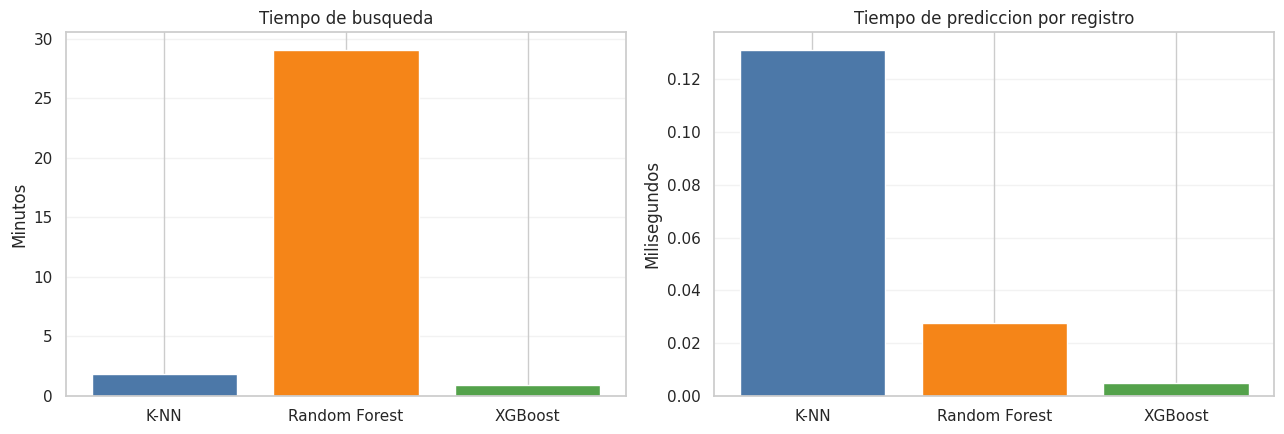

In [ ]:
tiempos_oof_08 = {
    "K-NN": float(tiempo_oof_knn),
    "Random Forest": float(tiempo_oof_rf),
    "XGBoost": float(tiempo_oof_xgb),
}

tabla_tiempos_modelos = (
    resultados_modelos
    .set_index("modelo")
    .loc[
        modelos_orden,
        ["tiempo_busqueda_s", "tiempo_prediccion_s"],
    ]
    .reset_index()
    .rename(columns={
        "modelo": "Modelo",
        "tiempo_busqueda_s": "Busqueda (s)",
        "tiempo_prediccion_s": "Prediccion (s)",
    })
)

tabla_tiempos_modelos["Predicciones OOF (s)"] = (
    tabla_tiempos_modelos["Modelo"].map(tiempos_oof_08)
)
tabla_tiempos_modelos["Busqueda (min)"] = (
    tabla_tiempos_modelos["Busqueda (s)"] / 60
)
tabla_tiempos_modelos["Prediccion por registro (ms)"] = (
    tabla_tiempos_modelos["Prediccion (s)"]
    / len(y_test_comparacion)
    * 1000
)

display(tabla_tiempos_modelos.set_index("Modelo").round(4))

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

ejes[0].bar(
    tabla_tiempos_modelos["Modelo"],
    tabla_tiempos_modelos["Busqueda (min)"],
    color=[colores_modelos[m] for m in modelos_orden],
)
ejes[0].set_title("Tiempo de busqueda")
ejes[0].set_ylabel("Minutos")
ejes[0].grid(axis="y", alpha=0.25)

ejes[1].bar(
    tabla_tiempos_modelos["Modelo"],
    tabla_tiempos_modelos["Prediccion por registro (ms)"],
    color=[colores_modelos[m] for m in modelos_orden],
)
ejes[1].set_title("Tiempo de prediccion por registro")
ejes[1].set_ylabel("Milisegundos")
ejes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## 8.10 Selección del modelo

El modelo final se seleccionó mediante el ROC-AUC obtenido en validación cruzada con los datos de entrenamiento. Los resultados de prueba se utilizaron para estimar su rendimiento y comparar de forma descriptiva los tres algoritmos.

También se identificó el líder de cada criterio. La elección operativa podría variar si una institución priorizara la exhaustividad, el equilibrio F1, la calibración o un coste específico de los errores.


In [ ]:
tabla_indices_08 = tabla_comparacion_modelos.set_index("Modelo")

lideres_criterios = {
    "ROC-AUC": tabla_indices_08["ROC-AUC"].idxmax(),
    "PR-AUC": tabla_indices_08["PR-AUC"].idxmax(),
    "Precision": tabla_indices_08["Precision"].idxmax(),
    "Exhaustividad": tabla_indices_08["Exhaustividad"].idxmax(),
    "F1": tabla_indices_08["F1"].idxmax(),
    "Exactitud balanceada": (
        tabla_indices_08["Exactitud balanceada"].idxmax()
    ),
    "Brier (menor es mejor)": tabla_indices_08["Brier"].idxmin(),
    "Menor tiempo de prediccion": (
        tabla_tiempos_modelos
        .set_index("Modelo")["Prediccion por registro (ms)"]
        .idxmin()
    ),
}

tabla_lideres_criterios = pd.DataFrame(
    list(lideres_criterios.items()),
    columns=["Criterio", "Modelo lider"],
)
display(tabla_lideres_criterios)

modelo_seleccionado = (
    resultados_modelos
    .set_index("modelo")["roc_auc_cv"]
    .idxmax()
)
modelo_lider_roc_auc_prueba = lideres_criterios["ROC-AUC"]
modelo_prioridad_deteccion = lideres_criterios["Exhaustividad"]

print(
    "Seccion 8.10 - Modelo seleccionado por ROC-AUC de validacion cruzada: "
    f"{modelo_seleccionado}."
)
print(
    "Modelo con mayor deteccion de incumplidos: "
    f"{modelo_prioridad_deteccion}."
)


,Criterio,Modelo lider
0,ROC-AUC,XGBoost
1,PR-AUC,XGBoost
2,Precision,XGBoost
3,Exhaustividad,Random Forest
4,F1,XGBoost
5,Exactitud balanceada,Random Forest
6,Brier (menor es mejor),XGBoost
7,Menor tiempo de prediccion,XGBoost


Seccion 8.10 - Modelo seleccionado por ROC-AUC de validacion cruzada: XGBoost.
Modelo con mayor deteccion de incumplidos: Random Forest.


## 8.11 Alcance y validez externa

La estructura comparativa fue válida para evaluar los modelos con el conjunto UCI seleccionado como fuente definitiva del estudio. Los resultados describieron la población y el periodo representados en dicha base pública.

La metodología podría replicarse posteriormente con datos de una institución ecuatoriana, pero ello constituiría una validación externa independiente y exigiría repetir la limpieza, la ingeniería de características, la optimización, el entrenamiento y las estimaciones. Por tanto, el estudio no afirmó que las métricas obtenidas representaran directamente al sistema financiero ecuatoriano.


## 8.12 Resultado de la comparación

La síntesis reunió el modelo seleccionado mediante validación cruzada, el orden observado en prueba, las diferencias pareadas y el algoritmo con mayor exhaustividad.

La conclusión se limitó al conjunto UCI y no se extendió de forma directa a la población ecuatoriana.


In [ ]:
ranking_roc_08 = (
    tabla_comparacion_modelos
    .sort_values("ROC-AUC", ascending=False)
    ["Modelo"]
    .tolist()
)
lider_roc_08, segundo_roc_08 = ranking_roc_08[:2]

def recuperar_intervalo_pareado(
    tabla,
    modelo_a,
    modelo_b,
    metrica,
):
    comparacion_directa = f"{modelo_a} - {modelo_b}"
    comparacion_inversa = f"{modelo_b} - {modelo_a}"

    fila_directa = tabla[
        (tabla["Comparacion"] == comparacion_directa)
        & (tabla["Metrica"] == metrica)
    ]
    if not fila_directa.empty:
        fila = fila_directa.iloc[0].copy()
        return {
            "diferencia": float(fila["Diferencia"]),
            "inferior": float(fila["IC 95 % inferior"]),
            "superior": float(fila["IC 95 % superior"]),
            "evidencia": fila["Evidencia"],
        }

    fila_inversa = tabla[
        (tabla["Comparacion"] == comparacion_inversa)
        & (tabla["Metrica"] == metrica)
    ]
    if fila_inversa.empty:
        raise KeyError("No se encontro la comparacion solicitada.")

    fila = fila_inversa.iloc[0].copy()
    diferencia = -float(fila["Diferencia"])
    inferior = -float(fila["IC 95 % superior"])
    superior = -float(fila["IC 95 % inferior"])

    if inferior > 0:
        evidencia = f"Favorecio a {modelo_a}"
    elif superior < 0:
        evidencia = f"Favorecio a {modelo_b}"
    else:
        evidencia = "Diferencia no concluyente"

    return {
        "diferencia": diferencia,
        "inferior": inferior,
        "superior": superior,
        "evidencia": evidencia,
    }


intervalo_lider_roc = recuperar_intervalo_pareado(
    tabla_bootstrap_pareado,
    lider_roc_08,
    segundo_roc_08,
    "ROC-AUC",
)

resultado_comparativo_uci = {
    "dataset": "UCI Default of Credit Card Clients",
    "estado": "Seleccion final dentro del alcance del conjunto UCI",
    "modelo_seleccionado_cv": modelo_seleccionado,
    "modelo_candidato_roc_auc": lider_roc_08,
    "segundo_modelo_roc_auc": segundo_roc_08,
    "diferencia_roc_auc": intervalo_lider_roc["diferencia"],
    "ic_95_diferencia_roc_auc": (
        intervalo_lider_roc["inferior"],
        intervalo_lider_roc["superior"],
    ),
    "evidencia_diferencia_roc_auc": intervalo_lider_roc["evidencia"],
    "modelo_mayor_exhaustividad": modelo_prioridad_deteccion,
}

tabla_sintesis_08 = pd.DataFrame({
    "Elemento": [
        "Conjunto evaluado",
        "Estado del resultado",
        "Modelo seleccionado por ROC-AUC de validacion",
        "Modelo con mayor ROC-AUC de prueba",
        "Segundo modelo por ROC-AUC",
        "Diferencia ROC-AUC",
        "IC 95 % de la diferencia",
        "Evidencia pareada",
        "Mayor exhaustividad",
    ],
    "Resultado": [
        resultado_comparativo_uci["dataset"],
        resultado_comparativo_uci["estado"],
        modelo_seleccionado,
        lider_roc_08,
        segundo_roc_08,
        f"{intervalo_lider_roc['diferencia']:.4f}",
        (
            f"[{intervalo_lider_roc['inferior']:.4f}, "
            f"{intervalo_lider_roc['superior']:.4f}]"
        ),
        intervalo_lider_roc["evidencia"],
        modelo_prioridad_deteccion,
    ],
})
display(tabla_sintesis_08)

modelos_ajustados = {
    "K-NN": mejor_modelo_knn,
    "Random Forest": mejor_modelo_rf,
    "XGBoost": mejor_modelo_xgb,
}
modelo_seleccionado_objeto = modelos_ajustados[
    modelo_seleccionado
]

busquedas_modelos = {
    "K-NN": busqueda_knn,
    "Random Forest": busqueda_rf,
    "XGBoost": busqueda_xgb,
}
busqueda_modelo_seleccionado = busquedas_modelos[
    modelo_seleccionado
]

print("Seccion 8.12 - Objetos disponibles para la seccion 09:")
print("- tabla_comparacion_modelos")
print("- tabla_errores_modelos")
print("- tabla_bootstrap_pareado")
print("- tabla_generalizacion")
print("- tabla_tiempos_modelos")
print("- resultado_comparativo_uci")
print("- modelo_seleccionado")
print("- modelo_seleccionado_objeto")


,Elemento,Resultado
0,Conjunto evaluado,UCI Default of Credit Card Clients
1,Estado del resultado,Seleccion final dentro del alcance del conjunt...
2,Modelo seleccionado por ROC-AUC de validacion,XGBoost
3,Modelo con mayor ROC-AUC de prueba,XGBoost
4,Segundo modelo por ROC-AUC,Random Forest
5,Diferencia ROC-AUC,0.0050
6,IC 95 % de la diferencia,"[0.0006, 0.0088]"
7,Evidencia pareada,Favorecio a XGBoost
8,Mayor exhaustividad,Random Forest


Seccion 8.12 - Objetos disponibles para la seccion 09:
- tabla_comparacion_modelos
- tabla_errores_modelos
- tabla_bootstrap_pareado
- tabla_generalizacion
- tabla_tiempos_modelos
- resultado_comparativo_uci
- modelo_seleccionado
- modelo_seleccionado_objeto


# 09_Interpretacion_de_resultados

En esta fase se interpretó de forma global y local el modelo seleccionado mediante valores SHAP (*SHapley Additive exPlanations*). También se revisó la estabilidad de las importancias y el comportamiento descriptivo por subgrupos.

Las explicaciones describieron el funcionamiento del modelo en el conjunto UCI. No demostraron relaciones causales ni constituyeron evidencia empírica sobre clientes ecuatorianos.


## 9.1 Alcance y supuestos

El modelo con mayor ROC-AUC de validación cruzada fue seleccionado e interpretado sin modificar su entrenamiento. Se utilizó una muestra estratificada de 2.000 registros de prueba para limitar el coste computacional.

Los valores SHAP positivos desplazaron la salida hacia el incumplimiento y los negativos hacia el cumplimiento. Las categorías codificadas se reagruparon en su variable original. La importancia predictiva se diferenció de la asociación estadística y de la causalidad.


## 9.2 Dependencias y recuperación del modelo

Se utilizó `TreeExplainer`, que aprovechó la estructura de árboles de XGBoost. Con la salida predeterminada del clasificador binario, las contribuciones se expresaron en el margen del modelo o *log-odds*. La suma del valor base y las contribuciones se transformó mediante la función logística para comprobar su correspondencia con la probabilidad predicha.

Si el entorno no dispone de SHAP, deberá ejecutarse `%pip install shap`, reiniciarse la sesión y volver a ejecutarse el notebook.

In [ ]:
from scipy.special import expit
from scipy.stats import spearmanr

try:
    import shap
except ImportError as error:
    raise ImportError(
        "SHAP no esta instalado. Ejecute `%pip install shap`, "
        "reinicie la sesion y vuelva a ejecutar el notebook."
    ) from error

assert modelo_seleccionado == "XGBoost", (
    "La seccion 09 fue preparada para interpretar el candidato XGBoost."
)

pipeline_interpretado_09 = modelo_seleccionado_objeto
preprocesador_interpretado_09 = (
    pipeline_interpretado_09.named_steps["preprocesamiento"]
)
modelo_interpretado_09 = pipeline_interpretado_09.named_steps["modelo"]

print(f"Seccion 9.2 - Modelo interpretado: {modelo_seleccionado}")
print(f"SHAP: {shap.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(
    "Estado del resultado: "
    f"{resultado_comparativo_uci['estado']}"
)

Seccion 9.2 - Modelo interpretado: XGBoost
SHAP: 0.52.0
XGBoost: 3.4.1
Estado del resultado: Seleccion final dentro del alcance del conjunto UCI


## 9.3 Preparación de la muestra explicativa

La muestra mantuvo la proporción de incumplimiento del conjunto de prueba. El preprocesador ya ajustado transformó las variables sin aprender nuevamente parámetros. Se conservaron los nombres de las 35 características resultantes para vincular cada contribución con su variable de origen.

In [ ]:
nombres_transformados_09 = (
    preprocesador_interpretado_09.get_feature_names_out()
)

X_test_transformado_09 = pd.DataFrame(
    preprocesador_interpretado_09.transform(X_test),
    columns=nombres_transformados_09,
).reset_index(drop=True)

y_test_09 = np.asarray(y_test, dtype=int)
probabilidades_test_09 = np.asarray(
    probabilidades_test_xgb,
    dtype=float,
)
predicciones_test_09 = np.asarray(
    predicciones_test_xgb_f1,
    dtype=int,
)

tamano_muestra_shap = min(2000, len(X_test_transformado_09))
posiciones_prueba = np.arange(len(X_test_transformado_09))

if tamano_muestra_shap < len(X_test_transformado_09):
    posiciones_muestra_shap, _ = train_test_split(
        posiciones_prueba,
        train_size=tamano_muestra_shap,
        stratify=y_test_09,
        random_state=SEMILLA,
    )
    posiciones_muestra_shap = np.sort(posiciones_muestra_shap)
else:
    posiciones_muestra_shap = posiciones_prueba

X_muestra_shap_09 = (
    X_test_transformado_09
    .iloc[posiciones_muestra_shap]
    .reset_index(drop=True)
)
X_muestra_original_09 = (
    X_test
    .iloc[posiciones_muestra_shap]
    .reset_index(drop=True)
)
y_muestra_shap_09 = y_test_09[posiciones_muestra_shap]
probabilidades_muestra_09 = (
    probabilidades_test_09[posiciones_muestra_shap]
)
predicciones_muestra_09 = (
    predicciones_test_09[posiciones_muestra_shap]
)

tabla_muestra_shap_09 = pd.DataFrame({
    "Conjunto": ["Prueba completa", "Muestra SHAP"],
    "Registros": [len(y_test_09), len(y_muestra_shap_09)],
    "Incumplidos": [int(y_test_09.sum()), int(y_muestra_shap_09.sum())],
    "Tasa de incumplimiento": [
        y_test_09.mean(),
        y_muestra_shap_09.mean(),
    ],
})

display(tabla_muestra_shap_09.round(4))

assert X_muestra_shap_09.shape[1] == len(nombres_transformados_09)
assert np.isfinite(X_muestra_shap_09.to_numpy()).all()
assert abs(y_muestra_shap_09.mean() - y_test_09.mean()) < 0.01
print("Seccion 9.3 - Muestra explicativa estratificada y validada.")

,Conjunto,Registros,Incumplidos,Tasa de incumplimiento
0,Prueba completa,6000,1327,0.2212
1,Muestra SHAP,2000,442,0.2210


Seccion 9.3 - Muestra explicativa estratificada y validada.


## 9.4 Cálculo y validación de los valores SHAP

Se calcularon las contribuciones para la clase de incumplimiento. Como control de integridad, la salida reconstruida a partir del valor base y de la suma de contribuciones se comparó con la probabilidad generada directamente por XGBoost. Esta comprobación permitió detectar incompatibilidades de forma o de escala entre versiones.

In [ ]:
inicio_shap_09 = time.perf_counter()

explicador_shap_09 = shap.TreeExplainer(modelo_interpretado_09)
explicacion_shap_cruda_09 = explicador_shap_09(
    X_muestra_shap_09,
    check_additivity=False,
)

tiempo_shap_09 = time.perf_counter() - inicio_shap_09

valores_shap_09 = np.asarray(
    explicacion_shap_cruda_09.values,
    dtype=float,
)

if valores_shap_09.ndim == 3:
    if valores_shap_09.shape[-1] == 2:
        valores_shap_09 = valores_shap_09[:, :, 1]
    elif valores_shap_09.shape[0] == 2:
        valores_shap_09 = valores_shap_09[1]
    else:
        raise ValueError(
            "No fue posible identificar la salida positiva en SHAP."
        )

valores_base_09 = np.asarray(
    explicacion_shap_cruda_09.base_values,
    dtype=float,
)

if valores_base_09.ndim == 0:
    valores_base_09 = np.repeat(
        float(valores_base_09),
        len(X_muestra_shap_09),
    )
elif valores_base_09.ndim == 1:
    if valores_base_09.size == 2:
        valores_base_09 = np.repeat(
            float(valores_base_09[1]),
            len(X_muestra_shap_09),
        )
    elif valores_base_09.size != len(X_muestra_shap_09):
        raise ValueError("Forma no reconocida para los valores base SHAP.")
elif valores_base_09.ndim == 2 and valores_base_09.shape[1] == 2:
    valores_base_09 = valores_base_09[:, 1]
else:
    valores_base_09 = valores_base_09.reshape(-1)

assert valores_shap_09.shape == X_muestra_shap_09.shape
assert valores_base_09.shape[0] == len(X_muestra_shap_09)

salida_aditiva_09 = (
    valores_base_09 + valores_shap_09.sum(axis=1)
)
probabilidades_directas_09 = (
    modelo_interpretado_09
    .predict_proba(X_muestra_shap_09)[:, 1]
)

error_log_odds_09 = np.max(np.abs(
    expit(salida_aditiva_09) - probabilidades_directas_09
))
error_probabilidad_09 = np.max(np.abs(
    salida_aditiva_09 - probabilidades_directas_09
))

if error_log_odds_09 <= error_probabilidad_09:
    escala_shap_09 = "log-odds"
    probabilidades_reconstruidas_09 = expit(salida_aditiva_09)
    error_maximo_shap_09 = error_log_odds_09
else:
    escala_shap_09 = "probabilidad"
    probabilidades_reconstruidas_09 = salida_aditiva_09
    error_maximo_shap_09 = error_probabilidad_09

explicacion_shap_09 = shap.Explanation(
    values=valores_shap_09,
    base_values=valores_base_09,
    data=X_muestra_shap_09.to_numpy(),
    feature_names=list(nombres_transformados_09),
)

tabla_validacion_shap_09 = pd.DataFrame({
    "Indicador": [
        "Registros explicados",
        "Caracteristicas transformadas",
        "Escala identificada",
        "Error maximo de reconstruccion",
        "Tiempo de calculo (s)",
    ],
    "Resultado": [
        len(X_muestra_shap_09),
        X_muestra_shap_09.shape[1],
        escala_shap_09,
        error_maximo_shap_09,
        tiempo_shap_09,
    ],
})

display(tabla_validacion_shap_09)
assert error_maximo_shap_09 < 1e-3
print("Seccion 9.4 - La propiedad aditiva de las explicaciones fue validada.")

,Indicador,Resultado
0,Registros explicados,2000
1,Caracteristicas transformadas,35
2,Escala identificada,log-odds
3,Error maximo de reconstruccion,0.0
4,Tiempo de calculo (s),0.421301


Seccion 9.4 - La propiedad aditiva de las explicaciones fue validada.


## 9.5 Importancia global mediante SHAP

La importancia global se estimó como la media del valor SHAP absoluto. Para las variables nominales, las contribuciones de sus categorías codificadas se sumaron por registro antes de calcular la media absoluta. De este modo, `SEX`, `EDUCATION` y `MARRIAGE` se interpretaron como variables originales y no como columnas aisladas.

,Variable,Media SHAP absoluta,Contribucion media firmada
0,PAY_0,0.36130,-0.09890
1,RETRASO_MAXIMO_6M,0.31463,-0.01941
2,UTILIZACION_PROMEDIO_6M,0.16316,-0.01639
3,MESES_CON_RETRASO,0.13569,-0.03295
4,LIMIT_BAL,0.13466,-0.01155
5,BILL_AMT1,0.11107,-0.01045
6,PAY_AMT2,0.08232,-0.01860
7,PAY_AMT1,0.07913,-0.02008
8,PAGO_PROMEDIO_6M,0.07500,-0.00706
9,PAY_AMT3,0.05310,-0.00410


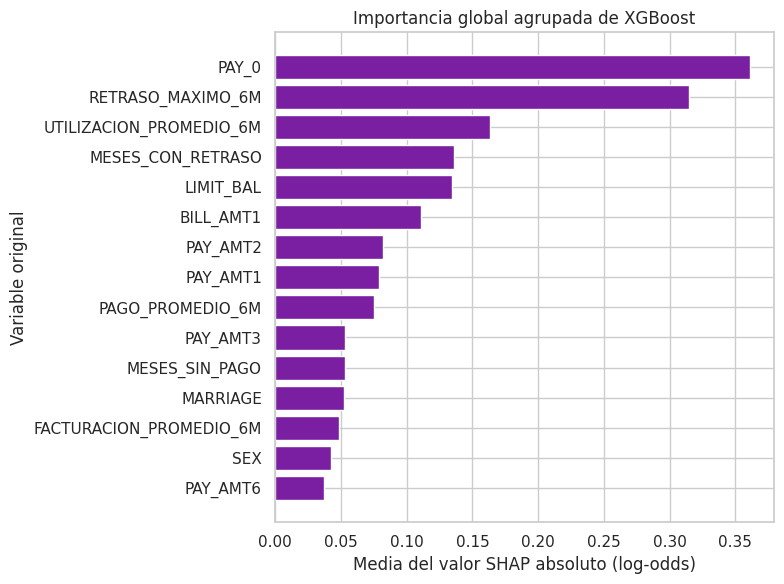

In [ ]:
variables_originales_por_columna_09 = [
    recuperar_variable_original(nombre)
    for nombre in nombres_transformados_09
]

orden_variables_originales_09 = list(X_test.columns)
columnas_por_variable_09 = {
    variable: [
        indice
        for indice, origen in enumerate(
            variables_originales_por_columna_09
        )
        if origen == variable
    ]
    for variable in orden_variables_originales_09
}

contribuciones_agrupadas_09 = pd.DataFrame({
    variable: valores_shap_09[:, indices].sum(axis=1)
    for variable, indices in columnas_por_variable_09.items()
})

importancia_shap_agrupada_09 = pd.DataFrame({
    "Variable": contribuciones_agrupadas_09.columns,
    "Media SHAP absoluta": (
        contribuciones_agrupadas_09.abs().mean(axis=0).values
    ),
    "Contribucion media firmada": (
        contribuciones_agrupadas_09.mean(axis=0).values
    ),
}).sort_values(
    "Media SHAP absoluta",
    ascending=False,
).reset_index(drop=True)

display(importancia_shap_agrupada_09.head(15).round(5))

top_shap_agrupada_09 = (
    importancia_shap_agrupada_09
    .head(15)
    .sort_values("Media SHAP absoluta")
)

plt.figure(figsize=(8, 6))
plt.barh(
    top_shap_agrupada_09["Variable"],
    top_shap_agrupada_09["Media SHAP absoluta"],
    color="#7B1FA2",
)
plt.xlabel(f"Media del valor SHAP absoluto ({escala_shap_09})")
plt.ylabel("Variable original")
plt.title("Importancia global agrupada de XGBoost")
plt.tight_layout()
plt.show()

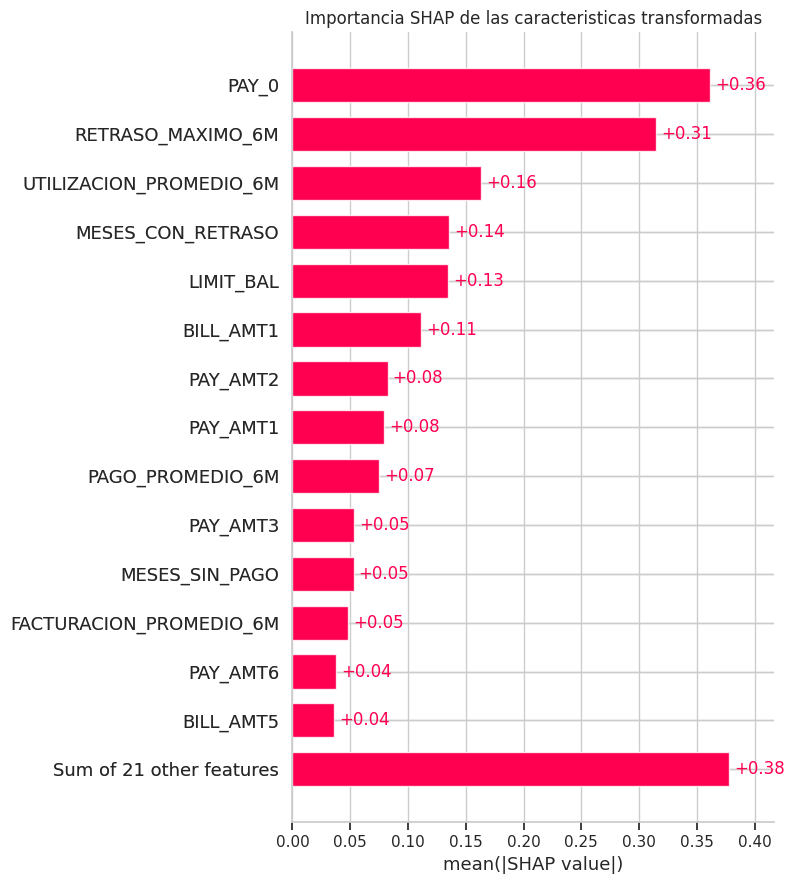

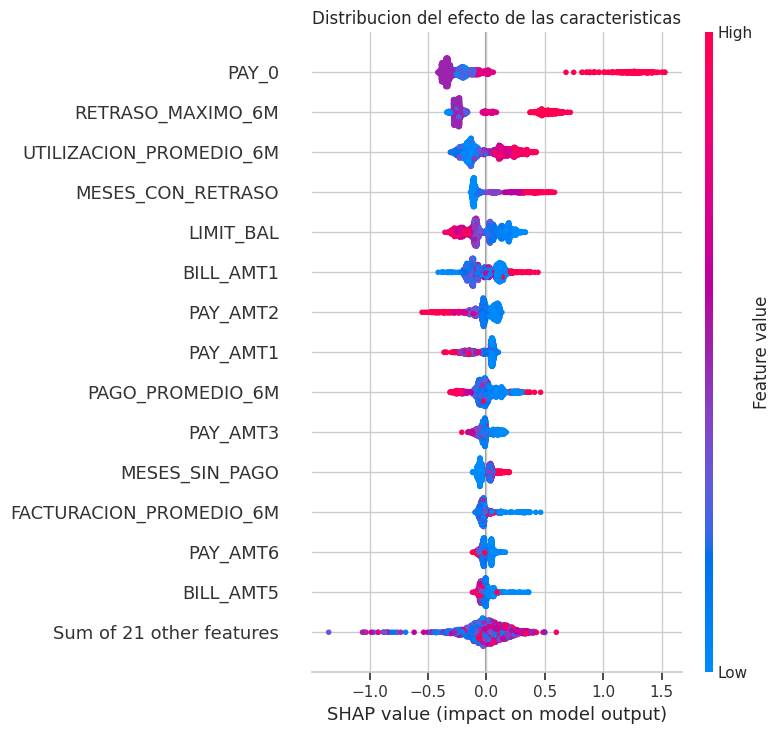

In [ ]:
shap.plots.bar(
    explicacion_shap_09,
    max_display=15,
    show=False,
)
plt.title("Importancia SHAP de las caracteristicas transformadas")
plt.tight_layout()
plt.show()

shap.plots.beeswarm(
    explicacion_shap_09,
    max_display=15,
    show=False,
)
plt.title("Distribucion del efecto de las caracteristicas")
plt.tight_layout()
plt.show()

## 9.6 Dirección de las contribuciones principales

La magnitud absoluta indicó cuánto influyó una variable, pero no hacia qué clase desplazó la predicción. Para las principales variables numéricas u ordinales se comparó su valor observado con su contribución SHAP agrupada.

Una contribución superior a cero desplazó la salida hacia el incumplimiento; una contribución inferior a cero la desplazó hacia el cumplimiento. La correlación de Spearman se utilizó únicamente como resumen descriptivo de una relación potencialmente no lineal.

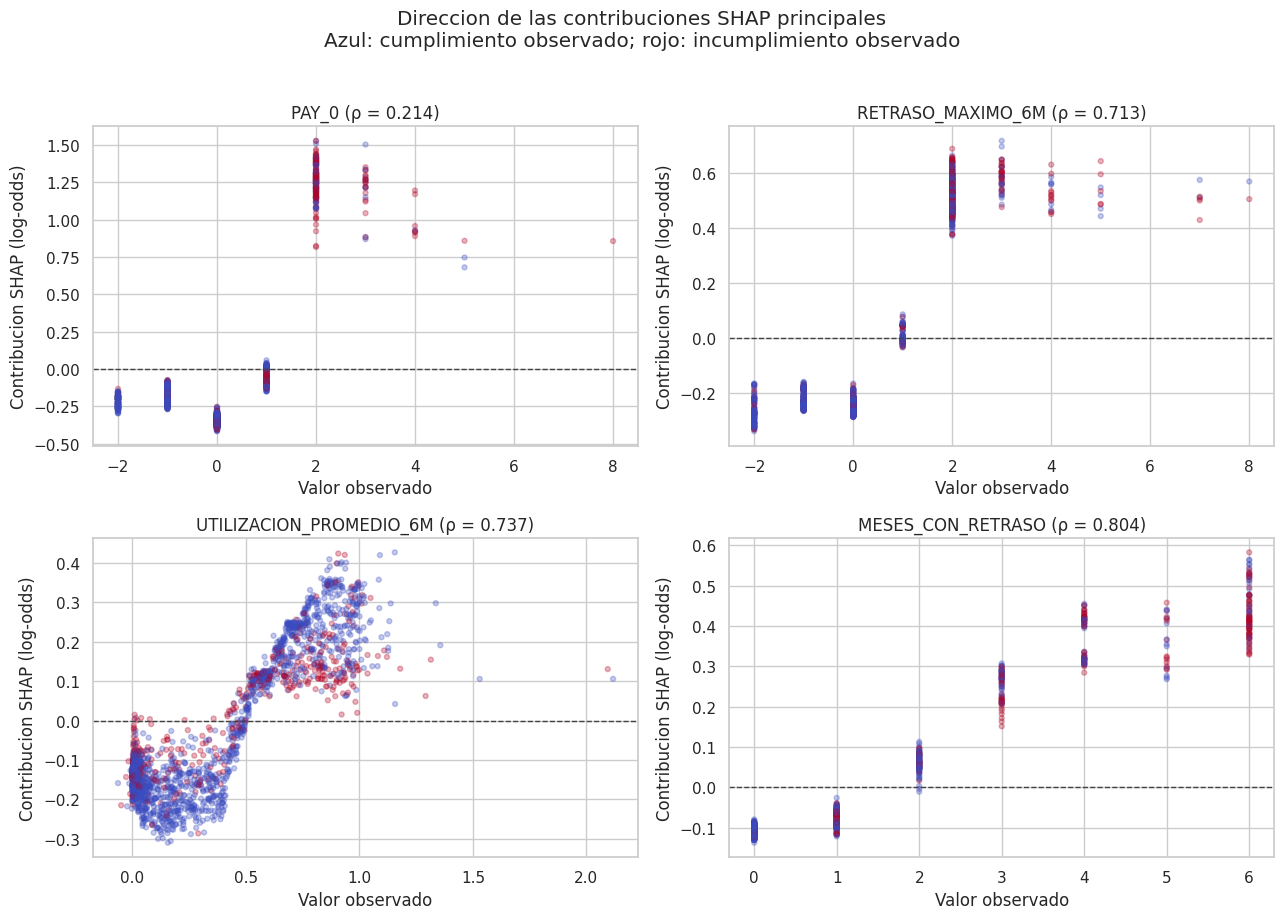

,Variable,Rho de Spearman,Valor p descriptivo,Direccion predominante
0,PAY_0,0.2144,0.0,Mayor valor → mayor salida del modelo
1,RETRASO_MAXIMO_6M,0.7126,0.0,Mayor valor → mayor salida del modelo
2,UTILIZACION_PROMEDIO_6M,0.7367,0.0,Mayor valor → mayor salida del modelo
3,MESES_CON_RETRASO,0.8041,0.0,Mayor valor → mayor salida del modelo


In [ ]:
variables_direccion_09 = [
    variable
    for variable in importancia_shap_agrupada_09["Variable"]
    if variable not in variables_nominales
][:4]

filas_direccion_09 = []
fig, ejes = plt.subplots(2, 2, figsize=(13, 9))

for eje, variable in zip(ejes.ravel(), variables_direccion_09):
    valores_variable = pd.to_numeric(
        X_muestra_original_09[variable],
        errors="coerce",
    ).to_numpy()
    contribuciones_variable = (
        contribuciones_agrupadas_09[variable].to_numpy()
    )
    rho, valor_p = spearmanr(
        valores_variable,
        contribuciones_variable,
        nan_policy="omit",
    )
    filas_direccion_09.append({
        "Variable": variable,
        "Rho de Spearman": rho,
        "Valor p descriptivo": valor_p,
        "Direccion predominante": (
            "Mayor valor → mayor salida del modelo"
            if rho > 0
            else "Mayor valor → menor salida del modelo"
        ),
    })

    dispersion = eje.scatter(
        valores_variable,
        contribuciones_variable,
        c=y_muestra_shap_09,
        cmap="coolwarm",
        alpha=0.30,
        s=13,
    )
    eje.axhline(0, color="#424242", linewidth=1, linestyle="--")
    eje.set_title(f"{variable} (ρ = {rho:.3f})")
    eje.set_xlabel("Valor observado")
    eje.set_ylabel(f"Contribucion SHAP ({escala_shap_09})")

fig.suptitle(
    "Direccion de las contribuciones SHAP principales\n"
    "Azul: cumplimiento observado; rojo: incumplimiento observado",
    y=1.02,
)
plt.tight_layout()
plt.show()

tabla_direccion_shap_09 = pd.DataFrame(filas_direccion_09)
display(tabla_direccion_shap_09.round(4))

## 9.7 Estabilidad de la importancia global

Se aplicó un *bootstrap* de 300 repeticiones sobre la muestra explicativa. En cada repetición se recalculó la media SHAP absoluta agrupada. Se obtuvieron intervalos descriptivos del 95 % y la frecuencia con la que cada variable apareció entre las diez más importantes.

Este procedimiento evaluó la estabilidad interna de la muestra interpretada; no sustituyó una validación externa con otra institución, periodo o población.


,Variable,Importancia media,IC 95 % inferior,IC 95 % superior,Frecuencia en top 10
0,PAY_0,0.36105,0.34806,0.37392,1.00000
1,RETRASO_MAXIMO_6M,0.31436,0.30856,0.32039,1.00000
2,UTILIZACION_PROMEDIO_6M,0.16332,0.16030,0.16618,1.00000
3,MESES_CON_RETRASO,0.13548,0.13117,0.13975,1.00000
4,LIMIT_BAL,0.13474,0.13143,0.13820,1.00000
5,BILL_AMT1,0.11115,0.10832,0.11396,1.00000
6,PAY_AMT2,0.08236,0.07949,0.08588,1.00000
7,PAY_AMT1,0.07913,0.07618,0.08164,1.00000
8,PAGO_PROMEDIO_6M,0.07513,0.07178,0.07836,1.00000
9,PAY_AMT3,0.05310,0.05130,0.05498,0.57000


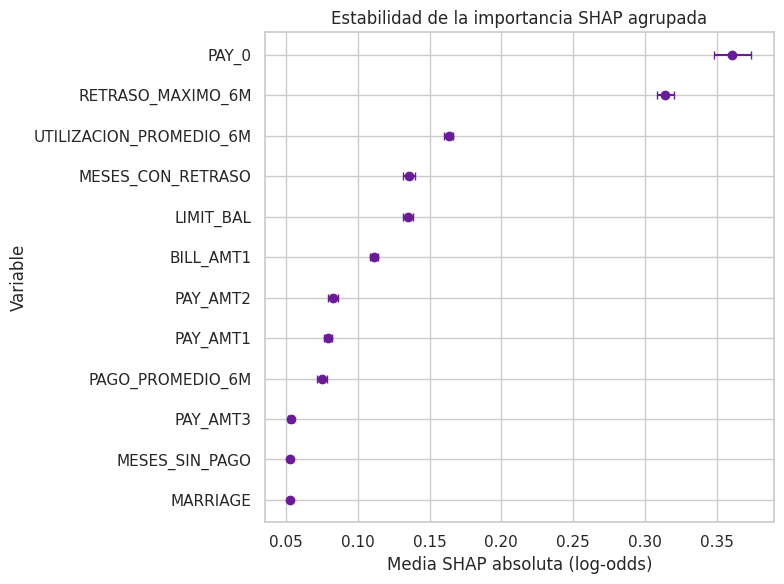

In [ ]:
repeticiones_estabilidad_09 = 300
generador_estabilidad_09 = np.random.default_rng(SEMILLA)
matriz_contribuciones_09 = contribuciones_agrupadas_09.to_numpy()

importancias_bootstrap_09 = np.empty(
    (
        repeticiones_estabilidad_09,
        matriz_contribuciones_09.shape[1],
    )
)

for repeticion in range(repeticiones_estabilidad_09):
    indices_bootstrap = generador_estabilidad_09.integers(
        0,
        len(matriz_contribuciones_09),
        size=len(matriz_contribuciones_09),
    )
    importancias_bootstrap_09[repeticion] = np.mean(
        np.abs(matriz_contribuciones_09[indices_bootstrap]),
        axis=0,
    )

frecuencia_top_10_09 = np.zeros(
    matriz_contribuciones_09.shape[1],
    dtype=float,
)
for fila_importancias in importancias_bootstrap_09:
    indices_top = np.argsort(fila_importancias)[-10:]
    frecuencia_top_10_09[indices_top] += 1
frecuencia_top_10_09 /= repeticiones_estabilidad_09

tabla_estabilidad_shap_09 = pd.DataFrame({
    "Variable": contribuciones_agrupadas_09.columns,
    "Importancia media": importancias_bootstrap_09.mean(axis=0),
    "IC 95 % inferior": np.percentile(
        importancias_bootstrap_09,
        2.5,
        axis=0,
    ),
    "IC 95 % superior": np.percentile(
        importancias_bootstrap_09,
        97.5,
        axis=0,
    ),
    "Frecuencia en top 10": frecuencia_top_10_09,
}).sort_values(
    "Importancia media",
    ascending=False,
).reset_index(drop=True)

display(tabla_estabilidad_shap_09.head(15).round(5))

top_estabilidad_09 = tabla_estabilidad_shap_09.head(12).iloc[::-1]
errores_estabilidad_09 = np.vstack([
    top_estabilidad_09["Importancia media"]
    - top_estabilidad_09["IC 95 % inferior"],
    top_estabilidad_09["IC 95 % superior"]
    - top_estabilidad_09["Importancia media"],
])

plt.figure(figsize=(8, 6))
plt.errorbar(
    top_estabilidad_09["Importancia media"],
    top_estabilidad_09["Variable"],
    xerr=errores_estabilidad_09,
    fmt="o",
    capsize=3,
    color="#6A1B9A",
)
plt.xlabel(f"Media SHAP absoluta ({escala_shap_09})")
plt.ylabel("Variable")
plt.title("Estabilidad de la importancia SHAP agrupada")
plt.tight_layout()
plt.show()

## 9.8 Coherencia entre SHAP y la importancia por ganancia

Se compararon dos perspectivas distintas:

- la ganancia de XGBoost, que resumió la mejora producida por las divisiones;
- la media SHAP absoluta, que resumió el impacto de las variables sobre las salidas individuales.

No se exigió una coincidencia exacta, ya que ambas medidas respondieron a preguntas diferentes. La correlación de rangos permitió verificar si ofrecían una jerarquía global razonablemente coherente.

,Variable,Media SHAP absoluta,Importancia por ganancia,Rango SHAP,Rango ganancia
0,PAY_0,0.36130,0.23287,1.0,2.0
1,RETRASO_MAXIMO_6M,0.31463,0.29055,2.0,1.0
2,UTILIZACION_PROMEDIO_6M,0.16316,0.01756,3.0,11.0
3,MESES_CON_RETRASO,0.13569,0.10627,4.0,3.0
4,LIMIT_BAL,0.13466,0.01581,5.0,13.0
5,BILL_AMT1,0.11107,0.01253,6.0,15.0
6,PAY_AMT2,0.08232,0.01503,7.0,14.0
7,PAY_AMT1,0.07913,0.01064,8.0,18.0
8,PAGO_PROMEDIO_6M,0.07500,0.01865,9.0,9.0
9,PAY_AMT3,0.05310,0.01029,10.0,19.0


Seccion 9.8 - Correlacion de rangos SHAP–ganancia: ρ = 0.580; p = 0.000979


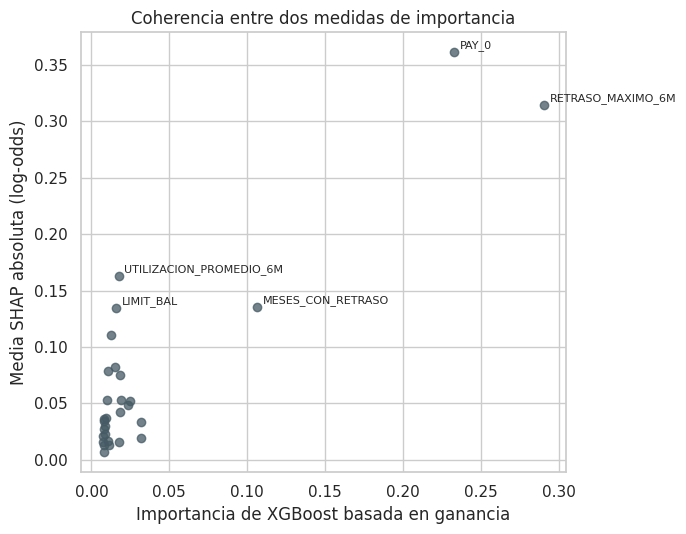

In [ ]:
tabla_coherencia_importancias_09 = (
    importancia_shap_agrupada_09[
        ["Variable", "Media SHAP absoluta"]
    ]
    .merge(
        importancia_agrupada_xgb.rename(columns={
            "variable_original": "Variable",
            "importancia": "Importancia por ganancia",
        }),
        on="Variable",
        how="inner",
    )
)

rho_importancias_09, p_importancias_09 = spearmanr(
    tabla_coherencia_importancias_09["Media SHAP absoluta"],
    tabla_coherencia_importancias_09["Importancia por ganancia"],
)

tabla_coherencia_importancias_09["Rango SHAP"] = (
    tabla_coherencia_importancias_09["Media SHAP absoluta"]
    .rank(ascending=False, method="min")
)
tabla_coherencia_importancias_09["Rango ganancia"] = (
    tabla_coherencia_importancias_09["Importancia por ganancia"]
    .rank(ascending=False, method="min")
)

display(
    tabla_coherencia_importancias_09
    .sort_values("Rango SHAP")
    .head(15)
    .round(5)
)
print(
    "Seccion 9.8 - Correlacion de rangos SHAP–ganancia: "
    f"ρ = {rho_importancias_09:.3f}; p = {p_importancias_09:.3g}"
)

plt.figure(figsize=(7, 5.5))
plt.scatter(
    tabla_coherencia_importancias_09["Importancia por ganancia"],
    tabla_coherencia_importancias_09["Media SHAP absoluta"],
    alpha=0.75,
    color="#455A64",
)

variables_etiquetadas_09 = set(
    importancia_shap_agrupada_09.head(5)["Variable"]
)
for _, fila in tabla_coherencia_importancias_09.iterrows():
    if fila["Variable"] in variables_etiquetadas_09:
        plt.annotate(
            fila["Variable"],
            (
                fila["Importancia por ganancia"],
                fila["Media SHAP absoluta"],
            ),
            fontsize=8,
            xytext=(4, 3),
            textcoords="offset points",
        )

plt.xlabel("Importancia de XGBoost basada en ganancia")
plt.ylabel(f"Media SHAP absoluta ({escala_shap_09})")
plt.title("Coherencia entre dos medidas de importancia")
plt.tight_layout()
plt.show()

## 9.9 Explicaciones locales de casos representativos

Se seleccionó un caso representativo de cada resultado de clasificación disponible: verdadero negativo, verdadero positivo, falso positivo y falso negativo. Dentro de cada grupo se eligió la observación cuya probabilidad estuvo más próxima a la mediana del grupo, para evitar presentar únicamente casos extremos.

Los gráficos de cascada mostraron cómo las características transformadas desplazaron la salida desde el valor base hasta la predicción individual. No se mostraron identificadores personales porque el conjunto importado no los contenía.

In [ ]:
tipos_resultado_09 = np.select(
    [
        (y_muestra_shap_09 == 0) & (predicciones_muestra_09 == 0),
        (y_muestra_shap_09 == 1) & (predicciones_muestra_09 == 1),
        (y_muestra_shap_09 == 0) & (predicciones_muestra_09 == 1),
        (y_muestra_shap_09 == 1) & (predicciones_muestra_09 == 0),
    ],
    [
        "Verdadero negativo",
        "Verdadero positivo",
        "Falso positivo",
        "Falso negativo",
    ],
    default="Sin clasificar",
)

orden_casos_09 = [
    "Verdadero negativo",
    "Verdadero positivo",
    "Falso positivo",
    "Falso negativo",
]

filas_casos_09 = []
for tipo in orden_casos_09:
    candidatos = np.flatnonzero(tipos_resultado_09 == tipo)
    if len(candidatos) == 0:
        continue
    mediana_probabilidad = np.median(
        probabilidades_muestra_09[candidatos]
    )
    posicion_local = candidatos[np.argmin(np.abs(
        probabilidades_muestra_09[candidatos]
        - mediana_probabilidad
    ))]
    filas_casos_09.append({
        "Tipo de resultado": tipo,
        "Posicion en muestra SHAP": int(posicion_local),
        "Posicion en prueba": int(
            posiciones_muestra_shap[posicion_local]
        ),
        "Clase observada": int(y_muestra_shap_09[posicion_local]),
        "Clase predicha": int(
            predicciones_muestra_09[posicion_local]
        ),
        "Probabilidad de incumplimiento": float(
            probabilidades_muestra_09[posicion_local]
        ),
    })

tabla_casos_locales_09 = pd.DataFrame(filas_casos_09)
display(tabla_casos_locales_09.round(4))

,Tipo de resultado,Posicion en muestra SHAP,Posicion en prueba,Clase observada,Clase predicha,Probabilidad de incumplimiento
0,Verdadero negativo,160,423,0,0,0.1147
1,Verdadero positivo,1843,5520,1,1,0.6418
2,Falso positivo,596,1727,0,1,0.4447
3,Falso negativo,1994,5984,1,0,0.1593


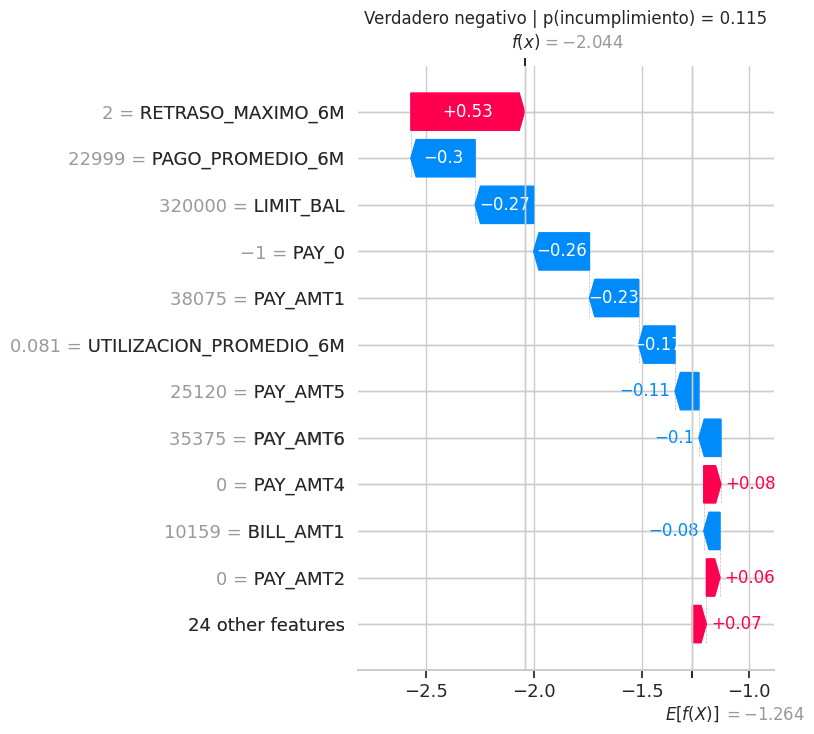

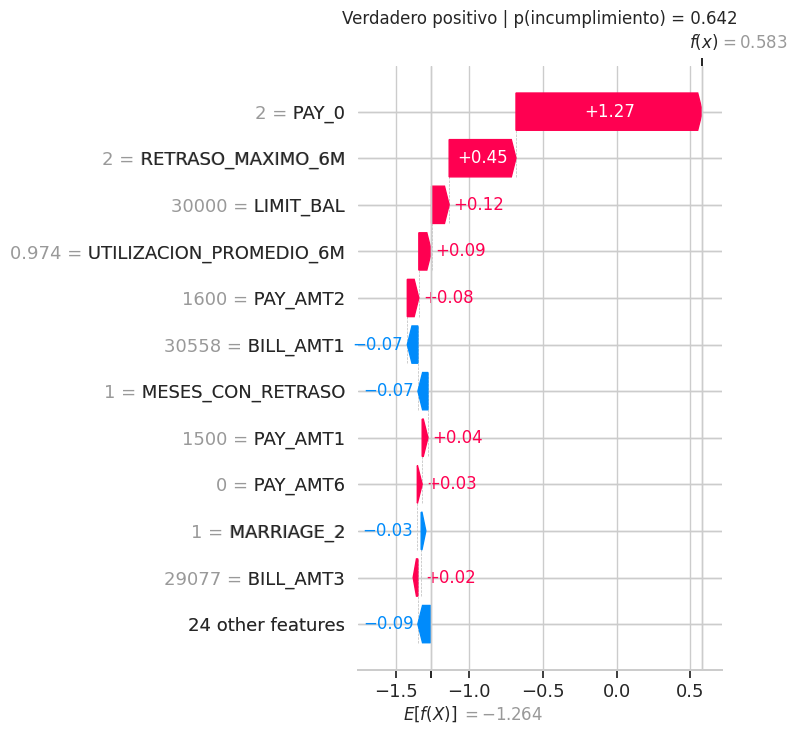

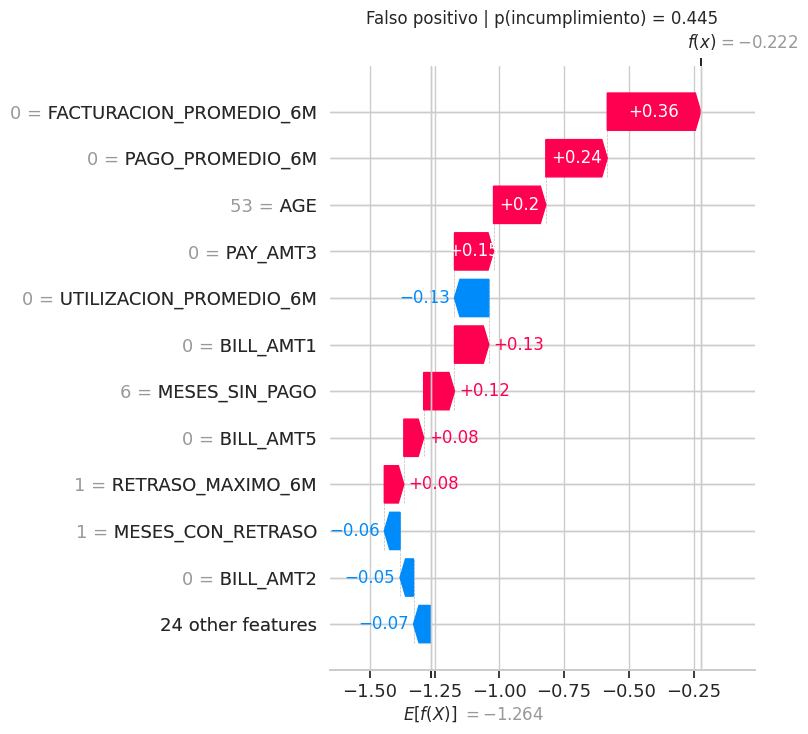

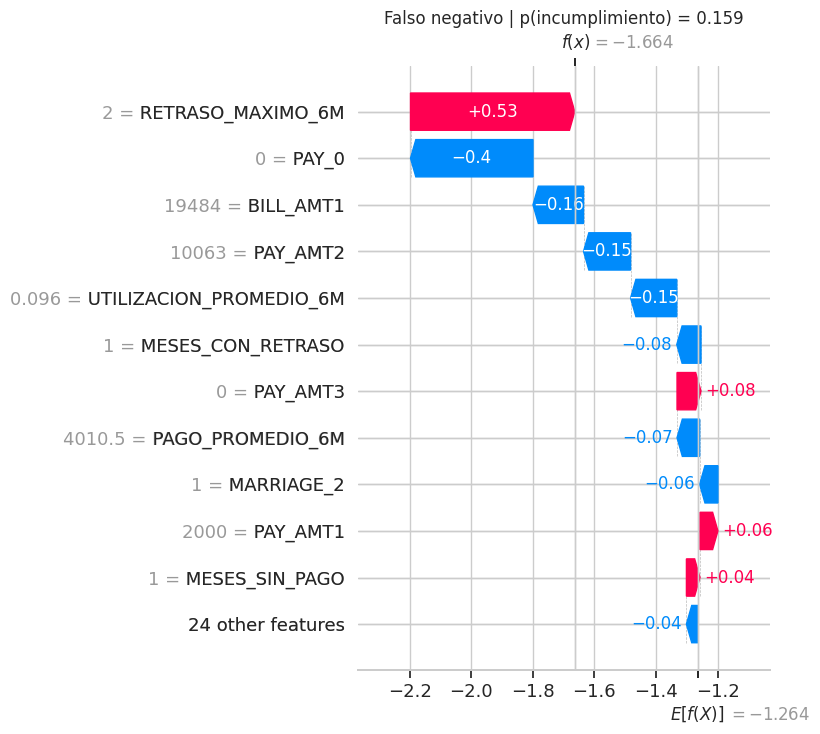

In [ ]:
for _, caso in tabla_casos_locales_09.iterrows():
    posicion_local = int(caso["Posicion en muestra SHAP"])
    shap.plots.waterfall(
        explicacion_shap_09[posicion_local],
        max_display=12,
        show=False,
    )
    plt.title(
        f"{caso['Tipo de resultado']} | "
        f"p(incumplimiento) = "
        f"{caso['Probabilidad de incumplimiento']:.3f}"
    )
    plt.tight_layout()
    plt.show()

## 9.10 Diagnóstico descriptivo por subgrupos

Como `SEX`, `EDUCATION` y `MARRIAGE` participaron en el modelo, se revisaron las métricas por categoría en el conjunto de prueba. Se calcularon tamaño, prevalencia, tasa de clasificación positiva, precisión, exhaustividad, tasa de falsos positivos y Brier. Para reducir estimaciones inestables, se excluyeron del resumen los subgrupos con menos de 100 registros.

Este análisis fue exploratorio. No constituyó una auditoría formal de equidad algorítmica, porque no se definieron criterios regulatorios o institucionales de equidad ni se calcularon inferencias específicas para esas brechas.


In [ ]:
def resumir_metricas_subgrupos_09(
    datos_originales,
    y_real,
    probabilidades,
    predicciones,
    variables_grupo,
    minimo_registros=100,
):
    filas = []
    datos_posicionales = datos_originales.reset_index(drop=True)
    y_array = np.asarray(y_real, dtype=int)
    probabilidades_array = np.asarray(probabilidades, dtype=float)
    predicciones_array = np.asarray(predicciones, dtype=int)

    for variable in variables_grupo:
        for categoria in sorted(
            datos_posicionales[variable].dropna().unique()
        ):
            mascara = (
                datos_posicionales[variable].to_numpy() == categoria
            )
            n_grupo = int(mascara.sum())
            if n_grupo < minimo_registros:
                continue

            y_grupo = y_array[mascara]
            p_grupo = probabilidades_array[mascara]
            pred_grupo = predicciones_array[mascara]
            tn, fp, fn, tp = confusion_matrix(
                y_grupo,
                pred_grupo,
                labels=[0, 1],
            ).ravel()

            filas.append({
                "Variable": variable,
                "Categoria": categoria,
                "Registros": n_grupo,
                "Prevalencia": y_grupo.mean(),
                "Tasa predicha positiva": pred_grupo.mean(),
                "Precision": (
                    tp / (tp + fp) if (tp + fp) else np.nan
                ),
                "Exhaustividad": (
                    tp / (tp + fn) if (tp + fn) else np.nan
                ),
                "Tasa de falsos positivos": (
                    fp / (fp + tn) if (fp + tn) else np.nan
                ),
                "Brier": brier_score_loss(y_grupo, p_grupo),
            })

    return pd.DataFrame(filas)


tabla_subgrupos_09 = resumir_metricas_subgrupos_09(
    X_test,
    y_test_09,
    probabilidades_test_09,
    predicciones_test_09,
    variables_nominales,
)

display(
    tabla_subgrupos_09
    .sort_values(["Variable", "Categoria"])
    .round(4)
)

rangos_subgrupos_09 = (
    tabla_subgrupos_09
    .groupby("Variable")
    .agg(
        categorias=("Categoria", "count"),
        registros_minimos=("Registros", "min"),
        recall_minimo=("Exhaustividad", "min"),
        recall_maximo=("Exhaustividad", "max"),
        fpr_minima=("Tasa de falsos positivos", "min"),
        fpr_maxima=("Tasa de falsos positivos", "max"),
    )
    .reset_index()
)
rangos_subgrupos_09["Brecha de exhaustividad"] = (
    rangos_subgrupos_09["recall_maximo"]
    - rangos_subgrupos_09["recall_minimo"]
)
rangos_subgrupos_09["Brecha de tasa de falsos positivos"] = (
    rangos_subgrupos_09["fpr_maxima"]
    - rangos_subgrupos_09["fpr_minima"]
)

display(rangos_subgrupos_09.round(4))

,Variable,Categoria,Registros,Prevalencia,Tasa predicha positiva,Precision,Exhaustividad,Tasa de falsos positivos,Brier
2,EDUCATION,1,2130,0.1901,0.1643,0.5543,0.4790,0.0904,0.1193
3,EDUCATION,2,2774,0.2365,0.2484,0.5501,0.5777,0.1464,0.1387
4,EDUCATION,3,1014,0.2574,0.2495,0.5257,0.5096,0.1594,0.1610
5,MARRIAGE,1,2767,0.2414,0.2277,0.5619,0.5299,0.1315,0.1418
6,MARRIAGE,2,3158,0.2049,0.2068,0.5345,0.5394,0.1211,0.1279
0,SEX,1,2402,0.2336,0.2427,0.5283,0.5490,0.1494,0.1422
1,SEX,2,3598,0.2129,0.1984,0.5588,0.5209,0.1112,0.1293


,Variable,categorias,registros_minimos,recall_minimo,recall_maximo,fpr_minima,fpr_maxima,Brecha de exhaustividad,Brecha de tasa de falsos positivos
0,EDUCATION,3,1014,0.4790,0.5777,0.0904,0.1594,0.0987,0.0689
1,MARRIAGE,2,2767,0.5299,0.5394,0.1211,0.1315,0.0095,0.0104
2,SEX,2,2402,0.5209,0.5490,0.1112,0.1494,0.0281,0.0381


## 9.11 Limitaciones y alcance de la generalización

La interpretación presentó cinco limitaciones principales: el carácter histórico y taiwanés del conjunto UCI, la ausencia de evidencia causal, la correlación entre variables financieras, el uso de una muestra de 2.000 registros y la selección del umbral mediante F1. Además, el análisis por subgrupos fue descriptivo y no constituyó una auditoría formal de equidad.

Por esta razón, una aplicación en Ecuador requeriría repetir la validación con datos locales, costes operativos y criterios institucionales.


## 9.12 Resultado de la interpretación

La síntesis reunió las variables principales, la estabilidad de sus importancias, la coherencia entre SHAP y la ganancia de XGBoost, los casos locales y las métricas por subgrupos. Los objetos se conservaron para la redacción final y la trazabilidad del análisis.


In [ ]:
top_variables_shap_09 = (
    importancia_shap_agrupada_09
    .head(10)["Variable"]
    .tolist()
)
variables_estables_top_09 = (
    tabla_estabilidad_shap_09
    .query("`Frecuencia en top 10` >= 0.80")
    ["Variable"]
    .tolist()
)

resultado_interpretabilidad_09 = {
    "dataset": resultado_comparativo_uci["dataset"],
    "estado": resultado_comparativo_uci["estado"],
    "modelo_interpretado": modelo_seleccionado,
    "registros_explicados": len(X_muestra_shap_09),
    "escala_shap": escala_shap_09,
    "error_maximo_aditividad": error_maximo_shap_09,
    "variables_principales": top_variables_shap_09,
    "variables_estables_top_10": variables_estables_top_09,
    "rho_shap_ganancia": rho_importancias_09,
    "tiempo_shap_s": tiempo_shap_09,
}

tabla_sintesis_09 = pd.DataFrame({
    "Elemento": [
        "Conjunto interpretado",
        "Estado",
        "Modelo",
        "Registros explicados",
        "Escala de las contribuciones",
        "Cinco variables principales",
        "Variables estables en top 10 (≥80 %)",
        "Correlacion SHAP–ganancia",
        "Error maximo de aditividad",
    ],
    "Resultado": [
        resultado_interpretabilidad_09["dataset"],
        resultado_interpretabilidad_09["estado"],
        resultado_interpretabilidad_09["modelo_interpretado"],
        resultado_interpretabilidad_09["registros_explicados"],
        resultado_interpretabilidad_09["escala_shap"],
        ", ".join(top_variables_shap_09[:5]),
        ", ".join(variables_estables_top_09),
        f"{rho_importancias_09:.3f}",
        f"{error_maximo_shap_09:.2e}",
    ],
})

display(tabla_sintesis_09)

print("Seccion 9.12 - Objetos conservados para la redaccion final y la trazabilidad:")
print("- importancia_shap_agrupada_09")
print("- tabla_direccion_shap_09")
print("- tabla_estabilidad_shap_09")
print("- tabla_coherencia_importancias_09")
print("- tabla_casos_locales_09")
print("- tabla_subgrupos_09")
print("- resultado_interpretabilidad_09")

,Elemento,Resultado
0,Conjunto interpretado,UCI Default of Credit Card Clients
1,Estado,Seleccion final dentro del alcance del conjunt...
2,Modelo,XGBoost
3,Registros explicados,2000
4,Escala de las contribuciones,log-odds
5,Cinco variables principales,"PAY_0, RETRASO_MAXIMO_6M, UTILIZACION_PROMEDIO..."
6,Variables estables en top 10 (≥80 %),"PAY_0, RETRASO_MAXIMO_6M, UTILIZACION_PROMEDIO..."
7,Correlacion SHAP–ganancia,0.580
8,Error maximo de aditividad,4.00e-07


Seccion 9.12 - Objetos conservados para la redaccion final y la trazabilidad:
- importancia_shap_agrupada_09
- tabla_direccion_shap_09
- tabla_estabilidad_shap_09
- tabla_coherencia_importancias_09
- tabla_casos_locales_09
- tabla_subgrupos_09
- resultado_interpretabilidad_09


## 9.13 Referencias

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. En *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 785–794). Association for Computing Machinery. https://doi.org/10.1145/2939672.2939785

Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., Nair, B., Katz, R., Himmelfarb, J., Bansal, N., & Lee, S.-I. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence, 2*, 56–67. https://doi.org/10.1038/s42256-019-0138-9

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. En *Advances in Neural Information Processing Systems 30* (pp. 4765–4774).

Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473–2480. https://doi.org/10.1016/j.eswa.2007.12.020

# 10_Consolidacion_y_exportacion_de_resultados

En esta fase se consolidaron las métricas, las predicciones, la interpretación y el modelo seleccionado. También se generaron tablas, figuras, metadatos y un paquete comprimido para la redacción del TFM.

La exportación no modificó el entrenamiento ni utilizó nuevamente el conjunto de prueba para ajustar hiperparámetros o umbrales.


## 10.1 Alcance y dependencias

La sección reutilizó exclusivamente los objetos obtenidos en las secciones 08 y 09. Antes de exportar, se comprobó que el modelo seleccionado fuera XGBoost, que las predicciones correspondieran a los 6.000 registros de prueba y que las tablas de comparación e interpretabilidad estuvieran disponibles.


In [ ]:
from datetime import datetime, timezone
from hashlib import sha256
from importlib import metadata as importlib_metadata
from pathlib import Path
import json
import platform
import sys
import zipfile

import joblib

objetos_requeridos_10 = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "tabla_comparacion_modelos",
    "tabla_bootstrap_pareado",
    "tabla_generalizacion",
    "tabla_tiempos_modelos",
    "tabla_errores_modelos",
    "modelo_seleccionado",
    "modelo_seleccionado_objeto",
    "probabilidades_test_xgb",
    "predicciones_test_xgb_f1",
    "umbral_f1_xgb",
    "busqueda_xgb",
    "importancia_shap_agrupada_09",
    "tabla_direccion_shap_09",
    "tabla_estabilidad_shap_09",
    "tabla_coherencia_importancias_09",
    "tabla_casos_locales_09",
    "tabla_subgrupos_09",
    "rangos_subgrupos_09",
    "resultado_comparativo_uci",
    "resultado_interpretabilidad_09",
]

faltantes_10 = [
    nombre for nombre in objetos_requeridos_10
    if nombre not in globals()
]
if faltantes_10:
    raise NameError(
        "Faltan objetos de las secciones anteriores: "
        + ", ".join(faltantes_10)
        + ". Ejecute el notebook desde el inicio."
    )

assert modelo_seleccionado in modelos_ajustados
assert len(X_test) == len(y_test) == len(probabilidades_test_xgb)
assert len(predicciones_test_xgb_f1) == len(y_test)

print("Seccion 10.1 - Dependencias de consolidacion disponibles y validadas.")


Seccion 10.1 - Dependencias de consolidacion disponibles y validadas.


## 10.2 Comprobaciones finales de coherencia

Se recalcularon las métricas principales de XGBoost y se contrastaron con la tabla comparativa. También se verificó que las clases predichas fueran exactamente las obtenidas al aplicar el umbral seleccionado mediante predicciones fuera de muestra en entrenamiento.


In [ ]:
probabilidades_modelo_final_10 = probabilidades_comparacion[modelo_seleccionado]
predicciones_modelo_final_10 = predicciones_comparacion[modelo_seleccionado]
umbral_modelo_final_10 = umbrales_comparacion[modelo_seleccionado]

metricas_modelo_final_10 = {
    "ROC-AUC": roc_auc_score(y_test, probabilidades_modelo_final_10),
    "PR-AUC": average_precision_score(y_test, probabilidades_modelo_final_10),
    "Exactitud": (predicciones_modelo_final_10 == np.asarray(y_test)).mean(),
    "Exactitud balanceada": balanced_accuracy_score(
        y_test, predicciones_modelo_final_10
    ),
    "Precision": precision_score(
        y_test, predicciones_modelo_final_10, zero_division=0
    ),
    "Exhaustividad": recall_score(
        y_test, predicciones_modelo_final_10, zero_division=0
    ),
    "F1": f1_score(
        y_test, predicciones_modelo_final_10, zero_division=0
    ),
    "Brier": brier_score_loss(y_test, probabilidades_modelo_final_10),
    "Umbral": float(umbral_modelo_final_10),
}

metricas_modelo_guardadas_10 = (
    tabla_comparacion_modelos
    .set_index("Modelo")
    .loc[modelo_seleccionado, list(metricas_modelo_final_10)]
    .astype(float)
)

diferencias_metricas_10 = {
    metrica: abs(
        valor - float(metricas_modelo_guardadas_10[metrica])
    )
    for metrica, valor in metricas_modelo_final_10.items()
}
maxima_diferencia_metricas_10 = max(diferencias_metricas_10.values())

predicciones_reconstruidas_10 = (
    np.asarray(probabilidades_modelo_final_10) >= float(umbral_modelo_final_10)
).astype(int)

assert maxima_diferencia_metricas_10 < 1e-10
assert np.array_equal(
    predicciones_reconstruidas_10,
    np.asarray(predicciones_modelo_final_10),
)

tabla_validacion_final_10 = pd.DataFrame({
    "Comprobacion": [
        "Registros de entrenamiento",
        "Registros de prueba",
        "Prevalencia de incumplimiento en prueba",
        "Probabilidades finitas y en [0, 1]",
        "Predicciones coherentes con el umbral",
        "Maxima diferencia entre metricas",
        "Modelo seleccionado",
    ],
    "Resultado": [
        len(X_train),
        len(X_test),
        float(np.asarray(y_test).mean()),
        bool(
            np.isfinite(probabilidades_modelo_final_10).all()
            and ((np.asarray(probabilidades_modelo_final_10) >= 0)
                 & (np.asarray(probabilidades_modelo_final_10) <= 1)).all()
        ),
        True,
        maxima_diferencia_metricas_10,
        modelo_seleccionado,
    ],
})

display(tabla_validacion_final_10)
print("Seccion 10.2 - Las metricas y predicciones finales fueron reconciliadas.")


,Comprobacion,Resultado
0,Registros de entrenamiento,24000
1,Registros de prueba,6000
2,Prevalencia de incumplimiento en prueba,0.221167
3,"Probabilidades finitas y en [0, 1]",True
4,Predicciones coherentes con el umbral,True
5,Maxima diferencia entre metricas,0.0
6,Modelo seleccionado,XGBoost


Seccion 10.2 - Las metricas y predicciones finales fueron reconciliadas.


## 10.3 Tablas consolidadas

Las tablas se guardaron en formato CSV con codificación UTF-8. Este formato facilitó su revisión, reutilización en el documento académico y trazabilidad sin depender de las salidas visuales del notebook.


In [ ]:
directorio_base_10 = (
    Path("/content")
    if Path("/content").exists()
    else Path.cwd()
)
directorio_exportacion_10 = directorio_base_10 / "TFM_Resultados_UCI"
directorio_tablas_10 = directorio_exportacion_10 / "tablas"
directorio_figuras_10 = directorio_exportacion_10 / "figuras"
directorio_modelo_10 = directorio_exportacion_10 / "modelo"

for directorio in [
    directorio_exportacion_10,
    directorio_tablas_10,
    directorio_figuras_10,
    directorio_modelo_10,
]:
    directorio.mkdir(parents=True, exist_ok=True)

tablas_exportacion_10 = {
    "comparacion_modelos.csv": tabla_comparacion_modelos,
    "errores_modelos.csv": tabla_errores_modelos,
    "bootstrap_pareado.csv": tabla_bootstrap_pareado,
    "generalizacion_modelos.csv": tabla_generalizacion,
    "tiempos_modelos.csv": tabla_tiempos_modelos,
    "importancia_shap_agrupada.csv": importancia_shap_agrupada_09,
    "direccion_contribuciones_shap.csv": tabla_direccion_shap_09,
    "estabilidad_importancia_shap.csv": tabla_estabilidad_shap_09,
    "coherencia_shap_ganancia.csv": tabla_coherencia_importancias_09,
    "casos_locales_shap.csv": tabla_casos_locales_09,
    "metricas_subgrupos.csv": tabla_subgrupos_09,
    "brechas_subgrupos.csv": rangos_subgrupos_09,
}

rutas_tablas_10 = []
for nombre_archivo, tabla in tablas_exportacion_10.items():
    ruta = directorio_tablas_10 / nombre_archivo
    tabla.to_csv(ruta, index=False, encoding="utf-8")
    rutas_tablas_10.append(ruta)

tabla_archivos_csv_10 = pd.DataFrame({
    "Archivo": [ruta.name for ruta in rutas_tablas_10],
    "Filas": [len(tabla) for tabla in tablas_exportacion_10.values()],
})
display(tabla_archivos_csv_10)


,Archivo,Filas
0,comparacion_modelos.csv,3
1,errores_modelos.csv,3
2,bootstrap_pareado.csv,12
3,generalizacion_modelos.csv,3
4,tiempos_modelos.csv,3
5,importancia_shap_agrupada.csv,29
6,direccion_contribuciones_shap.csv,4
7,estabilidad_importancia_shap.csv,29
8,coherencia_shap_ganancia.csv,29
9,casos_locales_shap.csv,4


## 10.4 Predicciones finales y conservación del modelo

Se exportaron las predicciones del conjunto de prueba sin identificadores personales. La posición fue un índice técnico dentro de la partición de prueba y no correspondió al identificador original del cliente. El modelo se guardó como una canalización completa, incluyendo el preprocesamiento y XGBoost.

Los archivos serializados mediante `joblib` solo deben cargarse cuando proceden de una fuente confiable y con versiones de software compatibles.


In [ ]:
tabla_predicciones_modelo_10 = pd.DataFrame({
    "posicion_prueba": np.arange(len(y_test), dtype=int),
    "clase_observada": np.asarray(y_test, dtype=int),
    "probabilidad_incumplimiento": np.asarray(
        probabilidades_modelo_final_10, dtype=float
    ),
    "umbral_clasificacion": float(umbral_modelo_final_10),
    "clase_predicha": np.asarray(
        predicciones_modelo_final_10, dtype=int
    ),
})
tabla_predicciones_xgb_10 = tabla_predicciones_modelo_10

tabla_predicciones_modelo_10["tipo_resultado"] = np.select(
    [
        (tabla_predicciones_modelo_10["clase_observada"] == 0)
        & (tabla_predicciones_modelo_10["clase_predicha"] == 0),
        (tabla_predicciones_modelo_10["clase_observada"] == 1)
        & (tabla_predicciones_modelo_10["clase_predicha"] == 1),
        (tabla_predicciones_modelo_10["clase_observada"] == 0)
        & (tabla_predicciones_modelo_10["clase_predicha"] == 1),
        (tabla_predicciones_modelo_10["clase_observada"] == 1)
        & (tabla_predicciones_modelo_10["clase_predicha"] == 0),
    ],
    ["VN", "VP", "FP", "FN"],
    default="NA",
)

ruta_predicciones_10 = (
    directorio_tablas_10 / f"predicciones_prueba_{modelo_seleccionado.lower().replace(chr(32), chr(95))}.csv"
)
tabla_predicciones_modelo_10.to_csv(
    ruta_predicciones_10,
    index=False,
    encoding="utf-8",
)

ruta_modelo_10 = directorio_modelo_10 / f"pipeline_{modelo_seleccionado.lower().replace(chr(32), chr(95))}.joblib"
joblib.dump(modelo_seleccionado_objeto, ruta_modelo_10)

modelo_recargado_10 = joblib.load(ruta_modelo_10)
probabilidades_recargadas_10 = modelo_recargado_10.predict_proba(
    X_test.iloc[:100]
)[:, 1]
error_serializacion_10 = float(np.max(np.abs(
    probabilidades_recargadas_10
    - np.asarray(probabilidades_modelo_final_10[:100])
)))

assert len(tabla_predicciones_modelo_10) == len(y_test)
assert error_serializacion_10 < 1e-10

print(f"Seccion 10.4 - Predicciones exportadas: {len(tabla_predicciones_modelo_10):,}")
print(f"Error maximo tras recargar el modelo: {error_serializacion_10:.2e}")


Seccion 10.4 - Predicciones exportadas: 6,000
Error maximo tras recargar el modelo: 0.00e+00


## 10.5 Figuras para el documento académico

Se generaron figuras en formato PNG a 300 puntos por pulgada. Las curvas utilizaron el mismo conjunto de prueba y las mismas probabilidades ya evaluadas, mientras que la importancia global correspondió a los valores SHAP agrupados de la sección 09.


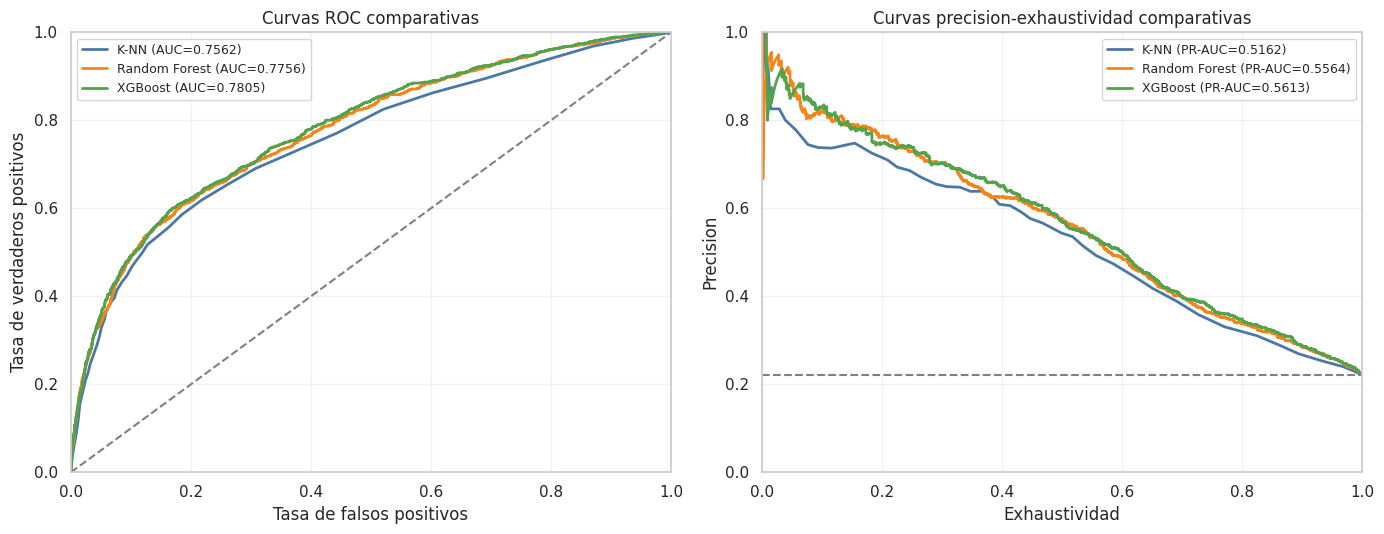

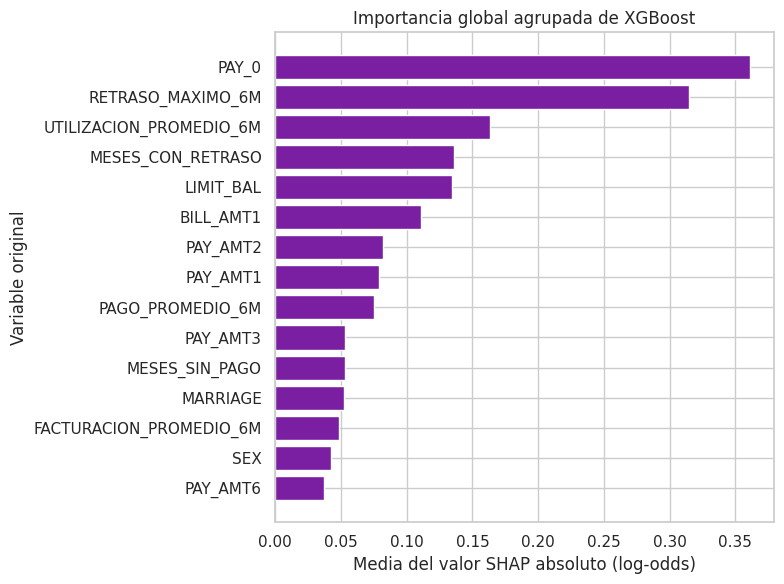

Seccion 10.5 - Figuras exportadas a 300 dpi.


In [ ]:
# Curvas ROC y precision-exhaustividad.
fig, ejes = plt.subplots(1, 2, figsize=(14, 5.5))
for modelo in modelos_orden:
    probabilidades = probabilidades_comparacion[modelo]
    tasa_fp, tasa_tp, _ = roc_curve(y_test_comparacion, probabilidades)
    precision_curva, recall_curva, _ = precision_recall_curve(
        y_test_comparacion, probabilidades
    )
    ejes[0].plot(
        tasa_fp,
        tasa_tp,
        linewidth=2,
        color=colores_modelos[modelo],
        label=(
            f"{modelo} (AUC="
            f"{roc_auc_score(y_test_comparacion, probabilidades):.4f})"
        ),
    )
    ejes[1].plot(
        recall_curva,
        precision_curva,
        linewidth=2,
        color=colores_modelos[modelo],
        label=(
            f"{modelo} (PR-AUC="
            f"{average_precision_score(y_test_comparacion, probabilidades):.4f})"
        ),
    )

ejes[0].plot([0, 1], [0, 1], "--", color="gray")
ejes[0].set(
    title="Curvas ROC comparativas",
    xlabel="Tasa de falsos positivos",
    ylabel="Tasa de verdaderos positivos",
    xlim=(0, 1),
    ylim=(0, 1),
)
ejes[1].axhline(
    y_test_comparacion.mean(), linestyle="--", color="gray"
)
ejes[1].set(
    title="Curvas precision-exhaustividad comparativas",
    xlabel="Exhaustividad",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1),
)
for eje in ejes:
    eje.legend(fontsize=9)
    eje.grid(alpha=0.25)
fig.tight_layout()
ruta_curvas_10 = directorio_figuras_10 / "curvas_roc_pr.png"
fig.savefig(ruta_curvas_10, dpi=300, bbox_inches="tight")
plt.show()

# Importancia SHAP agrupada.
top_importancia_10 = (
    importancia_shap_agrupada_09.head(15).iloc[::-1]
)
fig, eje = plt.subplots(figsize=(8, 6))
eje.barh(
    top_importancia_10["Variable"],
    top_importancia_10["Media SHAP absoluta"],
    color="#7B1FA2",
)
eje.set(
    title="Importancia global agrupada de XGBoost",
    xlabel=f"Media del valor SHAP absoluto ({escala_shap_09})",
    ylabel="Variable original",
)
fig.tight_layout()
ruta_importancia_10 = (
    directorio_figuras_10 / "importancia_global_shap.png"
)
fig.savefig(ruta_importancia_10, dpi=300, bbox_inches="tight")
plt.show()

print("Seccion 10.5 - Figuras exportadas a 300 dpi.")


## 10.6 Metadatos y reproducibilidad

Los metadatos distinguieron entre el periodo de observación de los registros y la fecha de incorporación al repositorio UCI. También conservaron la semilla, el particionado, el umbral, las métricas, los mejores hiperparámetros y las versiones principales del entorno.


In [ ]:
def hacer_serializable_10(objeto):
    if isinstance(objeto, dict):
        return {
            str(clave): hacer_serializable_10(valor)
            for clave, valor in objeto.items()
        }
    if isinstance(objeto, (list, tuple)):
        return [hacer_serializable_10(valor) for valor in objeto]
    if isinstance(objeto, Path):
        return str(objeto)
    if isinstance(objeto, (np.integer,)):
        return int(objeto)
    if isinstance(objeto, (np.floating,)):
        return float(objeto)
    if isinstance(objeto, (np.bool_,)):
        return bool(objeto)
    if objeto is None or isinstance(objeto, (str, int, float, bool)):
        return objeto
    return str(objeto)


def version_paquete_10(nombre):
    try:
        return importlib_metadata.version(nombre)
    except importlib_metadata.PackageNotFoundError:
        return "No disponible"


metadatos_modelo_10 = {
    "dataset": {
        "nombre": "Default of Credit Card Clients",
        "repositorio": "UCI Machine Learning Repository",
        "identificador_uci": 350,
        "doi": "10.24432/C55S3H",
        "unidad_analisis": "cliente de tarjeta de credito",
        "ventana_observacion": "abril-septiembre de 2005",
        "horizonte_prediccion": "octubre de 2005",
        "fecha_incorporacion_uci": "2016-01-25",
        "poblacion_origen": "clientes de Taiwan",
    },
    "experimento": {
        "metodologia": "CRISP-DM",
        "semilla": int(SEMILLA),
        "variable_objetivo": "default_payment_next_month",
        "registros_entrenamiento": int(len(X_train)),
        "registros_prueba": int(len(X_test)),
        "prevalencia_prueba": float(np.asarray(y_test).mean()),
        "modelo_seleccionado": modelo_seleccionado,
        "criterio_seleccion": "ROC-AUC de validacion cruzada en entrenamiento",
        "umbral_seleccionado_en_entrenamiento": float(umbral_modelo_final_10),
        "metricas_prueba": metricas_modelo_final_10,
        "mejores_hiperparametros": busqueda_modelo_seleccionado.best_params_,
        "estado": resultado_comparativo_uci["estado"],
    },
    "interpretabilidad": resultado_interpretabilidad_09,
    "entorno": {
        "fecha_exportacion_utc": datetime.now(timezone.utc).isoformat(),
        "python": platform.python_version(),
        "plataforma": platform.platform(),
        "numpy": version_paquete_10("numpy"),
        "pandas": version_paquete_10("pandas"),
        "scikit-learn": version_paquete_10("scikit-learn"),
        "xgboost": version_paquete_10("xgboost"),
        "shap": version_paquete_10("shap"),
        "joblib": version_paquete_10("joblib"),
    },
    "limitacion_principal": (
        "Los resultados corresponden a una muestra historica de clientes "
        "de Taiwan y no constituyen validacion empirica directa para Ecuador."
    ),
}

ruta_metadatos_10 = directorio_exportacion_10 / "metadatos_modelo.json"
with open(ruta_metadatos_10, "w", encoding="utf-8") as archivo:
    json.dump(
        hacer_serializable_10(metadatos_modelo_10),
        archivo,
        ensure_ascii=False,
        indent=2,
    )

print(f"Seccion 10.6 - Metadatos guardados: {ruta_metadatos_10.name}")


Seccion 10.6 - Metadatos guardados: metadatos_modelo.json


## 10.7 Manifiesto de archivos y verificación criptográfica

Se calculó SHA-256 para cada archivo exportado. El manifiesto permitió comprobar posteriormente que un archivo no hubiese cambiado desde la generación del paquete.


In [ ]:
ruta_readme_10 = directorio_exportacion_10 / "LEEME.txt"
contenido_readme_10 = f'''TFM - Prediccion del incumplimiento en tarjetas de credito

Conjunto: UCI Default of Credit Card Clients
Periodo observado: abril-septiembre de 2005
Horizonte: incumplimiento en octubre de 2005
Fecha de incorporacion al repositorio UCI: 25 de enero de 2016
Modelo seleccionado: {modelo_seleccionado}
Umbral: {umbral_modelo_final_10:.6f}
ROC-AUC de prueba: {metricas_modelo_final_10['ROC-AUC']:.6f}
PR-AUC de prueba: {metricas_modelo_final_10['PR-AUC']:.6f}
F1 de prueba: {metricas_modelo_final_10['F1']:.6f}

Contenido:
- tablas/: metricas, comparaciones, predicciones e interpretabilidad.
- figuras/: curvas comparativas e importancia global SHAP a 300 dpi.
- modelo/: canalizacion completa de preprocesamiento y modelo seleccionado.
- metadatos_modelo.json: configuracion, versiones, alcance y limitaciones.
- manifiesto_sha256.csv: tamaño y huella de cada archivo.

Advertencia: cargue el archivo joblib unicamente si proviene de una fuente
confiable. Para reutilizar el modelo, procure conservar versiones compatibles
de Python, scikit-learn y la biblioteca del modelo.

Alcance: los resultados corresponden al conjunto UCI de clientes de Taiwan;
no constituyen una validacion empirica directa para Ecuador.
'''
ruta_readme_10.write_text(contenido_readme_10, encoding="utf-8")

archivos_para_manifiesto_10 = sorted([
    *rutas_tablas_10,
    ruta_predicciones_10,
    ruta_modelo_10,
    ruta_curvas_10,
    ruta_importancia_10,
    ruta_metadatos_10,
    ruta_readme_10,
])

filas_manifiesto_10 = []
for ruta in archivos_para_manifiesto_10:
    hash_archivo = sha256()
    with open(ruta, "rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            hash_archivo.update(bloque)
    filas_manifiesto_10.append({
        "archivo": str(ruta.relative_to(directorio_exportacion_10)),
        "tamano_bytes": ruta.stat().st_size,
        "sha256": hash_archivo.hexdigest(),
    })

tabla_manifiesto_10 = pd.DataFrame(filas_manifiesto_10)
ruta_manifiesto_10 = (
    directorio_exportacion_10 / "manifiesto_sha256.csv"
)
tabla_manifiesto_10.to_csv(
    ruta_manifiesto_10,
    index=False,
    encoding="utf-8",
)
display(tabla_manifiesto_10)


,archivo,tamano_bytes,sha256
0,LEEME.txt,1086,3724f1b98f81947e5106a2d7bb9abdd7a161da5c22e82c...
1,figuras/curvas_roc_pr.png,394420,4f31b5a6da4ef8cc8d86bc5f303c87e0af200602c3674a...
2,figuras/importancia_global_shap.png,187178,cb9b597d498ecebeeb22643f6350116783defbd2301e76...
3,metadatos_modelo.json,3018,f32df0029003c21c13db0edf312adb73a18e68768d370b...
4,modelo/pipeline_xgboost.joblib,589463,d9d329068d15988288b3e1451381ef4c7ac9f0397644d9...
5,tablas/bootstrap_pareado.csv,1678,83ab1f50d64b5a4ada06cda5bc09fa26cc4410cb29dfda...
6,tablas/brechas_subgrupos.csv,545,756f2764eb3a56d2edcbb7aa1f7ad2cbb1f3d629654768...
7,tablas/casos_locales_shap.csv,322,aabefbd82131b1dc71d9b79f30653319d195d5b78f963a...
8,tablas/coherencia_shap_ganancia.csv,1584,df0ceb248d2c283bdec37e0e19f8f432ddf596d8658548...
9,tablas/comparacion_modelos.csv,612,39c899c8e31fff46101b87a2e3af4e75ae309d4f474e76...


## 10.8 Paquete comprimido y descarga

Todos los archivos se reunieron en un ZIP. El enlace generado permite descargar el paquete desde el notebook. En Google Colab también puede utilizarse `files.download(str(ruta_zip_10))` si se desea iniciar la descarga mediante código.


In [ ]:
ruta_zip_10 = directorio_base_10 / "TFM_Resultados_UCI.zip"
archivos_paquete_10 = [
    *archivos_para_manifiesto_10,
    ruta_manifiesto_10,
]

with zipfile.ZipFile(
    ruta_zip_10,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archivo_zip:
    for ruta in archivos_paquete_10:
        archivo_zip.write(
            ruta,
            arcname=str(ruta.relative_to(directorio_exportacion_10)),
        )

with zipfile.ZipFile(ruta_zip_10, mode="r") as archivo_zip:
    prueba_zip_10 = archivo_zip.testzip()
    nombres_zip_10 = archivo_zip.namelist()

assert prueba_zip_10 is None
assert len(nombres_zip_10) == len(archivos_paquete_10)

print(f"Seccion 10.8 - Paquete creado: {ruta_zip_10}")
print(f"Archivos incluidos: {len(nombres_zip_10)}")
print(f"Tamaño: {ruta_zip_10.stat().st_size / 1024**2:.2f} MB")

try:
    from IPython.display import FileLink
    display(FileLink(str(ruta_zip_10)))
except ImportError:
    print("Utilice la ruta anterior para descargar el archivo.")


Seccion 10.8 - Paquete creado: /content/TFM_Resultados_UCI.zip
Archivos incluidos: 19
Tamaño: 0.67 MB


/content/TFM_Resultados_UCI.zip

In [ ]:
from pathlib import Path

ruta_zip = (
    Path("/content/TFM_Resultados_UCI.zip")
    if Path("/content").exists()
    else Path.cwd() / "TFM_Resultados_UCI.zip"
)

if ruta_zip.exists():
    print(f"Seccion 10.8 - Archivo disponible: {ruta_zip}")
    print(f"Tamano: {ruta_zip.stat().st_size / 1024**2:.2f} MB")
    try:
        from google.colab import files
    except ImportError:
        print("La descarga automatica solo se ejecuta en Google Colab.")
    else:
        files.download(str(ruta_zip))
else:
    print("El archivo ZIP no existe. Vuelva a ejecutar la seccion 10.8.")


Seccion 10.8 - Archivo disponible: /content/TFM_Resultados_UCI.zip
Tamano: 0.67 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10.9 Resultado final del flujo experimental

La consolidación dejó trazables el conjunto de datos, las particiones, los modelos, el umbral, las métricas, la interpretación y las versiones del entorno. El modelo final se seleccionó mediante ROC-AUC de validación cruzada y su rendimiento se estimó en el conjunto de prueba. También se identificó el algoritmo con mayor exhaustividad, debido a que una decisión operativa podría cambiar si los falsos negativos tuvieran un coste especialmente alto.

Los resultados se limitaron a clientes de Taiwán observados en 2005. Su aplicación en Ecuador requeriría una validación externa con datos locales.


In [ ]:
resultado_consolidado_10 = {
    "dataset": resultado_comparativo_uci["dataset"],
    "periodo_observacion": "abril-septiembre de 2005",
    "horizonte_prediccion": "octubre de 2005",
    "fecha_incorporacion_uci": "25 de enero de 2016",
    "modelo_seleccionado": modelo_seleccionado,
    "umbral": float(umbral_modelo_final_10),
    "metricas_prueba": metricas_modelo_final_10,
    "variables_principales_shap": (
        resultado_interpretabilidad_09["variables_principales"][:5]
    ),
    "error_serializacion": error_serializacion_10,
    "archivos_exportados": len(archivos_paquete_10),
    "ruta_zip": str(ruta_zip_10),
}

tabla_sintesis_final_10 = pd.DataFrame({
    "Elemento": [
        "Conjunto definitivo",
        "Periodo de observacion",
        "Horizonte de prediccion",
        "Modelo seleccionado",
        "Umbral",
        "ROC-AUC",
        "PR-AUC",
        "F1",
        "Cinco variables SHAP principales",
        "Archivos incluidos en el paquete",
    ],
    "Resultado": [
        resultado_consolidado_10["dataset"],
        resultado_consolidado_10["periodo_observacion"],
        resultado_consolidado_10["horizonte_prediccion"],
        resultado_consolidado_10["modelo_seleccionado"],
        f"{resultado_consolidado_10['umbral']:.4f}",
        f"{metricas_modelo_final_10['ROC-AUC']:.4f}",
        f"{metricas_modelo_final_10['PR-AUC']:.4f}",
        f"{metricas_modelo_final_10['F1']:.4f}",
        ", ".join(
            resultado_consolidado_10["variables_principales_shap"]
        ),
        resultado_consolidado_10["archivos_exportados"],
    ],
})

display(tabla_sintesis_final_10)
print("Seccion 10.9 - Consolidacion y exportacion completadas.")


,Elemento,Resultado
0,Conjunto definitivo,UCI Default of Credit Card Clients
1,Periodo de observacion,abril-septiembre de 2005
2,Horizonte de prediccion,octubre de 2005
3,Modelo seleccionado,XGBoost
4,Umbral,0.3173
5,ROC-AUC,0.7805
6,PR-AUC,0.5613
7,F1,0.5389
8,Cinco variables SHAP principales,"PAY_0, RETRASO_MAXIMO_6M, UTILIZACION_PROMEDIO..."
9,Archivos incluidos en el paquete,19


Seccion 10.9 - Consolidacion y exportacion completadas.
